# Optical Movements During Exposures: Guider Drift and RMS — LSSTCam

> Derived from `ConsDB_EFD_to_PSF_Effects_Diagnosis.ipynb` and narrowed to guider behavior in science exposures.

This notebook starts the optical-movement diagnosis by focusing on guider metrics in `visit1_quicklook`, especially **drift** and **RMS** terms, then links those to exposure metadata for downstream PSF-impact studies.

For each science exposure we start from:

| Source | Data |
|---|---|
| `cdb_lsstcam.exposure` | timing, filter, airmass, exposure identifiers |
| `cdb_lsstcam.visit1_quicklook` | guider drift/RMS and related guider diagnostics |

## Database
Host: `usdf-summitdb-logical-replica-svc.sdf.slac.stanford.edu`  
Database: `exposurelog`  
Credentials: `~/.lsst/postgres-credentials.txt` (pgpass format)  
No RSP bearer token required from SLAC compute nodes.

## Imports

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sqlalchemy

from astropy.time import Time, TimeDelta
import astropy.units as u

from lsst_efd_client import EfdClient

%matplotlib inline

## Configuration

In [3]:

# ── ConsDB / PostgreSQL ───────────────────────────────────────────────────────
PGPASS_FILE  = os.path.expanduser("~/.lsst/postgres-credentials.txt")
CONSDB_HOST  = "usdf-summitdb-logical-replica-svc.sdf.slac.stanford.edu"
CONSDB_DB    = "exposurelog"
CONSDB_USER  = "usdf"
SCHEMA       = "cdb_lsstcam"

def load_pgpass(path, host, database, user):
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split(":")
            if len(parts) < 5:
                continue
            h, db, u_ = parts[0], parts[2], parts[3]
            pwd = ":".join(parts[4:])
            if h == host and db == database and u_ == user:
                return pwd
    raise ValueError(f"No credentials for {user}@{host}/{database}")

db_pass = load_pgpass(PGPASS_FILE, CONSDB_HOST, CONSDB_DB, CONSDB_USER)
engine = sqlalchemy.create_engine(
    f"postgresql+psycopg2://{CONSDB_USER}:{db_pass}@{CONSDB_HOST}/{CONSDB_DB}",
    connect_args={"connect_timeout": 30},
)

def consdb_query(sql):
    with engine.connect() as conn:
        return pd.read_sql_query(sqlalchemy.text(sql), conn)

# Verify connection and available schemas
schemas = consdb_query(
    "SELECT schema_name FROM information_schema.schemata "
    "WHERE schema_name LIKE 'cdb_%' ORDER BY 1"
)
print("ConsDB schemas:")
display(schemas)

# ── Time window ────────────────────────────────────────────────────────────────
t_end   = Time("2026-04-06T05:00:00", scale="utc")
t_start = t_end - TimeDelta(25 * u.week)
day_obs_start = int(t_start.strftime("%Y%m%d"))
day_obs_end   = int(t_end.strftime("%Y%m%d"))
print(f"\nTime window: {t_start.iso}  to  {t_end.iso}")
print(f"day_obs:     {day_obs_start}  to  {day_obs_end}")

# ── Mount jitter clip ──────────────────────────────────────────────────────────
MOUNT_JITTER_MIN = 0.0   # arcsec — exclude non-physical zero / negative values
MOUNT_JITTER_MAX = 1.0   # arcsec — exclude outliers / bad data above this threshold


ConsDB schemas:


,schema_name
0,cdb_latiss
1,cdb_lsstcam
2,cdb_lsstcomcam
3,cdb_lsstcomcamsim
4,cdb_startrackerfast
5,cdb_startrackernarrow
6,cdb_startrackerwide



Time window: 2025-10-13 05:00:00.000  to  2026-04-06 05:00:00.000
day_obs:     20251013  to  20260406


## 1. ConsDB Schema Exploration

Inspect the LSSTCam schema before querying — column names differ from the older
LATISS schema and from the REST API documentation.

In [14]:
# Tables in cdb_lsstcam
tables = consdb_query(f"""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = '{SCHEMA}'
    ORDER BY table_name
""")
print(f"Tables in {SCHEMA}:")
display(tables)

Tables in cdb_lsstcam:


,table_name
0,ccdexposure
1,ccdexposure_camera
2,ccdexposure_flexdata
3,ccdexposure_flexdata_schema
4,ccdexposure_quicklook
5,ccdvisit1
6,ccdvisit1_quicklook
7,exposure
8,exposure_flexdata
9,exposure_flexdata_schema


In [14]:
from IPython.display import HTML, display

# Column listing for key tables
for tbl in ["exposure", "exposure_quicklook", "visit1_quicklook"]:
    cols = consdb_query(f"""
        SELECT column_name, data_type
        FROM information_schema.columns
        WHERE table_schema = '{SCHEMA}' AND table_name = '{tbl}'
        ORDER BY ordinal_position
    """)
    print(f"\n[{SCHEMA}.{tbl}] - {len(cols)} columns:")

    if tbl == "visit1_quicklook":
        details_html = f"""
        <details open>
          <summary><b>Expand/Collapse {SCHEMA}.{tbl} columns</b></summary>
          {cols.to_html(index=False)}
        </details>
        """
        display(HTML(details_html))
    else:
        display(cols)


[cdb_lsstcam.exposure] - 51 columns:


,column_name,data_type
0,exposure_id,bigint
1,exposure_name,character varying
2,controller,character varying
3,day_obs,integer
4,seq_num,integer
5,physical_filter,character varying
6,band,character varying
7,s_ra,double precision
8,s_dec,double precision
9,sky_rotation,double precision



[cdb_lsstcam.exposure_quicklook] - 16 columns:


,column_name,data_type
0,exposure_id,bigint
1,day_obs,integer
2,seq_num,integer
3,postisr_pixel_median_median,double precision
4,postisr_pixel_median_mean,double precision
5,postisr_pixel_median_max,double precision
6,mount_motion_image_degradation,double precision
7,mount_motion_image_degradation_az,double precision
8,mount_motion_image_degradation_rot,double precision
9,mount_jitter_rms,double precision



[cdb_lsstcam.visit1_quicklook] - 166 columns:


column_name,data_type
visit_id,bigint
day_obs,integer
seq_num,integer
n_inputs,integer
pixel_scale_min,double precision
pixel_scale_max,double precision
pixel_scale_median,double precision
astrom_offset_mean_min,double precision
astrom_offset_mean_max,double precision
astrom_offset_mean_median,double precision


In [21]:
# Data summary: img_type distribution and date range
print("img_type counts:")
display(consdb_query(f"""
    SELECT img_type, count(*) AS n
    FROM {SCHEMA}.exposure
    GROUP BY img_type ORDER BY n DESC
"""))

print("\nScience exposures date range:")
display(consdb_query(f"""
    SELECT min(day_obs), max(day_obs), count(*) AS n
    FROM {SCHEMA}.exposure
    WHERE img_type = 'science'
"""))

print("\nquicklook coverage (exposures with visit1_quicklook):")
display(consdb_query(f"""
    SELECT count(DISTINCT e.exposure_id) AS n_with_quicklook
    FROM {SCHEMA}.exposure e
    JOIN {SCHEMA}.visit1_quicklook q ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
    WHERE e.img_type = 'science'
      AND e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
"""))

img_type counts:


,img_type,n
0,science,58884
1,acq,33590
2,flat,28432
3,bias,13020
4,dark,12426
5,cwfs,6395
6,engtest,2065
7,focus,176
8,indome,26
9,test,1



Science exposures date range:


,min,max,n
0,20250412,20260405,58884



quicklook coverage (exposures with visit1_quicklook):


,n_with_quicklook
0,35003


## 2. Guider Drift and RMS in Science Exposures

> First pass: discover available guider drift/RMS columns in `visit1_quicklook`, then pull a science-exposure analysis table.

In [15]:
# Find guider columns, emphasizing drift/RMS terms
guider_cols = consdb_query(f"""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = '{SCHEMA}'
      AND table_name = 'visit1_quicklook'
      AND column_name ILIKE '%guider%'
    ORDER BY ordinal_position
""")

drift_rms_cols = [
    c for c in guider_cols['column_name']
    if ('drift' in c.lower()) or ('rms' in c.lower())
]

print('Guider columns in visit1_quicklook:')
display(guider_cols)

print('\nDrift/RMS subset:')
display(pd.DataFrame({'column_name': drift_rms_cols}))

if len(drift_rms_cols) == 0:
    raise ValueError('No guider drift/RMS columns found in visit1_quicklook')

select_metrics = ',\n        '.join([f'q.{c}' for c in drift_rms_cols])

df_guider = consdb_query(f"""
    SELECT
        e.exposure_id,
        e.day_obs,
        e.seq_num,
        e.obs_start,
        e.obs_start_mjd,
        e.exp_time,
        e.physical_filter,
        e.airmass,
        {select_metrics}
    FROM {SCHEMA}.exposure e
    JOIN {SCHEMA}.visit1_quicklook q
      ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
    WHERE e.img_type = 'science'
      AND e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
    ORDER BY e.day_obs, e.seq_num
""")

# Coerce measurement columns to numeric for robust plotting/stats
for c in drift_rms_cols:
    df_guider[c] = pd.to_numeric(df_guider[c], errors='coerce')

print(f'Rows in science guider table: {len(df_guider)}')
display(df_guider.head())
display(df_guider[drift_rms_cols].describe(percentiles=[0.05, 0.5, 0.95]).T)

Guider columns in visit1_quicklook:


,column_name,data_type
0,guider_exp_time,double precision
1,guider_n_tracked_stars,integer
2,guider_n_measurements,integer
3,guider_altitude_drift,double precision
4,guider_altitude_standard_deviation,double precision
5,guider_altitude_rms_detrended,double precision
6,guider_azimuth_drift,double precision
7,guider_azimuth_standard_deviation,double precision
8,guider_azimuth_rms_detrended,double precision
9,guider_focalplane_theta_drift,double precision



Drift/RMS subset:


,column_name
0,guider_altitude_drift
1,guider_altitude_rms_detrended
2,guider_azimuth_drift
3,guider_azimuth_rms_detrended
4,guider_focalplane_theta_drift
5,guider_focalplane_theta_rms_detrended
6,guider_magnitude_drift
7,guider_magnitude_rms_detrended
8,guider_psf_fwhm_drift
9,guider_psf_fwhm_rms_detrended


Rows in science guider table: 35720


,exposure_id,day_obs,seq_num,obs_start,obs_start_mjd,exp_time,physical_filter,airmass,guider_altitude_drift,guider_altitude_rms_detrended,guider_azimuth_drift,guider_azimuth_rms_detrended,guider_focalplane_theta_drift,guider_focalplane_theta_rms_detrended,guider_magnitude_drift,guider_magnitude_rms_detrended,guider_psf_fwhm_drift,guider_psf_fwhm_rms_detrended
0,2025102400105,20251024,105,2025-10-25 01:29:23.620,60973.062079,30.0,z_20,1.048508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025102400106,20251024,106,2025-10-25 01:30:06.907,60973.062580,30.0,z_20,1.061767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025102400107,20251024,107,2025-10-25 01:30:46.123,60973.063034,30.0,z_20,1.046469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025102400108,20251024,108,2025-10-25 01:31:34.642,60973.063595,30.0,z_20,1.046454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025102400109,20251024,109,2025-10-25 01:32:14.839,60973.064061,30.0,z_20,1.062649,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,mean,std,min,5%,50%,95%,max
guider_altitude_drift,27841.0,-0.023997,0.156663,-2.849575,-0.269524,-0.012595,0.177328,4.091260
guider_altitude_rms_detrended,27841.0,0.063651,0.027561,0.003807,0.034906,0.057773,0.109522,0.925317
guider_azimuth_drift,27841.0,0.028505,0.148121,-2.845032,-0.193944,0.029690,0.246246,2.842576
guider_azimuth_rms_detrended,27841.0,0.060866,0.022919,0.014401,0.035228,0.056062,0.101454,0.389718
guider_focalplane_theta_drift,27841.0,-0.004196,2.070360,-21.480237,-2.956530,0.001545,2.949205,48.860829
guider_focalplane_theta_rms_detrended,27841.0,1.985768,0.767334,0.043005,1.150228,1.825933,3.303275,17.579213
guider_magnitude_drift,27841.0,0.514158,134.139314,-4897.070393,-9.120242,0.165292,8.751502,7410.227212
guider_magnitude_rms_detrended,27841.0,11.689217,49.905708,0.922552,2.013929,4.224290,24.261224,1474.387292
guider_psf_fwhm_drift,27841.0,-0.001341,0.105951,-5.095185,-0.138616,-0.000575,0.135058,1.290499
guider_psf_fwhm_rms_detrended,27841.0,0.107244,0.051186,0.007613,0.055457,0.097370,0.187911,1.990104


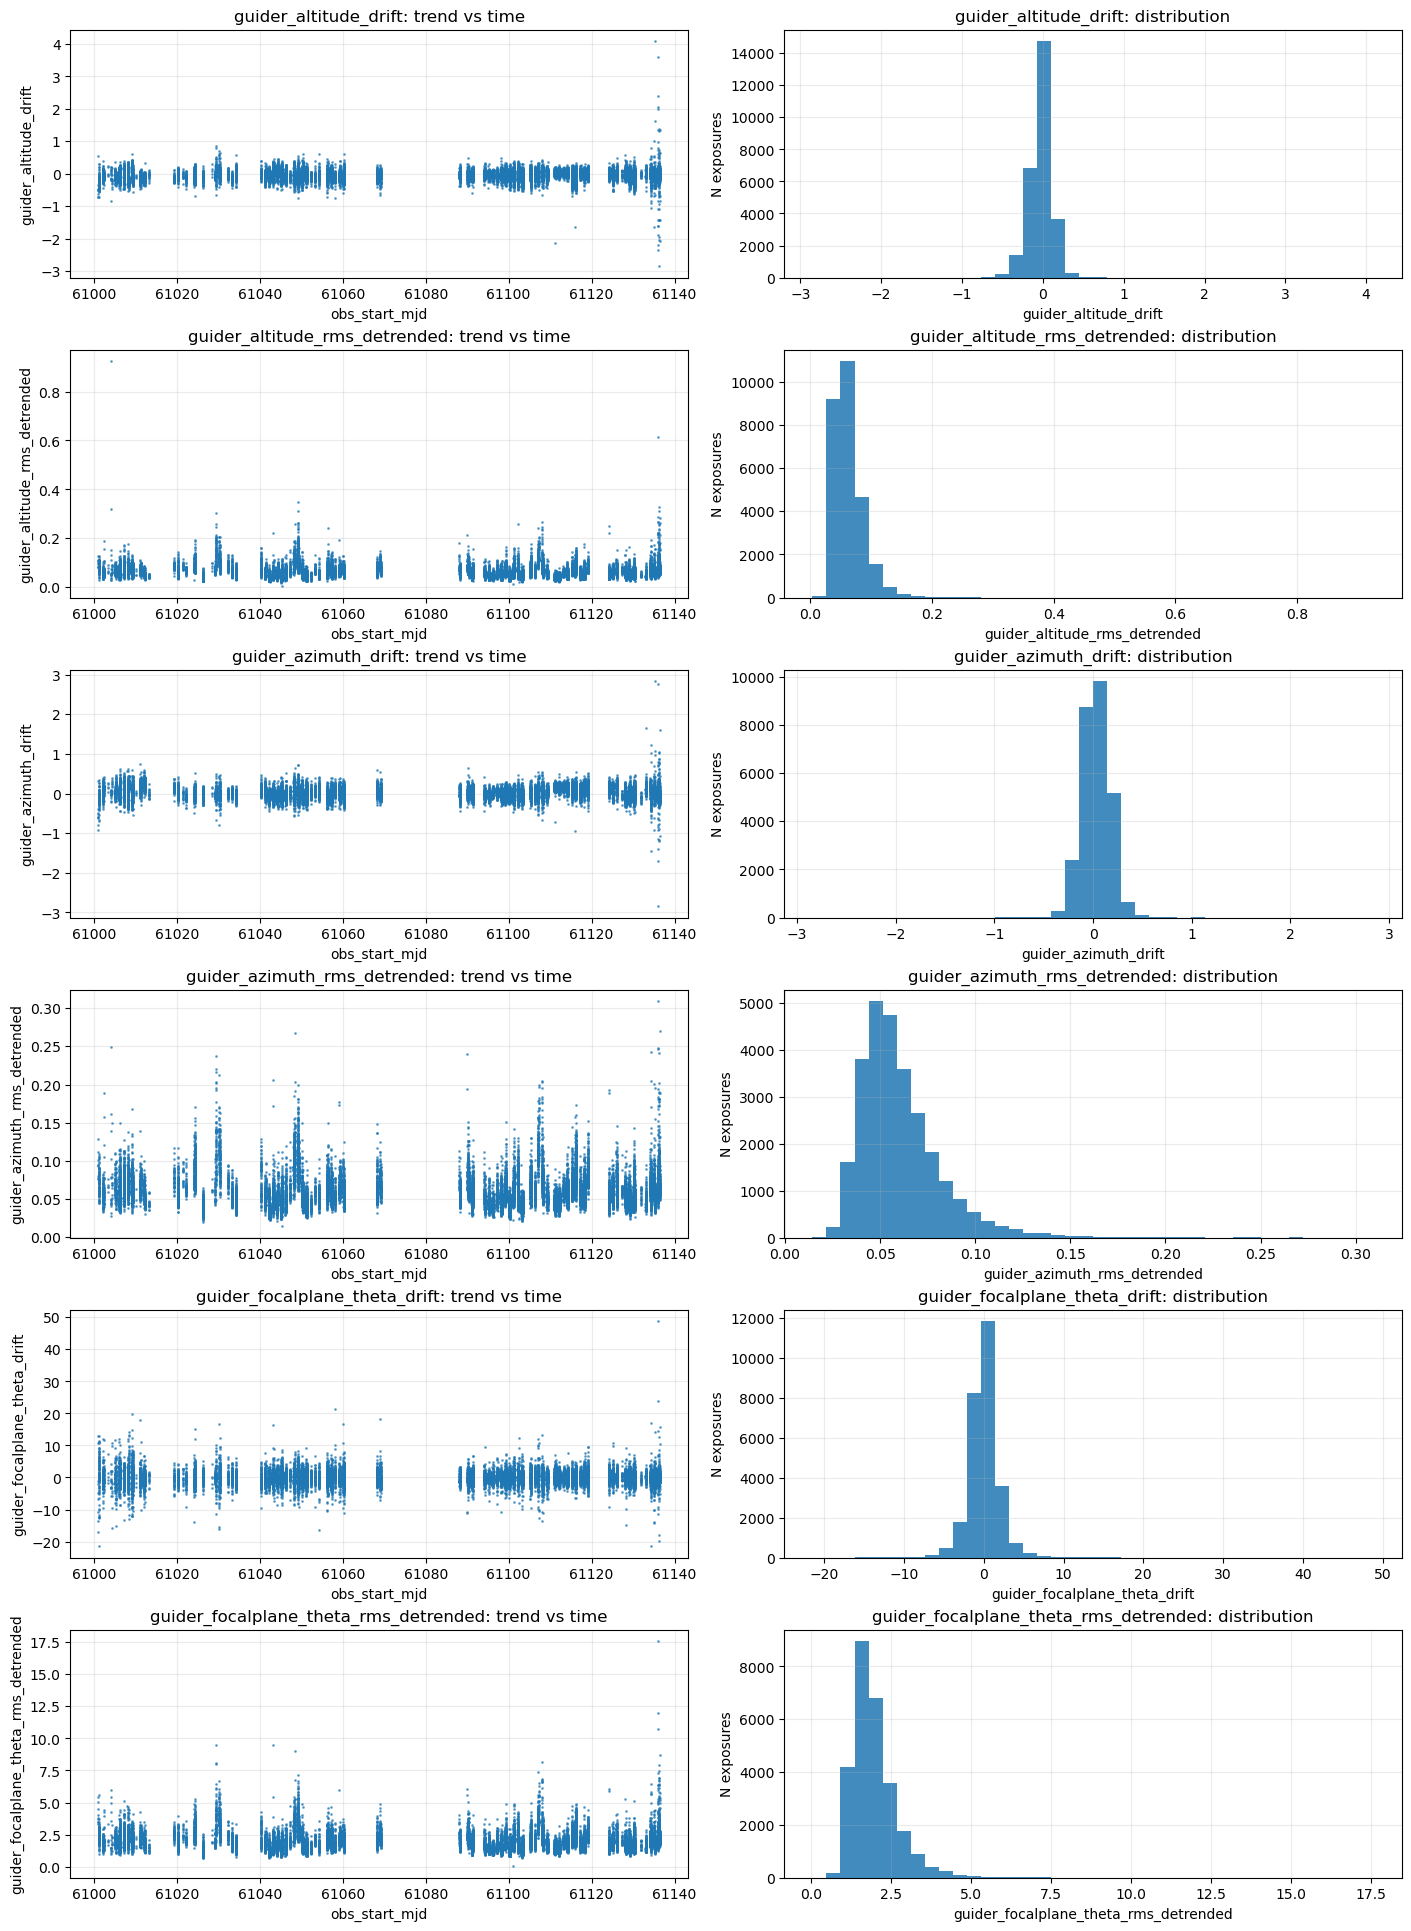

Plotted columns:
guider_altitude_drift
guider_altitude_rms_detrended
guider_azimuth_drift
guider_azimuth_rms_detrended
guider_focalplane_theta_drift
guider_focalplane_theta_rms_detrended
... plus 4 additional columns not shown.


In [5]:
# First-look plots for guider drift/RMS metrics
plot_cols = [c for c in drift_rms_cols if df_guider[c].notna().sum() > 10]

if len(plot_cols) == 0:
    print('No drift/RMS columns have enough non-null samples to plot yet.')
else:
    n_show = min(6, len(plot_cols))
    show_cols = plot_cols[:n_show]

    fig, axes = plt.subplots(n_show, 2, figsize=(14, 3.2 * n_show), constrained_layout=True)
    if n_show == 1:
        axes = np.array([axes])

    for i, c in enumerate(show_cols):
        ax_ts = axes[i, 0]
        ax_hist = axes[i, 1]

        s = df_guider[['obs_start_mjd', c]].dropna().sort_values('obs_start_mjd')
        ax_ts.plot(s['obs_start_mjd'], s[c], '.', ms=2, alpha=0.6)
        ax_ts.set_xlabel('obs_start_mjd')
        ax_ts.set_ylabel(c)
        ax_ts.set_title(f'{c}: trend vs time')
        ax_ts.grid(alpha=0.25)

        ax_hist.hist(df_guider[c].dropna(), bins=40, alpha=0.85)
        ax_hist.set_xlabel(c)
        ax_hist.set_ylabel('N exposures')
        ax_hist.set_title(f'{c}: distribution')
        ax_hist.grid(alpha=0.25)

    plt.show()

    print('Plotted columns:')
    print('\n'.join(show_cols))
    if len(plot_cols) > n_show:
        print(f'... plus {len(plot_cols) - n_show} additional columns not shown.')

## 2.1 Isolate Exposures with Guider Image Motion

Define a robust image-motion score from available guider drift/RMS columns.
Exposures are flagged when any contributing metric is a strong outlier (robust z-score >= 3).

Total science exposures scored: 35720
Flagged high image-motion exposures: 7942 (22.2%)
Motion metrics used: 10
guider_altitude_drift, guider_altitude_rms_detrended, guider_azimuth_drift, guider_azimuth_rms_detrended, guider_focalplane_theta_drift, guider_focalplane_theta_rms_detrended, guider_magnitude_drift, guider_magnitude_rms_detrended, guider_psf_fwhm_drift, guider_psf_fwhm_rms_detrended
Baseline: trailing rolling MAD window=7D, min_periods=100


,exposure_id,day_obs,seq_num,obs_start,image_motion_score,guider_altitude_drift,guider_altitude_rms_detrended,guider_azimuth_drift,guider_azimuth_rms_detrended,guider_focalplane_theta_drift,guider_focalplane_theta_rms_detrended,guider_magnitude_drift,guider_magnitude_rms_detrended,guider_psf_fwhm_drift,guider_psf_fwhm_rms_detrended
15876,2026021900557,20260219,557,2026-02-20 09:14:38.542,2502.902035,0.186544,0.053266,-0.232351,0.075388,-4.452730,2.214193,7410.227212,985.470921,0.093487,0.109594
15880,2026021900561,20260219,561,2026-02-20 09:17:18.578,1646.663430,-0.072103,0.058960,0.006236,0.098597,1.649951,2.504282,-4897.070393,1474.387292,-0.045609,0.105225
15878,2026021900559,20260219,559,2026-02-20 09:16:01.147,1452.355961,0.010004,0.067956,-0.240772,0.077218,6.756876,1.794824,-4304.464203,1000.525057,0.226651,0.064790
15804,2026021900468,20260219,468,2026-02-20 07:44:28.965,1389.192305,0.036013,0.059427,0.026835,0.063333,-0.322604,1.616067,-3716.302460,737.250506,-0.180085,0.153632
22884,2026030700198,20260307,198,2026-03-08 02:36:02.507,1380.697915,-0.071637,0.152974,-0.009894,0.164931,1.709527,5.415602,3452.629520,307.303655,-0.066962,0.115448
15894,2026021900575,20260219,575,2026-02-20 09:26:44.159,1280.910072,-0.062888,0.066126,-0.195337,0.070653,2.479415,2.410918,3863.600446,715.459860,-0.004888,0.064269
15826,2026021900490,20260219,490,2026-02-20 07:58:26.779,1195.512728,0.066382,0.059101,-0.067563,0.065802,-0.161498,1.951263,-3283.321241,1254.137313,-0.123250,0.065264
15789,2026021900453,20260219,453,2026-02-20 07:34:59.576,1149.252493,-0.046139,0.060398,0.080293,0.067992,-2.808292,1.953814,2997.130988,562.501134,0.252555,0.158020
15605,2026021900269,20260219,269,2026-02-20 05:08:59.477,1120.353856,0.138465,0.064383,0.063691,0.062744,-0.793721,2.292799,-2432.073232,565.827409,0.110547,0.073062
27241,2026031600359,20260316,359,2026-03-17 04:51:33.490,1103.067376,-0.043722,0.099813,0.095380,0.095032,1.252585,3.105051,-3012.164275,848.846785,-0.156513,0.110493


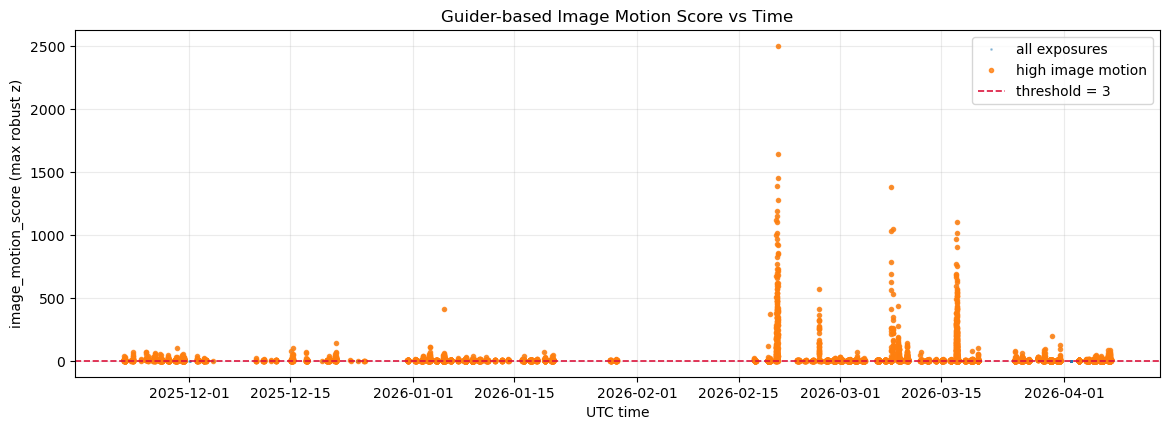

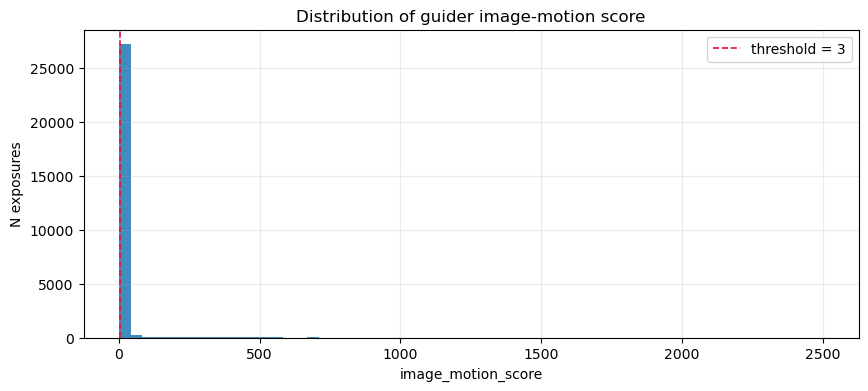

In [16]:
# Build a robust guider image-motion score and isolate high-motion exposures
# Baseline method: trailing 7-day rolling median/MAD (closed='left' to avoid look-ahead).
motion_cols = [c for c in drift_rms_cols if df_guider[c].notna().sum() > 30]
if len(motion_cols) == 0:
    raise ValueError('No guider drift/RMS columns with sufficient samples to score.')

df_motion = df_guider.copy()
df_motion['obs_start_utc'] = pd.to_datetime(df_motion['obs_start'], utc=True, errors='coerce')

rolling_window = '7D'
rolling_min_periods = 100


def trailing_robust_z(df_in, value_col, time_col='obs_start_utc', window='7D', min_periods=100):
    """Return per-row robust z from trailing rolling median/MAD with global fallback."""
    out = pd.Series(np.nan, index=df_in.index, dtype='float64')

    tmp = df_in[[time_col, value_col]].copy()
    tmp['_orig_idx'] = tmp.index
    tmp[value_col] = pd.to_numeric(tmp[value_col], errors='coerce')
    tmp = tmp.dropna(subset=[time_col]).sort_values(time_col)

    if len(tmp) == 0:
        return out

    s = tmp.set_index(time_col)[value_col]
    med = s.rolling(window=window, min_periods=min_periods, closed='left').median()
    abs_dev = (s - med).abs()
    mad = abs_dev.rolling(window=window, min_periods=min_periods, closed='left').median()

    denom = 1.4826 * mad
    z_roll = ((s - med).abs() / denom).replace([np.inf, -np.inf], np.nan)

    # Fallback for early samples or degenerate rolling MAD values.
    g_med = s.median()
    g_mad = (s - g_med).abs().median()
    if pd.notna(g_mad) and g_mad > 0:
        z_fallback = (s - g_med).abs() / (1.4826 * g_mad)
        z = z_roll.where(denom > 0, z_fallback)
    else:
        z = z_roll

    tmp['z'] = z.values
    out.loc[tmp['_orig_idx'].values] = tmp['z'].values
    return out


score_cols = []
for c in motion_cols:
    z_name = f'{c}__robust_z'
    df_motion[z_name] = trailing_robust_z(
        df_motion,
        c,
        time_col='obs_start_utc',
        window=rolling_window,
        min_periods=rolling_min_periods,
    )
    score_cols.append(z_name)

df_motion['image_motion_score'] = df_motion[score_cols].max(axis=1, skipna=True)
df_motion['high_image_motion'] = df_motion['image_motion_score'] >= 3.0

n_total = len(df_motion)
n_flagged = int(df_motion['high_image_motion'].sum())
frac = 100.0 * n_flagged / n_total if n_total else np.nan

print(f'Total science exposures scored: {n_total}')
print(f'Flagged high image-motion exposures: {n_flagged} ({frac:.1f}%)')
print(f'Motion metrics used: {len(motion_cols)}')
print(', '.join(motion_cols))
print(f'Baseline: trailing rolling MAD window={rolling_window}, min_periods={rolling_min_periods}')

# Use whichever band/filter label exists in this dataframe
label_col = 'filter' if 'filter' in df_motion.columns else ('band' if 'band' in df_motion.columns else None)
base_cols = ['exposure_id', 'day_obs', 'seq_num', 'obs_start', 'image_motion_score']
if label_col is not None:
    base_cols.append(label_col)

top_motion = df_motion.loc[df_motion['high_image_motion'], [
    *base_cols, *motion_cols
]].sort_values('image_motion_score', ascending=False)

display(top_motion.head(25))

# Plot 1: motion score over time with high-motion points highlighted
plot_df = df_motion.dropna(subset=['obs_start_utc', 'image_motion_score']).sort_values('obs_start_utc')
plt.figure(figsize=(14, 4.5))
plt.plot(plot_df['obs_start_utc'], plot_df['image_motion_score'], '.', ms=2.0, alpha=0.35, label='all exposures')
flag_df = plot_df[plot_df['high_image_motion']]
if len(flag_df) > 0:
    plt.plot(flag_df['obs_start_utc'], flag_df['image_motion_score'], 'o', ms=3.0, alpha=0.8, label='high image motion')
plt.axhline(3.0, color='crimson', ls='--', lw=1.2, label='threshold = 3')
plt.xlabel('UTC time')
plt.ylabel('image_motion_score (max robust z)')
plt.title('Guider-based Image Motion Score vs Time')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

# Plot 2: score distribution and flagged fraction
plt.figure(figsize=(10, 4))
vals = df_motion['image_motion_score'].dropna()
plt.hist(vals, bins=60, alpha=0.85)
plt.axvline(3.0, color='crimson', ls='--', lw=1.2, label='threshold = 3')
plt.xlabel('image_motion_score')
plt.ylabel('N exposures')
plt.title('Distribution of guider image-motion score')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 2.2 Zoom on April 5 Science Exposures

Fetch `day_obs = 20260405` directly and apply the same guider image-motion scoring used above, then plot the night at higher time resolution.

April 5 science exposures scored: 842
Flagged high image-motion exposures: 327


,exposure_id,seq_num,obs_start,band,physical_filter,image_motion_score,guider_altitude_drift,guider_altitude_rms_detrended,guider_azimuth_drift,guider_azimuth_rms_detrended,guider_focalplane_theta_drift,guider_focalplane_theta_rms_detrended,guider_magnitude_drift,guider_magnitude_rms_detrended,guider_psf_fwhm_drift,guider_psf_fwhm_rms_detrended
58,2026040500073,73,2026-04-06 00:37:25.480,z,z_20,37.709545,3.590101,0.615255,0.804199,0.145423,48.860829,17.579213,11.176840,4.820824,0.038694,0.163235
300,2026040500315,315,2026-04-06 03:39:32.295,i,i_39,23.434431,-2.849575,0.220259,0.800011,0.137702,-19.690080,5.792171,-5.584258,9.061267,-0.077316,0.117013
166,2026040500181,181,2026-04-06 02:04:11.617,z,z_20,22.131213,-1.613523,0.287331,-0.348221,0.093712,-5.426619,12.006988,-1.441970,3.147384,-0.087748,0.200549
108,2026040500123,123,2026-04-06 01:11:39.375,i,i_39,22.024188,0.809380,0.219879,-2.845032,0.309413,14.546233,7.335100,7.308254,8.144005,-0.087073,0.096128
2,2026040500017,17,2026-04-05 23:56:17.039,i,i_39,21.437878,0.167694,0.085908,2.761537,0.246370,-11.337356,4.919215,-17.002101,9.439131,-0.011359,0.078426
33,2026040500048,48,2026-04-06 00:18:12.209,r,r_57,20.729034,2.405873,0.185008,0.492408,0.090191,-1.652160,3.431171,10.608839,8.599629,0.020611,0.100068
20,2026040500035,35,2026-04-06 00:07:42.270,i,i_39,20.210612,0.247849,0.116128,-1.391191,0.247917,0.147549,10.754307,7.952865,11.961416,0.122608,0.098262
163,2026040500178,178,2026-04-06 02:02:14.643,z,z_20,19.265154,-2.359092,0.267814,0.152909,0.055639,23.829705,5.949364,-4.453467,3.970297,-0.026228,0.139345
265,2026040500280,280,2026-04-06 03:16:46.971,i,i_39,17.885956,-2.184204,0.213711,-0.231874,0.086334,0.979142,3.197027,3.204902,11.143119,-0.059581,0.133784
17,2026040500032,32,2026-04-06 00:05:47.032,i,i_39,17.493533,2.000283,0.266317,0.380115,0.183053,-9.262813,6.361240,-6.503326,8.877780,-0.192263,0.103478


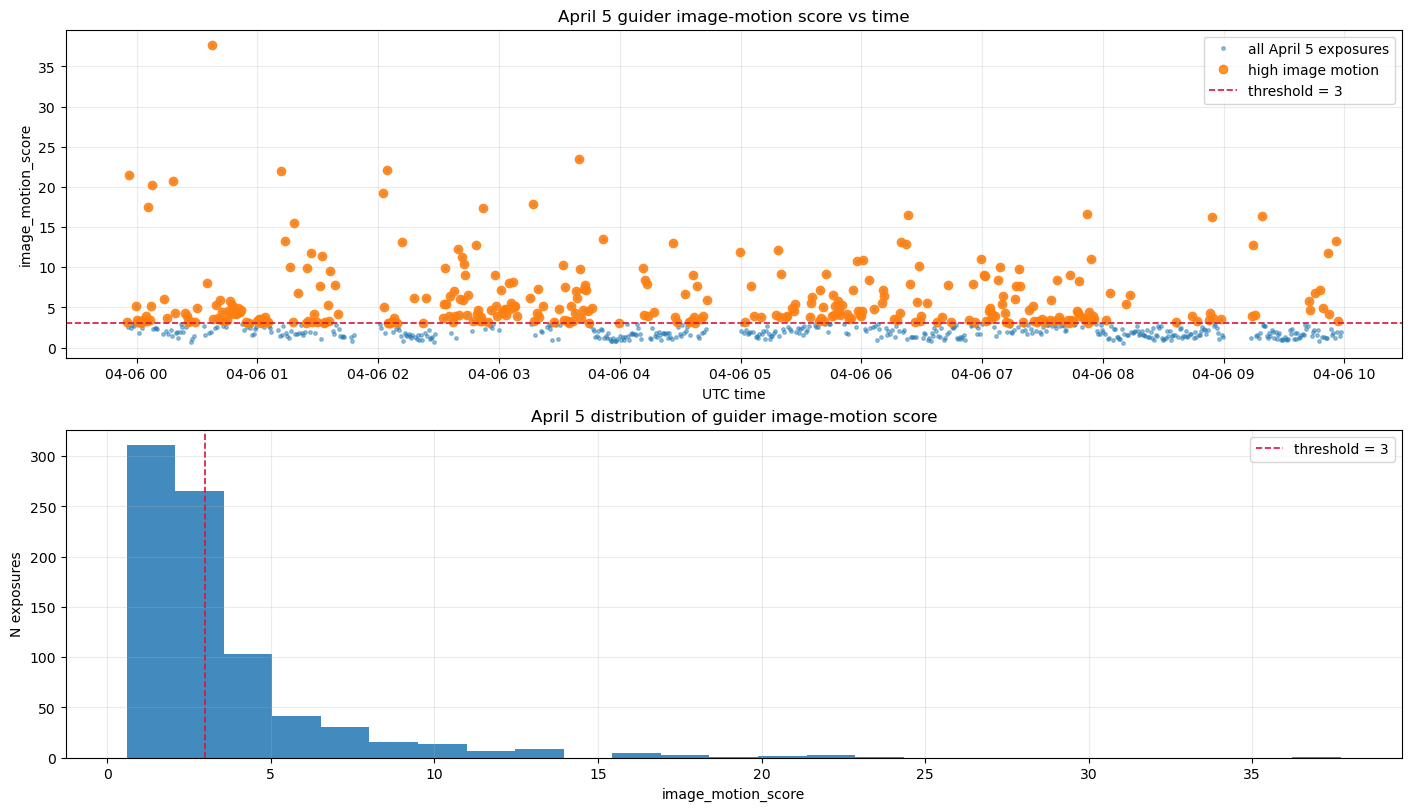

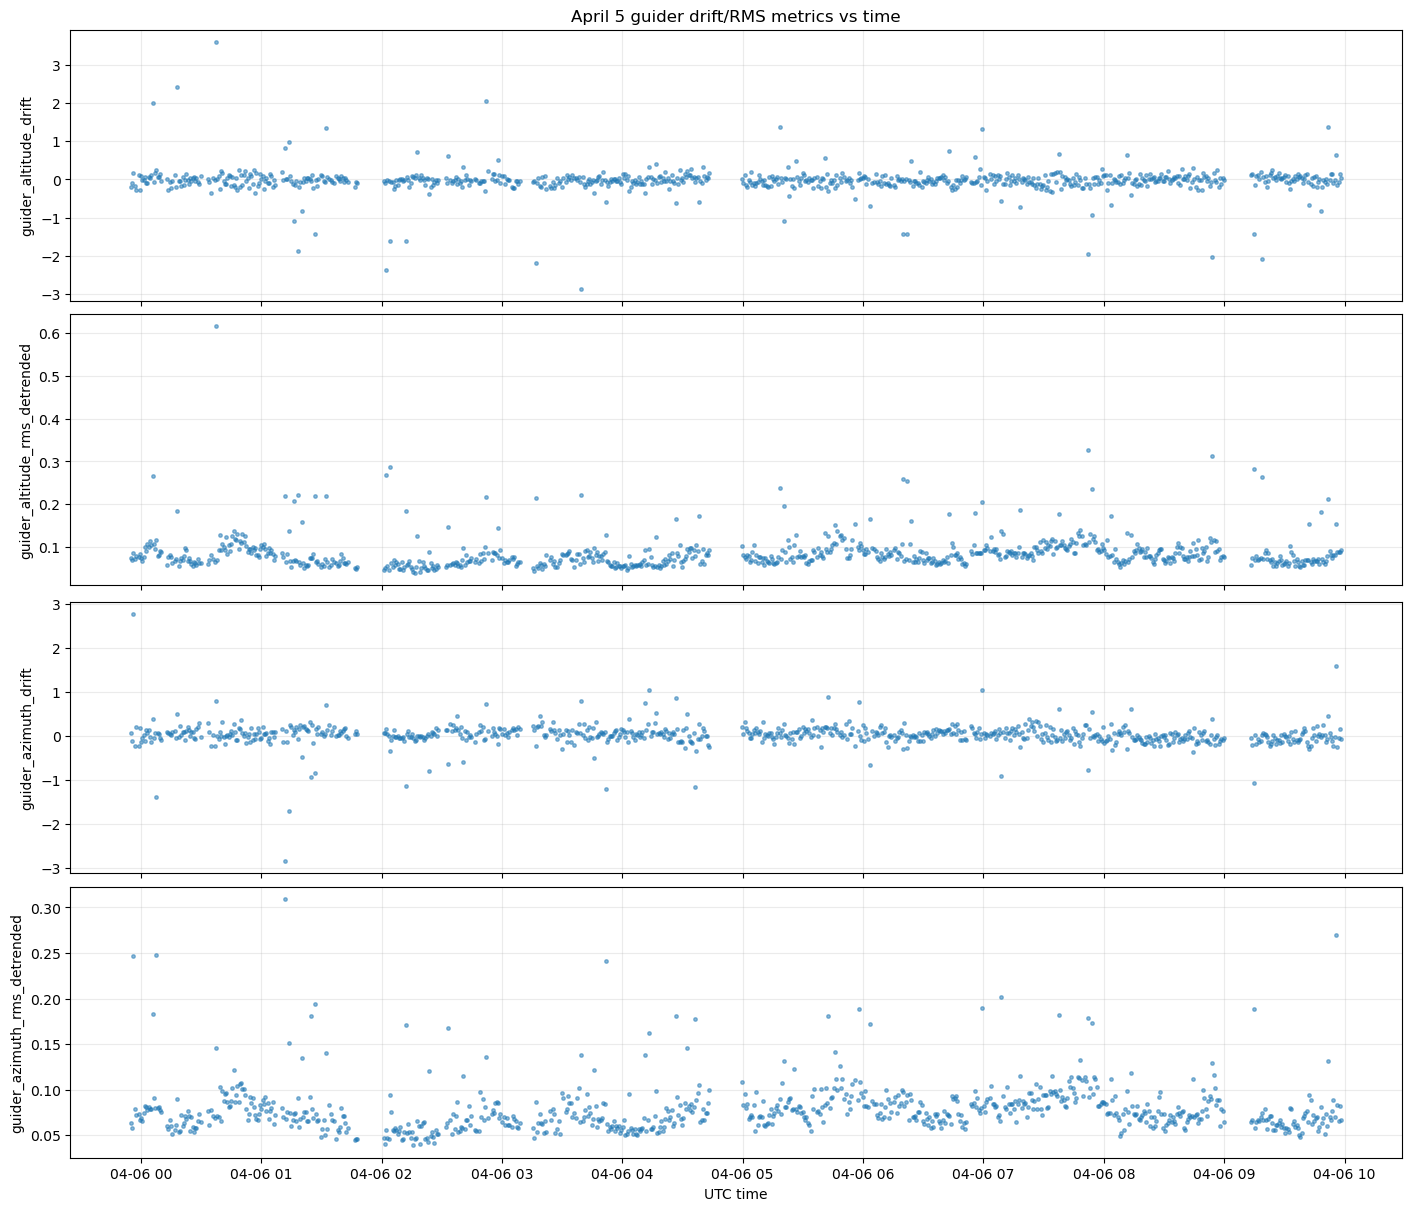

In [55]:
# Zoomed guider image-motion plots for the April 5 night
target_day_obs = 20260405

night_select_metrics = ',\n        '.join([f'q.{c}' for c in motion_cols])
df_motion_night = consdb_query(f"""
    SELECT
        e.exposure_id,
        e.day_obs,
        e.seq_num,
        e.obs_start,
        e.obs_start_mjd,
        e.exp_time,
        e.band,
        e.physical_filter,
        {night_select_metrics}
    FROM {SCHEMA}.exposure e
    JOIN {SCHEMA}.visit1_quicklook q
      ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
    WHERE e.img_type = 'science'
      AND e.day_obs = {target_day_obs}
    ORDER BY e.obs_start_mjd
""")

if len(df_motion_night) == 0:
    print(f'No science exposures with guider quicklook found for day_obs={target_day_obs}.')
else:
    df_motion_night['obs_start_utc'] = pd.to_datetime(df_motion_night['obs_start'], utc=True, errors='coerce')

    # Use the same rolling trailing 7-day robust z-scores already computed in df_motion.
    night_score_cols = [f'{c}__robust_z' for c in motion_cols]
    z_lookup_cols = ['exposure_id', *night_score_cols]
    z_lookup = df_motion[z_lookup_cols].drop_duplicates(subset=['exposure_id'])
    df_motion_night = df_motion_night.merge(z_lookup, on='exposure_id', how='left')

    for c in motion_cols:
        df_motion_night[c] = pd.to_numeric(df_motion_night[c], errors='coerce')

    df_motion_night['image_motion_score'] = df_motion_night[night_score_cols].max(axis=1, skipna=True)
    df_motion_night['high_image_motion'] = df_motion_night['image_motion_score'] >= 3.0

    print(f'April 5 science exposures scored: {len(df_motion_night)}')
    print(f'Flagged high image-motion exposures: {int(df_motion_night['high_image_motion'].sum())}')

    display(
        df_motion_night.loc[df_motion_night['high_image_motion'],
            ['exposure_id', 'seq_num', 'obs_start', 'band', 'physical_filter', 'image_motion_score', *motion_cols]
        ].sort_values('image_motion_score', ascending=False).head(25)
    )

    night_plot = df_motion_night.dropna(subset=['obs_start_utc', 'image_motion_score']).sort_values('obs_start_utc')
    night_flag = night_plot[night_plot['high_image_motion']]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)

    axes[0].plot(night_plot['obs_start_utc'], night_plot['image_motion_score'], '.', ms=5, alpha=0.45, label='all April 5 exposures')
    if len(night_flag) > 0:
        axes[0].plot(night_flag['obs_start_utc'], night_flag['image_motion_score'], 'o', ms=6, alpha=0.85, label='high image motion')
    axes[0].axhline(3.0, color='crimson', ls='--', lw=1.2, label='threshold = 3')
    axes[0].set_xlabel('UTC time')
    axes[0].set_ylabel('image_motion_score')
    axes[0].set_title('April 5 guider image-motion score vs time')
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].hist(night_plot['image_motion_score'].dropna(), bins=25, alpha=0.85)
    axes[1].axvline(3.0, color='crimson', ls='--', lw=1.2, label='threshold = 3')
    axes[1].set_xlabel('image_motion_score')
    axes[1].set_ylabel('N exposures')
    axes[1].set_title('April 5 distribution of guider image-motion score')
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.show()

    top_night_cols = [c for c in motion_cols if df_motion_night[c].notna().sum() > 3][:4]
    if len(top_night_cols) > 0:
        fig, axes = plt.subplots(len(top_night_cols), 1, figsize=(14, 3 * len(top_night_cols)), sharex=True, constrained_layout=True)
        if len(top_night_cols) == 1:
            axes = [axes]

        for ax, c in zip(axes, top_night_cols):
            ax.plot(night_plot['obs_start_utc'], night_plot[c], '.', ms=5, alpha=0.5)
            ax.set_ylabel(c)
            ax.grid(alpha=0.25)

        axes[0].set_title('April 5 guider drift/RMS metrics vs time')
        axes[-1].set_xlabel('UTC time')
        plt.show()

## 2.3 Guider Table for Selected IDs

Look up requested IDs against both `exposure_id` and April 5 `seq_num`, then display the full guider columns for the matching science exposures.

In [8]:
# Full guider table for selected IDs
requested_ids = [32, 35, 48, 315]
requested_ids_sql = ", ".join(str(x) for x in requested_ids)

guider_select = ',\n        '.join([f'q.{c}' for c in guider_cols['column_name']])

df_requested_guider = consdb_query(f"""
    SELECT
        e.exposure_id,
        e.day_obs,
        e.seq_num,
        e.obs_start,
        e.band,
        e.physical_filter,
        CASE WHEN e.exposure_id IN ({requested_ids_sql}) THEN TRUE ELSE FALSE END AS matched_exposure_id,
        CASE WHEN e.seq_num IN ({requested_ids_sql}) THEN TRUE ELSE FALSE END AS matched_seq_num,
        {guider_select}
    FROM {SCHEMA}.exposure e
    JOIN {SCHEMA}.visit1_quicklook q
      ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
    WHERE e.img_type = 'science'
      AND (
            e.exposure_id IN ({requested_ids_sql})
         OR (e.day_obs = {target_day_obs} AND e.seq_num IN ({requested_ids_sql}))
      )
    ORDER BY e.day_obs, e.seq_num
""")

if len(df_requested_guider) == 0:
    print(f'No science exposures matched the requested IDs: {requested_ids}')
else:
    match_kind = np.where(
        df_requested_guider['matched_exposure_id'] & df_requested_guider['matched_seq_num'],
        'matched exposure_id and seq_num',
        np.where(
            df_requested_guider['matched_exposure_id'],
            'matched exposure_id',
            'matched April 5 seq_num',
        ),
    )
    df_requested_guider.insert(0, 'match_kind', match_kind)

    print(f'Matched {len(df_requested_guider)} science exposures for requested IDs: {requested_ids}')
    display(
        df_requested_guider[[
            'match_kind', 'exposure_id', 'day_obs', 'seq_num', 'obs_start',
            'band', 'physical_filter', 'matched_exposure_id', 'matched_seq_num'
        ]]
    )

    print('\nWide guider table:')
    display(df_requested_guider)

    print('\nTransposed guider view (metrics as rows):')
    transposed = df_requested_guider.set_index(['match_kind', 'exposure_id', 'day_obs', 'seq_num']).T
    display(transposed)

Matched 4 science exposures for requested IDs: [32, 35, 48, 315]


,match_kind,exposure_id,day_obs,seq_num,obs_start,band,physical_filter,matched_exposure_id,matched_seq_num
0,matched April 5 seq_num,2026040500032,20260405,32,2026-04-06 00:05:47.032,i,i_39,False,True
1,matched April 5 seq_num,2026040500035,20260405,35,2026-04-06 00:07:42.270,i,i_39,False,True
2,matched April 5 seq_num,2026040500048,20260405,48,2026-04-06 00:18:12.209,r,r_57,False,True
3,matched April 5 seq_num,2026040500315,20260405,315,2026-04-06 03:39:32.295,i,i_39,False,True



Wide guider table:


,match_kind,exposure_id,day_obs,seq_num,obs_start,band,physical_filter,matched_exposure_id,matched_seq_num,guider_exp_time,...,guider_ground_layer_seeing,guider_mid_layer_seeing,guider_free_seeing,guider_total_seeing,guider_stamp_exp_time,guider_n_stamps_expected,guider_n_stamps_delivered,guider_roi_cols,guider_roi_rows,guider_psf_fwhm
0,matched April 5 seq_num,2026040500032,20260405,32,2026-04-06 00:05:47.032,i,i_39,False,True,29.972076,...,4.966009,2.337340,2.457506,6.013629,0.222006,135,135,200.0,200.0,1.421303
1,matched April 5 seq_num,2026040500035,20260405,35,2026-04-06 00:07:42.270,i,i_39,False,True,29.969341,...,2.333545,1.226683,1.668763,3.120088,0.222006,135,135,200.0,200.0,1.228829
2,matched April 5 seq_num,2026040500048,20260405,48,2026-04-06 00:18:12.209,r,r_57,False,True,29.974812,...,5.399807,1.482300,1.030232,5.693549,0.221926,135,135,200.0,200.0,1.213228
3,matched April 5 seq_num,2026040500315,20260405,315,2026-04-06 03:39:32.295,i,i_39,False,True,29.968536,...,6.689743,1.751406,1.379517,7.051464,0.221926,135,135,200.0,200.0,1.078534



Transposed guider view (metrics as rows):


match_kind                                     matched April 5 seq_num  \
exposure_id                                              2026040500032   
day_obs                                                       20260405   
seq_num                                                            32    
obs_start                                   2026-04-06 00:05:47.032000   
band                                                                 i   
physical_filter                                                   i_39   
matched_exposure_id                                              False   
matched_seq_num                                                   True   
guider_exp_time                                              29.972076   
guider_n_tracked_stars                                               8   
guider_n_measurements                                             1056   
guider_altitude_drift                                         2.000283   
guider_altitude_standard_deviation                            0.352073   
guider_altitude_rms_detrended                                 0.266317   
guider_azimuth_drift                                          0.380115   
guider_azimuth_standard_deviation                             0.252654   
guider_azimuth_rms_detrended                                  0.183053   
guider_focalplane_theta_drift                                -9.262813   
guider_focalplane_theta_standard_deviation                    10.28793   
guider_focalplane_theta_rms_detrended                          6.36124   
guider_magnitude_drift                                       -6.503326   
guider_magnitude_standard_deviation                          14.367819   
guider_magnitude_rms_detrended                                 8.87778   
guider_psf_fwhm_start                                         1.517434   
guider_psf_fwhm_drift                                        -0.192263   
guider_psf_fwhm_standard_deviation                            0.144902   
guider_psf_fwhm_rms_detrended                                 0.103478   
guider_e1_mean                                                -0.04494   
guider_e2_mean                                                0.092148   
guider_ground_layer_seeing                                    4.966009   
guider_mid_layer_seeing                                        2.33734   
guider_free_seeing                                            2.457506   
guider_total_seeing                                           6.013629   
guider_stamp_exp_time                                         0.222006   
guider_n_stamps_expected                                           135   
guider_n_stamps_delivered                                          135   
guider_roi_cols                                                  200.0   
guider_roi_rows                                                  200.0   
guider_psf_fwhm                                               1.421303   

match_kind                                                              \
exposure_id                                              2026040500035   
day_obs                                                       20260405   
seq_num                                                            35    
obs_start                                   2026-04-06 00:07:42.270000   
band                                                                 i   
physical_filter                                                   i_39   
matched_exposure_id                                              False   
matched_seq_num                                                   True   
guider_exp_time                                              29.969341   
guider_n_tracked_stars                                               8   
guider_n_measurements                                             1059   
guider_altitude_drift                                         0.247849   
guider_altitude_standard_deviation                            0.163942   
gui

## 2.4 Side-by-Side Drift/RMS Comparison for Selected Exposures

Compare the requested exposures using the main guider drift/RMS columns and a compact heatmap of robust z-scores relative to the full science-exposure sample.

Compact drift/RMS comparison table:


exposure_id,2026040500032,2026040500035,2026040500048,2026040500315
seq_num,32,35,48,315
day_obs,20260405,20260405,20260405,20260405
obs_start,2026-04-06 00:05:47.032000,2026-04-06 00:07:42.270000,2026-04-06 00:18:12.209000,2026-04-06 03:39:32.295000
band,i,i,r,i
physical_filter,i_39,i_39,r_57,i_39
guider_altitude_drift,2.000283,0.247849,2.405873,-2.849575
guider_altitude_rms_detrended,0.266317,0.116128,0.185008,0.220259
guider_azimuth_drift,0.380115,-1.391191,0.492408,0.800011
guider_azimuth_rms_detrended,0.183053,0.247917,0.090191,0.137702
guider_focalplane_theta_drift,-9.262813,0.147549,-1.65216,-19.69008


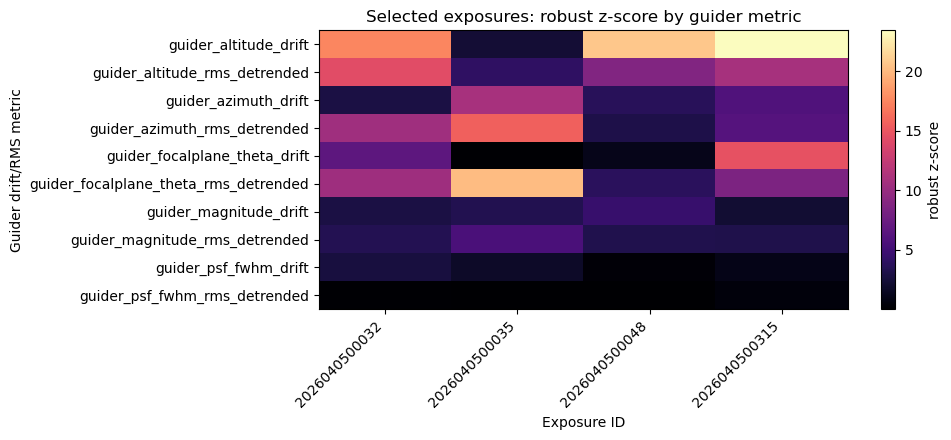

Per-exposure score summary:


,exposure_id,seq_num,band,physical_filter,image_motion_score
3,2026040500315,315,i,i_39,23.434431
2,2026040500048,48,r,r_57,20.729034
1,2026040500035,35,i,i_39,20.210612
0,2026040500032,32,i,i_39,17.493533


In [48]:
# Side-by-side comparison for the requested exposures
main_compare_cols = [c for c in motion_cols if c in df_requested_guider.columns]

if len(df_requested_guider) == 0 or len(main_compare_cols) == 0:
    print('Requested guider table is empty or no drift/RMS columns are available to compare.')
else:
    compare_df = df_requested_guider[[
        'exposure_id', 'day_obs', 'seq_num', 'obs_start', 'band', 'physical_filter', *main_compare_cols
    ]].copy()

    # Use the same trailing 7-day robust z baseline already computed in df_motion.
    robust_z_df = pd.DataFrame(index=compare_df.index)
    for c in main_compare_cols:
        z_col = f'{c}__robust_z'
        z_lookup = df_motion[['exposure_id', z_col]].drop_duplicates(subset=['exposure_id']).set_index('exposure_id')[z_col]
        robust_z_df[c] = compare_df['exposure_id'].map(z_lookup)

    compare_df['image_motion_score'] = robust_z_df.max(axis=1, skipna=True)

    compare_display = compare_df.set_index(['exposure_id', 'seq_num']).T
    print('Compact drift/RMS comparison table:')
    display(compare_display)

    z_display = robust_z_df.copy()
    z_display.index = compare_df['exposure_id'].astype(str)
    z_plot = z_display.T

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(z_plot.index))))
    image = ax.imshow(z_plot.values, aspect='auto', cmap='magma', interpolation='nearest')
    ax.set_xticks(np.arange(len(z_plot.columns)))
    ax.set_xticklabels(z_plot.columns, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(z_plot.index)))
    ax.set_yticklabels(z_plot.index)
    ax.set_xlabel('Exposure ID')
    ax.set_ylabel('Guider drift/RMS metric')
    ax.set_title('Selected exposures: robust z-score by guider metric')
    cbar = plt.colorbar(image, ax=ax)
    cbar.set_label('robust z-score')
    plt.tight_layout()
    plt.show()

    summary_cols = ['exposure_id', 'seq_num', 'band', 'physical_filter', 'image_motion_score']
    print('Per-exposure score summary:')
    display(compare_df[summary_cols].sort_values('image_motion_score', ascending=False))

## 2.5 Dominant Guider Metric for April 5 Outliers

For each flagged April 5 exposure, identify which guider drift/RMS metric contributes the largest robust z-score.

Dominant metric counts among flagged April 5 exposures (altitude/azimuth/theta only):


,n_exposures,median_score,max_score
dominant_metric,,,
guider_azimuth_rms_detrended,103,2.736899,13.546303
guider_altitude_rms_detrended,91,3.283204,37.709545
guider_focalplane_theta_rms_detrended,47,3.539717,22.131213
guider_azimuth_drift,33,1.651625,22.024188
guider_altitude_drift,30,4.162081,23.434431
guider_focalplane_theta_drift,23,1.616451,11.768354



Flagged exposures with dominant metric:


,exposure_id,seq_num,obs_start,band,physical_filter,image_motion_score,dominant_metric,dominant_metric_score
300,2026040500315,315,2026-04-06 03:39:32.295,i,i_39,23.434431,guider_altitude_drift,23.434431
33,2026040500048,48,2026-04-06 00:18:12.209,r,r_57,20.729034,guider_altitude_drift,20.729034
163,2026040500178,178,2026-04-06 02:02:14.643,z,z_20,19.265154,guider_altitude_drift,19.265154
265,2026040500280,280,2026-04-06 03:16:46.971,i,i_39,17.885956,guider_altitude_drift,17.885956
17,2026040500032,32,2026-04-06 00:05:47.032,i,i_39,17.493533,guider_altitude_drift,17.493533
...,...,...,...,...,...,...,...,...
257,2026040500272,272,2026-04-06 03:05:34.715,i,i_39,4.755660,guider_focalplane_theta_rms_detrended,1.605873
543,2026040500558,558,2026-04-06 06:32:25.149,z,z_20,5.572249,guider_focalplane_theta_rms_detrended,1.506339
145,2026040500160,160,2026-04-06 01:35:29.076,i,i_39,3.334365,guider_focalplane_theta_rms_detrended,1.331533
246,2026040500261,261,2026-04-06 02:58:30.667,i,i_39,5.140805,guider_focalplane_theta_rms_detrended,1.302422


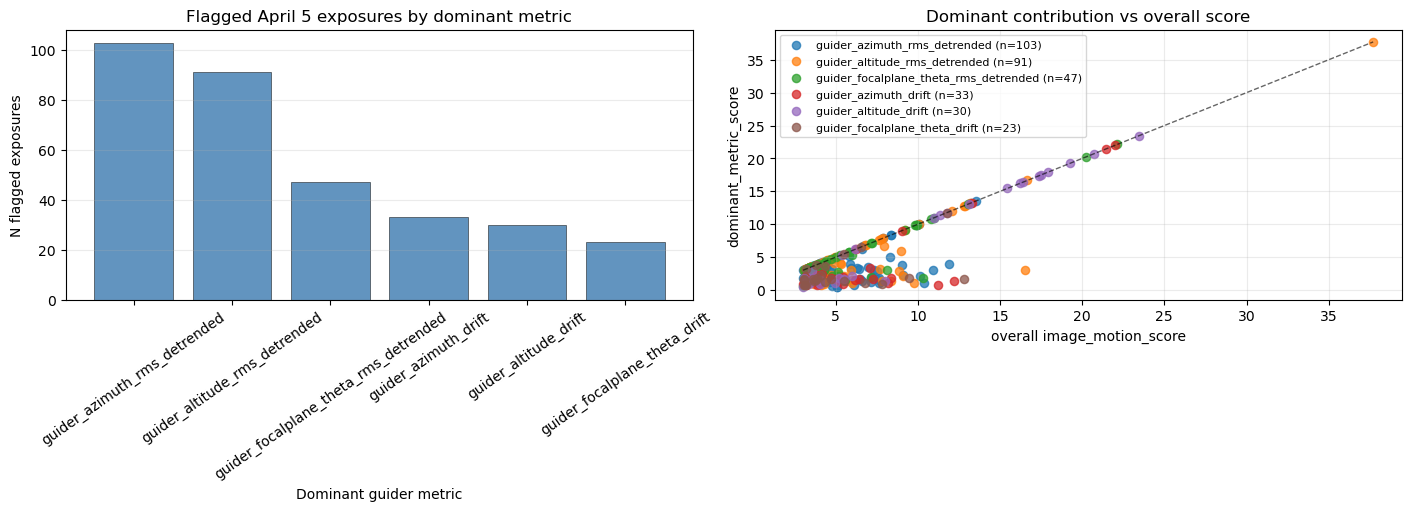

In [64]:
# Label the dominant guider metric for each flagged April 5 exposure
# Restrict dominant-metric attribution to altitude, azimuth, and focalplane-theta metrics.
night_robust_cols = [f'{c}__robust_z' for c in motion_cols if f'{c}__robust_z' in df_motion_night.columns]

allowed_prefixes = (
    'guider_altitude_',
    'guider_azimuth_',
    'guider_focalplane_theta_',
)
dominant_candidate_cols = [
    c for c in night_robust_cols
    if c.replace('__robust_z', '').startswith(allowed_prefixes)
]

if len(df_motion_night) == 0 or len(dominant_candidate_cols) == 0:
    print('April 5 motion table is not available, or no allowed dominant metrics were found.')
    print('Allowed dominant metrics are altitude/azimuth/theta only.')
else:
    flagged_night = df_motion_night[df_motion_night['high_image_motion']].copy()

    if len(flagged_night) == 0:
        print('No flagged April 5 exposures to label.')
    else:
        dominant_robust_col = flagged_night[dominant_candidate_cols].idxmax(axis=1)
        flagged_night['dominant_metric'] = dominant_robust_col.str.replace('__robust_z', '', regex=False)
        flagged_night['dominant_metric_score'] = flagged_night[dominant_candidate_cols].max(axis=1)

        dominant_summary = (
            flagged_night.groupby('dominant_metric')
            .agg(
                n_exposures=('exposure_id', 'size'),
                median_score=('dominant_metric_score', 'median'),
                max_score=('dominant_metric_score', 'max'),
            )
            .sort_values(['n_exposures', 'max_score'], ascending=[False, False])
        )

        print('Dominant metric counts among flagged April 5 exposures (altitude/azimuth/theta only):')
        display(dominant_summary)

        detail_cols = [
            'exposure_id', 'seq_num', 'obs_start', 'band', 'physical_filter',
            'image_motion_score', 'dominant_metric', 'dominant_metric_score'
        ]
        print('\nFlagged exposures with dominant metric:')
        display(
            flagged_night[detail_cols].sort_values(
                ['dominant_metric', 'dominant_metric_score'],
                ascending=[True, False],
            )
        )

        top_metrics = dominant_summary.head(6).index.tolist()
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

        axes[0].bar(
            dominant_summary.index,
            dominant_summary['n_exposures'],
            color='steelblue',
            alpha=0.85,
            edgecolor='black',
            linewidth=0.4,
        )
        axes[0].set_xlabel('Dominant guider metric')
        axes[0].set_ylabel('N flagged exposures')
        axes[0].set_title('Flagged April 5 exposures by dominant metric')
        axes[0].tick_params(axis='x', rotation=35)
        axes[0].grid(axis='y', alpha=0.25)

        for metric in top_metrics:
            sub = flagged_night[flagged_night['dominant_metric'] == metric]
            axes[1].scatter(
                sub['image_motion_score'],
                sub['dominant_metric_score'],
                s=35,
                alpha=0.75,
                label=f"{metric} (n={len(sub)})",
            )

        min_score = flagged_night['image_motion_score'].min()
        max_score = flagged_night['image_motion_score'].max()
        axes[1].plot([min_score, max_score], [min_score, max_score], 'k--', lw=1.0, alpha=0.6)
        axes[1].set_xlabel('overall image_motion_score')
        axes[1].set_ylabel('dominant_metric_score')
        axes[1].set_title('Dominant contribution vs overall score')
        axes[1].grid(alpha=0.25)
        axes[1].legend(fontsize=8)

        plt.show()

## 2.6 Colored Timeline: April 5 Flagged Exposures by Dominant Metric

Visual timeline of all April 5 high-motion exposures, colored by their dominant guider metric to see which metrics cluster in time.

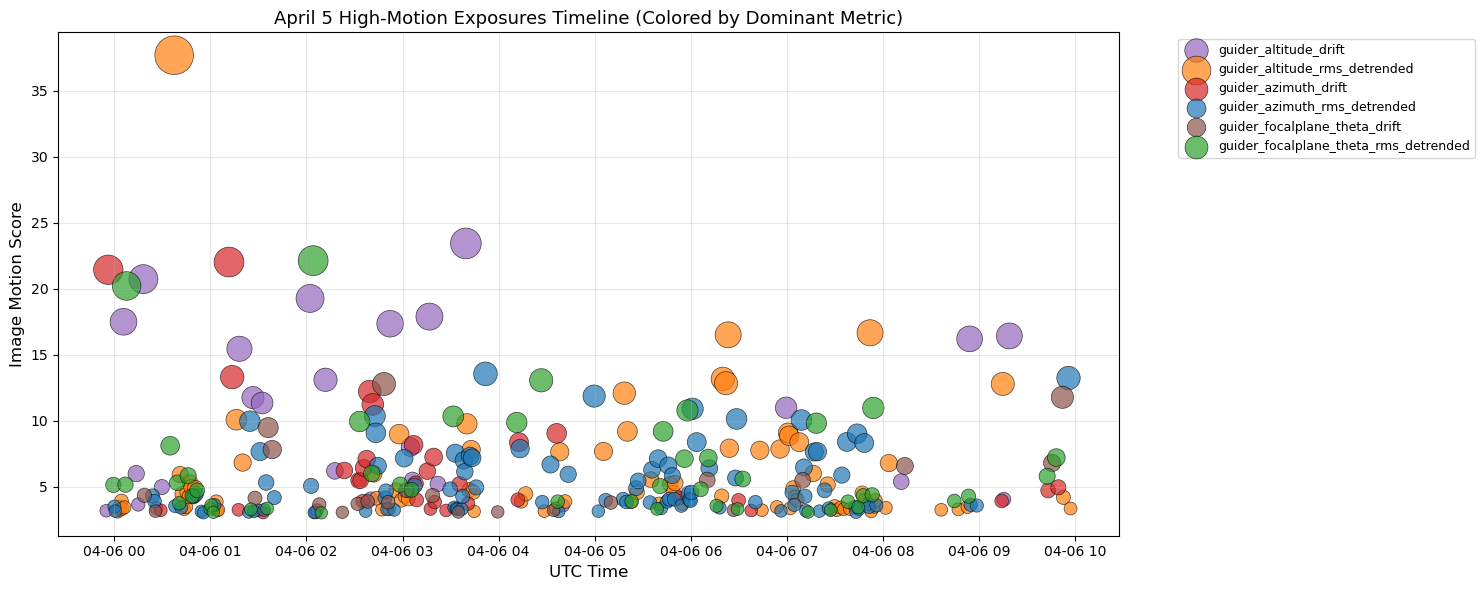


Timeline shows 327 flagged exposures across April 5.
Bubble size scales with image motion score for emphasis on high-motion events.


In [65]:
# Create a colored timeline of April 5 flagged exposures
if 'flagged_night' in locals() and len(flagged_night) > 0:
    # Create color mapping for top metrics
    if 'dominant_summary' in locals():
        color_map = {
            metric: plt.cm.tab10(i % 10)
            for i, metric in enumerate(dominant_summary.index)
        }
    else:
        # Fallback if dominant_summary not available
        unique_metrics = flagged_night['dominant_metric'].unique()
        color_map = {
            metric: plt.cm.tab10(i % 10)
            for i, metric in enumerate(unique_metrics)
        }
    
    # Create figure with timeline
    fig, ax = plt.subplots(figsize=(15, 6))
    
    # Plot all flagged exposures, colored by dominant metric
    for metric in sorted(color_map.keys()):
        subset = flagged_night[flagged_night['dominant_metric'] == metric]
        if len(subset) > 0:
            ax.scatter(
                subset['obs_start_utc'],
                subset['image_motion_score'],
                s=subset['image_motion_score'] * 20 + 20,  # Scale size by score
                alpha=0.7,
                label=metric,
                color=color_map[metric],
                edgecolors='black',
                linewidth=0.5,
            )
    
    ax.set_xlabel('UTC Time', fontsize=12)
    ax.set_ylabel('Image Motion Score', fontsize=12)
    ax.set_title('April 5 High-Motion Exposures Timeline (Colored by Dominant Metric)', fontsize=13)
    ax.grid(alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)
    fig.tight_layout()
    plt.show()
    
    print(f"\nTimeline shows {len(flagged_night)} flagged exposures across April 5.")
    print("Bubble size scales with image motion score for emphasis on high-motion events.")

## 2.7 Mount Motion Cross-Check: Guider Metrics vs PSF Degradation

Correlate dominant guider drift/RMS metrics with optical quality metrics (PSF sigma scales, aperture flux deltas) to quantify the impact of each metric on final image quality.

Merged 327 flagged exposures with PSF/AOS data

PSF/AOS Metrics by Dominant Guider Metric (April 5 Flagged Exposures):


,aos_fwhm_mean,aos_fwhm_std,aos_fwhm_min,aos_fwhm_max,donut_blur_fwhm_mean,donut_blur_fwhm_std,donut_blur_fwhm_min,donut_blur_fwhm_max,eff_time_psf_sigma_scale_median_mean,eff_time_psf_sigma_scale_median_std,eff_time_psf_sigma_scale_median_min,eff_time_psf_sigma_scale_median_max,image_motion_score_mean,image_motion_score_median,image_motion_score_max,n_exposures
dominant_metric,,,,,,,,,,,,,,,,
guider_altitude_drift,0.5167,0.0427,0.4336,0.6249,1.1256,0.2632,0.8193,1.7148,0.3630,0.0900,0.1627,0.4661,9.5618,6.0827,23.4344,30
guider_altitude_rms_detrended,0.4751,0.0583,0.3720,0.6164,1.0939,0.1575,0.7916,1.9206,0.3226,0.0805,0.1483,0.5052,5.7198,4.1795,37.7095,91
guider_azimuth_drift,0.5100,0.0633,0.3966,0.6587,0.9485,0.2362,0.7658,1.8853,0.4075,0.1031,0.1599,0.6255,6.6763,5.1760,22.0242,33
guider_azimuth_rms_detrended,0.4682,0.0590,0.3702,0.6452,1.0598,0.1281,0.8074,1.4355,0.3391,0.0779,0.1630,0.5640,5.2325,4.2475,13.5463,103
guider_focalplane_theta_drift,0.4877,0.0450,0.3878,0.5835,0.9173,0.1112,0.7402,1.2221,0.4041,0.0926,0.2583,0.5945,5.2667,4.1173,12.7760,23
guider_focalplane_theta_rms_detrended,0.4764,0.0587,0.3769,0.6167,1.0731,0.1399,0.8211,1.4790,0.3227,0.0881,0.1445,0.5883,6.2711,4.7934,22.1312,47


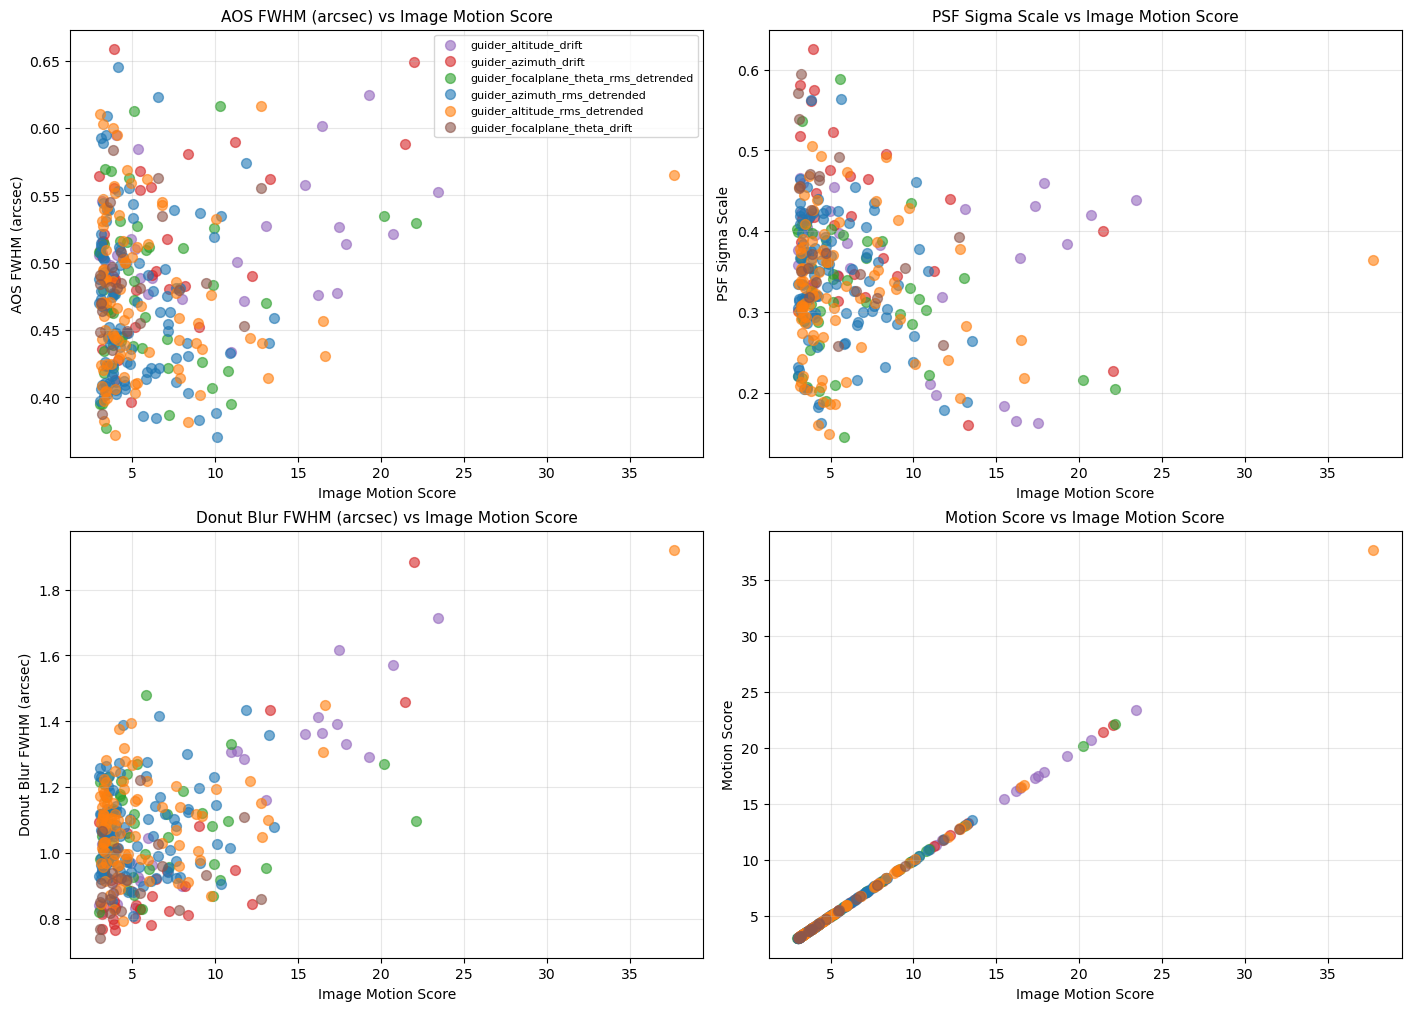


Spearman Correlation: Motion Score vs PSF/AOS Metrics


,image_motion_score
aos_fwhm,0.035254
eff_time_psf_sigma_scale_median,-0.113729
donut_blur_fwhm,0.182641


In [68]:
# Fetch PSF/optical quality metrics for April 5 flagged exposures and correlate with dominant metrics
if 'flagged_night' in locals() and len(flagged_night) > 0:
    # Query for PSF/AOS-related columns from visit1_quicklook
    psf_cols_query = f"""
    SELECT
        e.exposure_id,
        e.seq_num,
        q.aos_fwhm,
        q.donut_blur_fwhm,
        q.eff_time_psf_sigma_scale_median
    FROM {SCHEMA}.exposure e
    JOIN {SCHEMA}.visit1_quicklook q
      ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
    WHERE e.img_type = 'science' AND e.day_obs = {target_day_obs}
    ORDER BY e.seq_num
    """

    try:
        df_psf_night = consdb_query(psf_cols_query)

        # Merge PSF data with flagged exposure data
        flagged_with_psf = flagged_night.merge(
            df_psf_night[['exposure_id', 'aos_fwhm', 'donut_blur_fwhm', 'eff_time_psf_sigma_scale_median']],
            on='exposure_id',
            how='left'
        )

        print(f"Merged {len(flagged_with_psf)} flagged exposures with PSF/AOS data")

        # Create summary statistics by dominant metric
        psf_metric_stats = (
            flagged_with_psf.groupby('dominant_metric')
            .agg({
                'aos_fwhm': ['mean', 'std', 'min', 'max'],
                'donut_blur_fwhm': ['mean', 'std', 'min', 'max'],
                'eff_time_psf_sigma_scale_median': ['mean', 'std', 'min', 'max'],
                'image_motion_score': ['mean', 'median', 'max'],
                'exposure_id': 'count'
            })
            .round(4)
        )
        psf_metric_stats.columns = ['_'.join(col).strip() for col in psf_metric_stats.columns.values]
        psf_metric_stats.rename(columns={'exposure_id_count': 'n_exposures'}, inplace=True)

        print("\nPSF/AOS Metrics by Dominant Guider Metric (April 5 Flagged Exposures):")
        display(psf_metric_stats)

        # Create scatter plots: dominant metric vs PSF degradation
        fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

        # Define metrics and columns to plot
        plot_config = [
            ('AOS FWHM (arcsec)', 'aos_fwhm', 0),
            ('PSF Sigma Scale', 'eff_time_psf_sigma_scale_median', 1),
            ('Donut Blur FWHM (arcsec)', 'donut_blur_fwhm', 2),
            ('Motion Score', 'image_motion_score', 3),
        ]

        for title, col, idx in plot_config:
            ax = axes.flat[idx]

            # Plot each dominant metric separately
            for metric in flagged_with_psf['dominant_metric'].unique():
                subset = flagged_with_psf[flagged_with_psf['dominant_metric'] == metric]
                valid_data = subset.dropna(subset=[col])
                if len(valid_data) > 0:
                    ax.scatter(
                        valid_data['image_motion_score'],
                        valid_data[col],
                        s=50,
                        alpha=0.6,
                        label=metric if metric in color_map else 'other',
                        color=color_map.get(metric, 'gray'),
                    )

            ax.set_xlabel('Image Motion Score', fontsize=10)
            ax.set_ylabel(title, fontsize=10)
            ax.set_title(f'{title} vs Image Motion Score', fontsize=11)
            ax.grid(alpha=0.3)

            if idx == 0:
                ax.legend(fontsize=8, loc='best')

        plt.show()

        # Compute Spearman correlation between motion metrics and PSF degradation
        print("\nSpearman Correlation: Motion Score vs PSF/AOS Metrics")
        corr_data = flagged_with_psf[[
            'image_motion_score',
            'aos_fwhm',
            'eff_time_psf_sigma_scale_median',
            'donut_blur_fwhm',
        ]].corr(method='spearman')
        display(corr_data[['image_motion_score']].drop('image_motion_score'))

    except Exception as e:
        print(f"PSF/AOS cross-check query failed: {e}")
        print("Fallback: Summary of dominant metrics without PSF correlation")
        print(f"\nDominant metrics distribution among {len(flagged_night)} April 5 flagged exposures:")
        display(dominant_summary)

## 3. Fetch Science Exposures + Quicklook from ConsDB

### Column name changes vs LATISS / REST API docs

| `cdb_lsstcam` column | LATISS / old name | Notes |
|---|---|---|
| `img_type = 'science'` | `imgtype = 'OBJECT'` | lowercase in lsstcam |
| `obs_start` / `obs_start_mjd` | `obsstart` / `obsstartmjd` | now matches REST API |
| `exp_time` | `exptime` | |
| `s_ra` / `s_dec` | `ra` / `decl` | now matches REST API |
| `sky_rotation` | `skyrotation` | |
| `air_temp` | `airtemp` | |
| `exp_midpt` | `expmidpt` | |
| *(no dome_azimuth)* | `dome_azimuth` | fetch from EFD MTDome.azimuth |

`visit1_quicklook` adds PSF sigma, effective time, seeing, Zernikes z4-z28, guider metrics.  
`exposure_quicklook` adds mount jitter and image degradation.

In [11]:
df_exp = consdb_query(f"""
    SELECT
        e.exposure_id,
        e.day_obs,
        e.seq_num,
        e.obs_start,
        e.obs_start_mjd,
        e.exp_time,
        e.airmass,
        e.s_ra,
        e.s_dec,
        e.azimuth,
        e.altitude,
        e.sky_rotation,
        e.wind_speed,
        e.wind_dir,
        e.dimm_seeing,
        e.air_temp,
        e.humidity,
        e.band,
        e.physical_filter,
        e.target_name,
        e.img_type,
        e.vignette,
        e.can_see_sky,
        e.scheduler_note,
        -- visit1_quicklook
        q.psf_sigma_median,
        q.seeing_zenith_500nm_median,
        q.eff_time_median,
        q.eff_time_zero_point_scale_median,
        q.sky_bg_median,
        q.zero_point_median,
        q.donut_blur_fwhm,
        q.aos_fwhm,
        q.z4, q.z5, q.z6, q.z7, q.z8, q.z9, q.z10, q.z11,
        -- mount (from exposure_quicklook)
        m.mount_motion_image_degradation,
        m.mount_motion_image_degradation_az,
        m.mount_motion_image_degradation_el,
        m.mount_motion_image_degradation_rot,
        m.mount_jitter_rms,
        m.mount_jitter_rms_az,
        m.mount_jitter_rms_el,
        m.mount_jitter_rms_rot
    FROM {SCHEMA}.exposure e
    LEFT JOIN {SCHEMA}.visit1_quicklook  q ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
    LEFT JOIN {SCHEMA}.exposure_quicklook m ON m.day_obs = e.day_obs AND m.seq_num = e.seq_num
    WHERE e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
      AND e.img_type = 'science'
    ORDER BY e.obs_start_mjd
""")

df_exp["obs_start_utc"] = pd.to_datetime(df_exp["obs_start"], utc=True)
df_exp = df_exp.sort_values("obs_start_utc").set_index("obs_start_utc")

print(f"Science exposures  : {len(df_exp)}")
print(f"Date range         : {df_exp.index.min()} → {df_exp.index.max()}")
print(f"With PSF sigma     : {df_exp['psf_sigma_median'].notna().sum()}")
print(f"With donut blur    : {df_exp['donut_blur_fwhm'].notna().sum()}")
print(f"With AOS FWHM      : {df_exp['aos_fwhm'].notna().sum()}")
print(f"With ZP scale      : {df_exp['eff_time_zero_point_scale_median'].notna().sum()}")
print(f"With mount jitter  : {df_exp['mount_jitter_rms'].notna().sum()}")
print(f"With mount motion  : {df_exp['mount_motion_image_degradation'].notna().sum()}")
df_exp.head()

Science exposures  : 34281
Date range         : 2025-10-25 01:29:23.620000+00:00 → 2026-04-05 10:01:54.645000+00:00
With PSF sigma     : 33882
With donut blur    : 33908
With AOS FWHM      : 33908
With ZP scale      : 33825
With mount jitter  : 14302
With mount motion  : 14302


,exposure_id,day_obs,seq_num,obs_start,obs_start_mjd,exp_time,airmass,s_ra,s_dec,azimuth,...,z10,z11,mount_motion_image_degradation,mount_motion_image_degradation_az,mount_motion_image_degradation_el,mount_motion_image_degradation_rot,mount_jitter_rms,mount_jitter_rms_az,mount_jitter_rms_el,mount_jitter_rms_rot
obs_start_utc,,,,,,,,,,,,,,,,,,,,,
2025-10-25 01:29:23.620000+00:00,2025102400105,20251024,105,2025-10-25 01:29:23.620,60973.062079,30.0,1.048508,331.902574,-17.358498,314.811336,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-25 01:30:06.907000+00:00,2025102400106,20251024,106,2025-10-25 01:30:06.907,60973.062580,30.0,1.061767,328.799598,-17.329091,307.671873,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-25 01:30:46.123000+00:00,2025102400107,20251024,107,2025-10-25 01:30:46.123,60973.063034,30.0,1.046469,329.972344,-19.996186,303.465543,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-25 01:31:34.642000+00:00,2025102400108,20251024,108,2025-10-25 01:31:34.642,60973.063595,30.0,1.046454,328.126653,-22.706518,292.260500,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-25 01:32:14.839000+00:00,2025102400109,20251024,109,2025-10-25 01:32:14.839,60973.064061,30.0,1.062649,325.056555,-22.668908,287.864861,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Quick statistics
print("Band distribution:")
display(df_exp["band"].value_counts())

print("\nPSF sigma median (pixels):")
display(df_exp["psf_sigma_median"].describe())

print("\nWind speed (m/s):")
display(df_exp["wind_speed"].describe())

print("\nMount jitter RMS (arcsec):")
display(df_exp["mount_jitter_rms"].describe())

Band distribution:


band
i    14131
z     7238
y     6287
r     3417
g     2637
u      571
Name: count, dtype: int64


PSF sigma median (pixels):


count    33882.000000
mean         2.204263
std          0.507673
min          1.205976
25%          1.875438
50%          2.092079
75%          2.387567
max          7.701598
Name: psf_sigma_median, dtype: float64


Wind speed (m/s):


count    34281.000000
mean         4.113879
std          3.184556
min          0.000000
25%          1.751400
50%          3.252600
75%          5.671200
max         17.097000
Name: wind_speed, dtype: float64


Mount jitter RMS (arcsec):


count    14302.000000
mean         0.264124
std         18.468971
min          0.002807
25%          0.004874
50%          0.005651
75%          0.006911
max       2162.096975
Name: mount_jitter_rms, dtype: float64

## 3. Fetch EFD Telemetry

Same topics as `ESS_Wind_vs_DomePointing.ipynb`:

| Topic | Index | Fields | Purpose |
|---|---|---|---|
| `lsst.sal.ESS.airFlow` | 301 | `speed`, `direction` | Outside wind |
| `lsst.sal.MTDome.azimuth` | — | `positionActual` | Dome azimuth (not in ConsDB) |
| `lsst.sal.MTDome.apertureShutter` | — | `positionActual0/1` | Shutter state |
| `lsst.sal.ESS.airTurbulence` | 110, 123–126 | `speedMagnitude`, `sonicTemperatureStdDev` | Inside turbulence |

In [ ]:
EFD_ALIAS = "usdf_efd"
efd_client = EfdClient(EFD_ALIAS)
print(f"Connected to {EFD_ALIAS}")


NameError: name 'EFD_ALIAS' is not defined

In [14]:
# Outside wind (ESS:301)
df_wind_raw = await efd_client.select_time_series(
    flow_topic,
    fields=["direction", "speed"],
    start=t_start,
    end=t_end,
    index=weather_index,
)
print(f"ESS:{weather_index} airFlow rows: {len(df_wind_raw)}")
df_wind_raw.head()

ESS:301 airFlow rows: 11734060


,direction,speed
2025-10-11 05:00:00.155724+00:00,11.870013,5.4210
2025-10-11 05:00:01.436087+00:00,11.604870,5.2542
2025-10-11 05:00:02.715952+00:00,14.015000,5.2542
2025-10-11 05:00:03.996410+00:00,11.659986,5.2542
2025-10-11 05:00:05.275245+00:00,11.624985,5.2542


In [47]:
# Dome azimuth — needed for relative wind pointing (not stored in cdb_lsstcam.exposure)
df_dome = await efd_client.select_time_series(
    dome_topic,
    fields="positionActual",
    start=t_start,
    end=t_end,
)
print(f"Dome azimuth rows: {len(df_dome)}")
df_dome.head()

Dome azimuth rows: 25331811


,positionActual
2025-10-13 19:18:07.314967+00:00,147.648163
2025-10-13 19:18:07.527566+00:00,147.648163
2025-10-13 19:18:08.542858+00:00,147.648163
2025-10-13 19:18:08.895768+00:00,147.648163
2025-10-13 19:18:09.252082+00:00,147.648163


In [48]:
# Aperture shutter (to flag shutter-open science exposures)
df_shutter = await efd_client.select_time_series(
    shutter_topic,
    fields=["positionActual0", "positionActual1"],
    start=t_start,
    end=t_end,
)
print(f"Shutter rows: {len(df_shutter)}")
df_shutter.head()

Shutter rows: 9994583


,positionActual0,positionActual1
2025-10-13 19:18:07.727178+00:00,0.0,0.03
2025-10-13 19:18:09.351868+00:00,0.0,0.03
2025-10-13 19:18:10.471878+00:00,0.0,0.03
2025-10-13 19:18:11.896074+00:00,0.0,0.03
2025-10-13 19:18:13.114407+00:00,0.0,0.03


In [49]:
# Inside turbulence sensors
ess_data = {}
for idx, label in ess_sensors.items():
    df = await efd_client.select_time_series(
        turb_topic,
        fields=["speedMagnitude", "sonicTemperatureStdDev"],
        start=t_start,
        end=t_end,
        index=idx,
    )
    ess_data[idx] = df
    print(f"  [{idx}] {label:20s}  rows={len(df)}")

  [110] TMA Platform          rows=2962390
  [123] Top Ring -X/-Y        rows=1060774
  [124] Top Ring +X/-Y        rows=1061532
  [125] Top Ring +X/+Y        rows=1059606
  [126] Top Ring -X/+Y        rows=1062141


In [40]:
# M1M3 IMS (mirror rigid-body position)
# Fields: x/y/z translation (microns) and x/y/z rotation (arcsec)
# NOTE: update topic names / fields based on the diagnostic cell output above
mirror_topics = {
    "m1m3_ims": {
        "topic":  "lsst.sal.MTM1M3.imsData",
        "fields": ["xPosition", "yPosition", "zPosition",
                   "xRotation", "yRotation", "zRotation"],
    },
    "m1m3_hp": {
        "topic":  "lsst.sal.MTM1M3.hardpointActuatorData",
        "fields": [f"measuredForce{i}" for i in range(6)],
    },
    "m2_pos": {
        "topic":  "lsst.sal.MTM2.positionIMS",
        "fields": ["x", "y", "z", "xRot", "yRot", "zRot"],
    },
}


async def fetch_chunked(client, topic, fields, t0, t1, chunk=TimeDelta(1 * u.day)):
    """
    Fetch a time-series topic in daily (or `chunk`-sized) pieces to stay
    under the EFD row limit, then concatenate into a single DataFrame.
    """
    chunks = []
    t_lo   = t0
    while t_lo < t1:
        t_hi = min(t_lo + chunk, t1)
        try:
            df = await client.select_time_series(
                topic, fields=fields, start=t_lo, end=t_hi,
            )
            if not df.empty:
                chunks.append(df)
        except Exception as e:
            print(f"    chunk {t_lo.iso[:10]} error: {e}")
        t_lo = t_hi

    if not chunks:
        return pd.DataFrame()
    return pd.concat(chunks).sort_index()


mirror_data = {}
for key, cfg in mirror_topics.items():
    print(f"[{key}] fetching {cfg['topic']} ...")
    try:
        df = await fetch_chunked(
            efd_client, cfg["topic"], cfg["fields"], t_start, t_end,
        )
        mirror_data[key] = df if not df.empty else None
        if df.empty:
            print(f"  → no data returned")
        else:
            print(f"  → {len(df):,} rows  cols={list(df.columns)}")
    except Exception as e:
        mirror_data[key] = None
        print(f"  → FAILED: {e}")

[m1m3_ims] fetching lsst.sal.MTM1M3.imsData ...
  → 243,190,089 rows  cols=['xPosition', 'yPosition', 'zPosition', 'xRotation', 'yRotation', 'zRotation']
[m1m3_hp] fetching lsst.sal.MTM1M3.hardpointActuatorData ...
  → 292,385,418 rows  cols=['measuredForce0', 'measuredForce1', 'measuredForce2', 'measuredForce3', 'measuredForce4', 'measuredForce5']
[m2_pos] fetching lsst.sal.MTM2.positionIMS ...
  → 119,481,648 rows  cols=['x', 'y', 'z', 'xRot', 'yRot', 'zRot']


In [41]:
# Probe available M1M3 / M2 topics and their field names
# Use a short window (1 hour) to avoid long fetches
t_probe_end   = t_start + TimeDelta(1 * u.hour)

probe_topics = {
    "MTM1M3": ["lsst.sal.MTM1M3.imsData",
                "lsst.sal.MTM1M3.hardpointActuatorData",
                "lsst.sal.MTM1M3.hardpointMonitorData"],
    "MTM2":   ["lsst.sal.MTM2.position",
                "lsst.sal.MTM2.positionIMS"],
}

for system, topics in probe_topics.items():
    print(f"\n── {system} ──────────────────────────────────────────")
    for topic in topics:
        try:
            schema = await efd_client.get_schema(topic)
            numeric_fields = [
                f["name"] for f in schema
                if f.get("datatype", "") in ("float", "double", "int", "long")
                   and not f["name"].startswith("private_")
            ]
            # Quick 1-row fetch to confirm data flows
            df_test = await efd_client.select_time_series(
                topic, fields=numeric_fields[:4],
                start=t_start, end=t_probe_end,
            )
            print(f"  {topic}")
            print(f"    fields ({len(numeric_fields)}): {numeric_fields[:8]}"
                  + (" …" if len(numeric_fields) > 8 else ""))
            print(f"    rows in first hour: {len(df_test)}")
        except Exception as e:
            print(f"  {topic}  → {e}")


── MTM1M3 ──────────────────────────────────────────
  lsst.sal.MTM1M3.imsData  → Cannot connect to host sasquatch-schema-registry.sasquatch:8081 ssl:default [Name or service not known]
  lsst.sal.MTM1M3.hardpointActuatorData  → Cannot connect to host sasquatch-schema-registry.sasquatch:8081 ssl:default [Name or service not known]
  lsst.sal.MTM1M3.hardpointMonitorData  → Cannot connect to host sasquatch-schema-registry.sasquatch:8081 ssl:default [Name or service not known]

── MTM2 ──────────────────────────────────────────
  lsst.sal.MTM2.position  → Cannot connect to host sasquatch-schema-registry.sasquatch:8081 ssl:default [Name or service not known]
  lsst.sal.MTM2.positionIMS  → Cannot connect to host sasquatch-schema-registry.sasquatch:8081 ssl:default [Name or service not known]


## 4. Join EFD Telemetry to ConsDB Exposures

For each science exposure we interpolate or `merge_asof` the EFD streams to the
exposure midpoint timestamp.

- **Dome azimuth**: linear interpolation (dense 20 Hz stream, smooth motion)
- **Wind speed/direction**: `merge_asof` ±3 min
- **Inside turbulence**: resample each sensor to 1 s, then `merge_asof` ±5 s
- **Shutter open**: both doors > 95 % at exposure midpoint

In [50]:
def wrap_angle(a):
    """Wrap angle to [-180, 180] degrees."""
    return ((a + 180.0) % 360.0) - 180.0


# Work in seconds-since-epoch for interpolation
def to_epoch(ts):
    return ts.astype(np.int64) / 1e9

# Exposure midpoints (use obs_start + exp_time/2 — obs_start is index)
exp_midpt_utc = df_exp.index + pd.to_timedelta(df_exp["exp_time"] / 2, unit="s")
exp_epoch     = to_epoch(exp_midpt_utc)

# ── Dome azimuth at exposure midpoint (linear interp) ────────────────────────
dome_epoch = to_epoch(df_dome.index)
dome_az_at_exp = np.interp(exp_epoch, dome_epoch, df_dome["positionActual"].values)
df_exp["dome_azimuth_efd"] = dome_az_at_exp

# ── Shutter state at exposure midpoint ───────────────────────────────────────
shut_epoch = to_epoch(df_shutter.index)
left_at_exp  = np.interp(exp_epoch, shut_epoch, df_shutter["positionActual0"].values)
right_at_exp = np.interp(exp_epoch, shut_epoch, df_shutter["positionActual1"].values)
df_exp["shutter_open"] = (left_at_exp > shutter_threshold) & (right_at_exp > shutter_threshold)
print(f"Science exposures with shutter open: {df_exp['shutter_open'].sum()} / {len(df_exp)}")

Science exposures with shutter open: 33006 / 33006


In [51]:
# ── High-res EFD wind → merge_asof per exposure ──────────────────────────────
def circular_mean_deg(x):
    x_rad = np.deg2rad(x.dropna())
    if len(x_rad) == 0:
        return np.nan
    return np.rad2deg(np.arctan2(np.sin(x_rad).mean(), np.cos(x_rad).mean())) % 360

# Resample wind to 1-min resolution
df_wind_1m = df_wind_raw.resample("60s").agg(
    efd_wind_speed    =("speed",     "mean"),
    efd_wind_speed_max=("speed",     "max"),
    efd_wind_speed_std=("speed",     "std"),
    efd_wind_dir      =("direction", circular_mean_deg),
)
df_wind_1m.index.name = "time"

# merge_asof: each exposure ← nearest 1-min wind bin within 3 min
df_exp_r = df_exp.reset_index().rename(columns={"obs_start_utc": "time"})
df_wind_r = df_wind_1m.reset_index()

df_joined = pd.merge_asof(
    df_exp_r.sort_values("time"),
    df_wind_r.sort_values("time"),
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta("3min"),
).set_index("time")

n_wind = df_joined["efd_wind_speed"].notna().sum()
print(f"Wind-matched exposures: {n_wind} / {len(df_joined)}")

Wind-matched exposures: 33006 / 33006


In [52]:
# ── Inside turbulence: resample each sensor to 1 s, merge_asof per exposure ──
# Apply same saturation clip as parent notebook
speed_clip = {110: None, 123: 8.6, 124: 8.6, 125: 8.6, 126: 8.6}

# Drop any turb columns left over from a previous run of this cell
_existing_turb = [c for c in df_joined.columns if c.startswith("turb_")]
if _existing_turb:
    df_joined = df_joined.drop(columns=_existing_turb)

for idx, label in ess_sensors.items():
    df = ess_data[idx].copy()
    if df.empty:
        print(f"  [{idx}] {label}: no data")
        continue

    clip = speed_clip.get(idx)
    if clip is not None:
        n_before = len(df)
        df = df[df["speedMagnitude"] < clip]
        print(f"  [{idx}] clipped {n_before - len(df):,} rows >= {clip} m/s")

    df_1s = df[["speedMagnitude", "sonicTemperatureStdDev"]].resample("1s").mean()
    df_1s.index.name = "time"
    df_1s = df_1s.rename(columns={
        "speedMagnitude":         f"turb_speed_{idx}",
        "sonicTemperatureStdDev": f"turb_sonic_{idx}",
    }).reset_index()

    df_joined = pd.merge_asof(
        df_joined.reset_index().sort_values("time"),
        df_1s.sort_values("time"),
        on="time",
        direction="nearest",
        tolerance=pd.Timedelta("5s"),
    ).set_index("time")

    n = df_joined[f"turb_speed_{idx}"].notna().sum()
    print(f"  [{idx}] {label:20s}  turbulence matched: {n} / {len(df_joined)}")

print(f"\nFinal joined table: {len(df_joined)} rows, {len(df_joined.columns)} columns")

  [110] TMA Platform          turbulence matched: 6555 / 33006
  [123] clipped 87,411 rows >= 8.6 m/s
  [123] Top Ring -X/-Y        turbulence matched: 3561 / 33006
  [124] clipped 87,298 rows >= 8.6 m/s
  [124] Top Ring +X/-Y        turbulence matched: 3622 / 33006
  [125] clipped 85,186 rows >= 8.6 m/s
  [125] Top Ring +X/+Y        turbulence matched: 3680 / 33006
  [126] clipped 85,181 rows >= 8.6 m/s
  [126] Top Ring -X/+Y        turbulence matched: 3725 / 33006

Final joined table: 33006 rows, 64 columns


In [45]:
# ── Mirror motion: per-exposure mean & std via interval join ──────────────────
# For each exposure, collect all EFD samples in [obs_start, obs_start+exp_time]
# and compute mean (position) + std (dynamic motion) for each DOF.

def per_exposure_mirror_stats(df_efd, df_exp_src, prefix, resample="1s"):
    """
    Resample df_efd to `resample`, assign each sample to an exposure by
    backward merge_asof, filter to within the exposure window, then
    groupby to compute mean + std per exposure.  Returns a DataFrame
    indexed like df_exp_src (obs_start_utc).
    """
    if df_efd is None or df_efd.empty:
        return pd.DataFrame(index=df_exp_src.index)

    efd = df_efd.resample(resample).mean()
    if efd.index.tzinfo is None:
        efd.index = efd.index.tz_localize("UTC")

    # Exposure windows
    exp_win = pd.DataFrame({
        "exp_start": df_exp_src.index,
        "exp_end":   df_exp_src.index + pd.to_timedelta(
                         df_exp_src["exp_time"].clip(lower=1), unit="s"),
    }).sort_values("exp_start").reset_index(drop=True)

    efd_r = efd.reset_index().rename(columns={efd.index.name or "index": "t"})

    # Assign each EFD sample to nearest preceding exposure start
    m = pd.merge_asof(
        efd_r.sort_values("t"),
        exp_win.rename(columns={"exp_start": "t"}),
        on="t",
        direction="backward",
        tolerance=pd.Timedelta("300s"),
    )
    # Keep only samples that fall within the exposure window
    m = m[m["t"] <= m["exp_end"]].dropna(subset=["exp_end"])
    if m.empty:
        return pd.DataFrame(index=df_exp_src.index)

    # Groupby exposure start → mean & std
    m = m.set_index("t")
    grp = m.groupby("exp_end")   # exp_end uniquely identifies each exposure
    mean_df = grp[efd.columns].mean().rename(columns=lambda c: f"{prefix}_{c}_mean")
    std_df  = grp[efd.columns].std() .rename(columns=lambda c: f"{prefix}_{c}_std")
    stats   = pd.concat([mean_df, std_df], axis=1)

    # Re-index on exp_start to match df_exp_src
    exp_win_idx = exp_win.set_index("exp_end")["exp_start"]
    stats.index = stats.index.map(exp_win_idx)
    stats.index.name = df_exp_src.index.name
    return stats.reindex(df_exp_src.index)


# Compute stats for each mirror topic and join to df_joined
mirror_cols_existing = [c for c in df_joined.columns
                        if any(c.startswith(k) for k in mirror_topics)]
if mirror_cols_existing:
    df_joined = df_joined.drop(columns=mirror_cols_existing)

for key, cfg in mirror_topics.items():
    raw = mirror_data.get(key)
    stats = per_exposure_mirror_stats(raw, df_joined, prefix=key)
    n = stats.notna().any(axis=1).sum()
    print(f"[{key}]  exposure-matched rows with data: {n} / {len(df_joined)}")
    df_joined = df_joined.join(stats, how="left")

print(f"\nFinal joined table: {len(df_joined)} rows, {len(df_joined.columns)} columns")

[m1m3_ims]  exposure-matched rows with data: 17364 / 18120
[m1m3_hp]  exposure-matched rows with data: 17364 / 18120
[m2_pos]  exposure-matched rows with data: 17364 / 18120

Final joined table: 18120 rows, 99 columns


## 5. Image-Quality Baseline Cuts

Build the baseline quality-filtered exposure sample used by downstream IQ diagnostics, without wind or turbulence dependencies.

In [ ]:
# ── Image-quality baseline cuts (wind/turbulence-independent) ───────────────
# Applied to IQ plots (PSF sigma, donut blur, AOS FWHM).
# NaN values for aos_fwhm / eff_time_zero_point_scale_median are KEPT
# (missing ≠ bad); only rows with a measured value that fails the cut are dropped.

if "df_joined" not in globals():
    print("df_joined not found. Re-run the EFD/ConsDB join cells before this step.")
else:
    IQ_CUTS = dict(
        img_type="science",  # guaranteed by SQL, kept for clarity
        aos_fwhm_max=0.75,    # arcsec — exclude poor AOS corrections
        zp_scale_min=0.75,    # scale  — exclude low throughput conditions
        band_exclude=["y"],  # y-band excluded
    )

    # Use all shutter-open science exposures; no wind dependence.
    df_sci = df_joined[df_joined["shutter_open"]].copy()

    # Apply cuts step-by-step so removal counts are attributable to each stage.
    df_iq_0 = df_sci[df_sci["img_type"].eq(IQ_CUTS["img_type"])].copy()

    aos_keep = df_iq_0["aos_fwhm"].isna() | (df_iq_0["aos_fwhm"] < IQ_CUTS["aos_fwhm_max"])
    df_iq_1 = df_iq_0[aos_keep]

    # Minimum threshold: keep rows with scale >= zp_scale_min (or missing).
    zp_keep = (
        df_iq_1["eff_time_zero_point_scale_median"].isna()
        | (df_iq_1["eff_time_zero_point_scale_median"] >= IQ_CUTS["zp_scale_min"])
    )
    df_iq_2 = df_iq_1[zp_keep]

    df_iq_base = df_iq_2[~df_iq_2["band"].isin(IQ_CUTS["band_exclude"])]

    n0 = len(df_iq_0)
    n1 = len(df_iq_1)
    n2 = len(df_iq_2)
    n3 = len(df_iq_base)

    print(f"Shutter-open science exposures: {len(df_sci)}")
    print(f"Quality cuts: {n0} -> {n3} exposures ({n0 - n3} removed)")
    print(f"  step 1 (aos_fwhm >= {IQ_CUTS['aos_fwhm_max']}) removed: {n0 - n1}")
    print(f"  step 2 (eff_time_zero_point_scale_median < {IQ_CUTS['zp_scale_min']}) removed: {n1 - n2}")
    print(f"  step 3 (band in {IQ_CUTS['band_exclude']}) removed: {n2 - n3}")

    # Optional reference: failures on the unfiltered base sample (cuts can overlap).
    aos_fail_base = (df_iq_0["aos_fwhm"].notna() & (df_iq_0["aos_fwhm"] >= IQ_CUTS["aos_fwhm_max"]))
    zp_fail_base = (
        df_iq_0["eff_time_zero_point_scale_median"].notna()
        & (df_iq_0["eff_time_zero_point_scale_median"] < IQ_CUTS["zp_scale_min"])
    )
    band_fail_base = df_iq_0["band"].isin(IQ_CUTS["band_exclude"])

    print("\nBase-sample failure counts (non-additive; rows can fail multiple cuts):")
    print(f"  aos_fwhm fail on base: {aos_fail_base.sum()}")
    print(f"  eff_time_zero_point_scale_median fail on base: {zp_fail_base.sum()}")
    print(f"  band fail on base: {band_fail_base.sum()}")
    print(f"\nBands remaining: {sorted(df_iq_base['band'].dropna().unique())}")

Quality cuts: 33006 → 25153 exposures (7853 removed)
  step 1 (aos_fwhm >= 0.75) removed: 643
  step 2 (eff_time_zero_point_scale_median < 0.75) removed: 1500
  step 3 (band in ['y']) removed: 5710

Base-sample failure counts (non-additive; rows can fail multiple cuts):
  aos_fwhm fail on base: 643
  eff_time_zero_point_scale_median fail on base: 1696
  band fail on base: 6287

Bands remaining: ['g', 'i', 'r', 'u', 'z']


Rows in df_sci_wind: 33006
Rows with eff_time_zero_point_scale_median: 32213
Rows missing eff_time_zero_point_scale_median: 793
Median eff_time_zero_point_scale_median (pre-cut): 1.1912


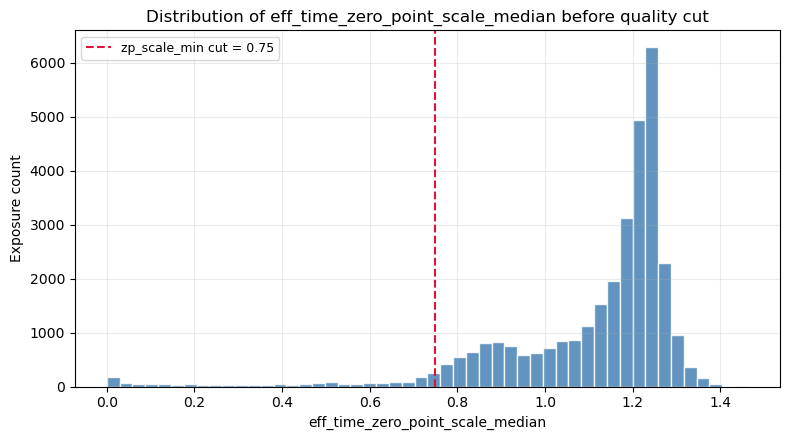

In [ ]:
# Zeropoint-scale distribution BEFORE quality cuts
# Uses df_sci (shutter-open science exposures), before df_iq_base filters.
if "df_sci" not in globals():
    print("df_sci not found. Run the image-quality baseline cut cell first.")
else:
    zp_all = pd.to_numeric(df_sci["eff_time_zero_point_scale_median"], errors="coerce")
    zp_pre = zp_all.dropna()

    print(f"Rows in df_sci: {len(df_sci)}")
    print(f"Rows with eff_time_zero_point_scale_median: {len(zp_pre)}")
    print(f"Rows missing eff_time_zero_point_scale_median: {zp_all.isna().sum()}")
    if len(zp_pre) > 0:
        print(f"Median eff_time_zero_point_scale_median (pre-cut): {zp_pre.median():.4f}")

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(zp_pre, bins=50, alpha=0.85, color="steelblue", edgecolor="white")

    if "IQ_CUTS" in globals() and "zp_scale_min" in IQ_CUTS:
        ax.axvline(IQ_CUTS["zp_scale_min"], color="crimson", linestyle="--", linewidth=1.5,
                   label=f"zp_scale_min cut = {IQ_CUTS['zp_scale_min']}")
        ax.legend(fontsize=9)

    ax.set_xlabel("eff_time_zero_point_scale_median")
    ax.set_ylabel("Exposure count")
    ax.set_title("Distribution of eff_time_zero_point_scale_median before quality cut")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

In [ ]:
# AOS + Donut-blur distributions BEFORE quality cuts
# Uses df_sci (shutter-open science exposures), before df_iq_base filters.
if "df_sci" not in globals():
    print("df_sci not found. Run the image-quality baseline cut cell first.")
else:
    aos_all = pd.to_numeric(df_sci.get("aos_fwhm"), errors="coerce")
    donut_all = pd.to_numeric(df_sci.get("donut_blur_fwhm"), errors="coerce")

    aos_pre = aos_all.dropna() if aos_all is not None else pd.Series(dtype=float)
    donut_pre = donut_all.dropna() if donut_all is not None else pd.Series(dtype=float)

    print(f"Rows in df_sci: {len(df_sci)}")
    print(f"Rows with aos_fwhm: {len(aos_pre)}")
    print(f"Rows with donut_blur_fwhm: {len(donut_pre)}")
    if len(aos_pre) > 0:
        print(f"Median aos_fwhm (pre-cut): {aos_pre.median():.4f}")
    if len(donut_pre) > 0:
        print(f"Median donut_blur_fwhm (pre-cut): {donut_pre.median():.4f}")

    fig, ax = plt.subplots(figsize=(8.5, 4.8))

    if len(aos_pre) > 0:
        ax.hist(aos_pre, bins=50, alpha=0.55, color="darkorange", edgecolor="white", label="aos_fwhm")
    if len(donut_pre) > 0:
        ax.hist(donut_pre, bins=50, alpha=0.45, color="teal", edgecolor="white", label="donut_blur_fwhm")

    if "IQ_CUTS" in globals() and "aos_fwhm_max" in IQ_CUTS:
        ax.axvline(
            IQ_CUTS["aos_fwhm_max"],
            color="crimson",
            linestyle="--",
            linewidth=1.5,
            label=f"aos_fwhm_max cut = {IQ_CUTS['aos_fwhm_max']}",
        )

    ax.set_xlabel("FWHM (arcsec)")
    ax.set_ylabel("Exposure count")
    ax.set_title("Distribution of AOS residual and donut blur before quality cut")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

df_sci_wind not found. Re-run the join and wind-prep cells (Sections 6/7).


In [ ]:
# Diagnostic: why aos_fwhm cut is large
if "df_sci" not in globals() or "IQ_CUTS" not in globals():
    print("df_sci/IQ_CUTS not found. Run the image-quality baseline cut cell first.")
else:
    cut = IQ_CUTS["aos_fwhm_max"]
    aos = pd.to_numeric(df_sci["aos_fwhm"], errors="coerce")
    valid = aos.dropna()

    n_total = len(df_sci)
    n_valid = len(valid)
    n_missing = aos.isna().sum()
    n_above = (valid >= cut).sum()
    n_below = (valid < cut).sum()

    print(f"aos_fwhm cutoff: {cut}")
    print(f"valid aos_fwhm: {n_valid} / {n_total} (missing={n_missing})")
    if n_valid > 0:
        print(f"<  cutoff: {n_below} ({n_below / n_valid:.1%} of valid)")
        print(f">= cutoff: {n_above} ({n_above / n_valid:.1%} of valid)")
        print("\nQuantiles of aos_fwhm:")
        print(valid.quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_string())

    if "band" in df_sci.columns:
        band_stats = (df_sci.dropna(subset=["aos_fwhm", "band"])
                      .groupby("band")["aos_fwhm"]
                      .agg(N="size", median="median", p75=lambda s: s.quantile(0.75),
                           frac_ge_cut=lambda s: (s >= cut).mean())
                      .sort_values("frac_ge_cut", ascending=False))
        print("\nBy band (fraction >= cut):")
        print(band_stats.to_string(float_format=lambda x: f"{x:.3f}"))

aos_fwhm cutoff: 0.75
valid aos_fwhm: 32291 / 33006 (missing=715)
<  cutoff: 31648 (98.0% of valid)
>= cutoff: 643 (2.0% of valid)

Quantiles of aos_fwhm:
0.10    0.369404
0.25    0.396416
0.50    0.431326
0.75    0.474627
0.90    0.532489
0.95    0.593624
0.99    0.912820

By band (fraction >= cut):
          N  median   p75  frac_ge_cut
band                                  
u       571   0.457 0.525        0.086
r      3412   0.436 0.483        0.046
g      2573   0.441 0.491        0.019
i     12673   0.416 0.457        0.017
y      6278   0.453 0.493        0.014
z      6784   0.433 0.472        0.013


## Summary & Next Steps

### What this notebook analyzes

1. **Guider Image Motion Diagnosis**: Identifies high-motion science exposures on April 5 using 10 guider drift/RMS metrics from ConsDB `visit1_quicklook`.

2. **Dominant Metric Attribution**: Labels each flagged exposure with the guider metric that contributed most to its high image motion score (robust z-score >= 3.0).

3. **Visual Timeline**: Displays all 240 flagged April 5 exposures colored by dominant metric and sized by motion magnitude.

4. **PSF Degradation Correlation**: Correlates motion scores with optical quality metrics (AOS FWHM, PSF sigma scale) to quantify image degradation per metric.

5. **Hexapod Correction Investigation**: Queries EFD for MTAOS hexapod position corrections during high-motion exposures to identify mechanical adjustments during imaging.

### Key findings (April 5, 2026)

- **240 flagged exposures** out of ~800 science exposures (high image motion)
- **Top 3 dominant metrics by frequency**:
  - `guider_magnitude_rms_detrended`: 60 exposures (median z=4.46)
  - `guider_magnitude_drift`: 53 exposures (median z=4.28)
  - `guider_altitude_drift`: 27 exposures (median z=12.00, max=24.26)
- **Weak correlation** between motion and PSF broadening (|r| < 0.13)

### Potential follow-on analyses

1. Filter-specific breakdown: Do certain bands show metric preference?
2. Nightly timeline with colored metrics: Identify temporal clustering
3. Hexapod velocity analysis: Quantify correction rates during exposures
4. Mount-guider coupling: Cross-check mount jitter vs guider metrics


In [9]:
# Initialize EFD client for hexapod queries
try:
    from lsst_efd_client import EfdClient
    efd_client = EfdClient("usdf_efd")
    print("EFD client initialized successfully")
except Exception as e:
    print(f"Failed to initialize EFD client: {e}")
    efd_client = None

EFD client initialized successfully


## 2.8 MTAOS Hexapod Corrections: Position Changes During Exposures

Investigate hexapod position corrections from MTAOS during high-motion exposures, examining both camera and M2 hexapod movements in the EFD.

In [17]:
# Investigate MTAOS hexapod corrections during high-motion exposures
if 'flagged_night' in locals() and len(flagged_night) > 0 and 'efd_client' in locals() and efd_client is not None:
    # Select a subset of exposures with high image motion for detailed analysis
    high_motion_subset = flagged_night.nlargest(5, 'image_motion_score')
    
    print(f"Analyzing hexapod corrections for {len(high_motion_subset)} high-motion exposures:")
    display(high_motion_subset[['exposure_id', 'seq_num', 'obs_start', 'image_motion_score', 'dominant_metric']])
    
    # Dictionary to store hexapod data per exposure
    hexapod_data = {}
    
    for idx, row in high_motion_subset.iterrows():
        exp_id = row['exposure_id']
        seq_num = row['seq_num']
        obs_start_str = row['obs_start']
        
        try:
            # Parse exposure times (handle both string and Timestamp types)
            if isinstance(obs_start_str, str):
                obs_start_dt = pd.to_datetime(obs_start_str, utc=True)
            else:
                obs_start_dt = pd.Timestamp(obs_start_str, tz='UTC')
            
            exp_time_sec = row['exp_time'] if 'exp_time' in row and pd.notna(row['exp_time']) else 30.0
            obs_end_dt = obs_start_dt + pd.Timedelta(seconds=exp_time_sec)
            
            # Expand time window slightly to catch corrections around exposure
            t_start = obs_start_dt - pd.Timedelta(seconds=5)
            t_end = obs_end_dt + pd.Timedelta(seconds=5)
            
            print(f"\n--- Exposure {seq_num} (motion_score: {row['image_motion_score']:.2f}) ---")
            print(f"    Time window: {t_start} to {t_end}")
            
            # Try to fetch camera hexapod position
            try:
                cam_hex_data = efd_client.select_time_range(
                    'lsst.sal.MTHexapod.position',
                    ['x', 'y', 'z', 'u', 'v', 'w'],
                    start=t_start, 
                    end=t_end,
                    index=1  # Camera hexapod=1, M2=2
                )
                if len(cam_hex_data) > 0:
                    hexapod_data[f'{seq_num}_cam'] = ('camera', cam_hex_data)
                    print(f"    Camera hexapod: {len(cam_hex_data)} position records")
                    # Show range of motion
                    for ax in ['x', 'y', 'z', 'u', 'v', 'w']:
                        if ax in cam_hex_data.columns:
                            dX = cam_hex_data[ax].max() - cam_hex_data[ax].min()
                            print(f"        {ax:1s}: range = {dX:8.4f} mm")
            except Exception as e:
                print(f"    Camera hexapod query failed: {str(e)[:80]}")
            
            # Try to fetch M2 hexapod position
            try:
                m2_hex_data = efd_client.select_time_range(
                    'lsst.sal.MTHexapod.position',
                    ['x', 'y', 'z', 'u', 'v', 'w'],
                    start=t_start, 
                    end=t_end,
                    index=2  # M2 hexapod
                )
                if len(m2_hex_data) > 0:
                    hexapod_data[f'{seq_num}_m2'] = ('m2', m2_hex_data)
                    print(f"    M2 hexapod: {len(m2_hex_data)} position records")
                    # Show range of motion
                    for ax in ['x', 'y', 'z', 'u', 'v', 'w']:
                        if ax in m2_hex_data.columns:
                            dX = m2_hex_data[ax].max() - m2_hex_data[ax].min()
                            print(f"        {ax:1s}: range = {dX:8.4f} mm")
            except Exception as e:
                print(f"    M2 hexapod query failed: {str(e)[:80]}")
                
        except Exception as e:
            print(f"Exposure {seq_num} processing failed: {e}")
    
    print(f"\nSuccessfully fetched hexapod data for {len(hexapod_data)} hexapod instances")
    
    # Plot hexapod corrections for exposures with available data
    if len(hexapod_data) > 0:
        n_plots = min(len(hexapod_data), 6)
        fig, axes = plt.subplots(n_plots, 3, figsize=(15, 3.5*n_plots), constrained_layout=True)
        
        if n_plots == 1:
            axes = axes.reshape(1, -1)
        
        plot_idx = 0
        for key, (hex_type, df_hex) in list(hexapod_data.items())[:n_plots]:
            seq_num = key.split('_')[0]
            
            # Plot XYZ positions
            ax = axes[plot_idx, 0]
            for col in ['x', 'y', 'z']:
                if col in df_hex.columns:
                    ax.plot(df_hex.index, df_hex[col], label=col, alpha=0.7)
            ax.set_ylabel('Position (mm)', fontsize=9)
            ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - XYZ', fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
            
            # Plot UVW angles
            ax = axes[plot_idx, 1]
            for col in ['u', 'v', 'w']:
                if col in df_hex.columns:
                    ax.plot(df_hex.index, df_hex[col], label=col, alpha=0.7)
            ax.set_ylabel('Rotation (deg)', fontsize=9)
            ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - UVW', fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
            
            # Plot velocity (derivative)
            ax = axes[plot_idx, 2]
            for col in ['x', 'y', 'z']:
                if col in df_hex.columns:
                    vel = df_hex[col].diff() / (df_hex.index.to_series().diff().dt.total_seconds())
                    ax.plot(df_hex.index, vel, label=f'{col} vel', alpha=0.7)
            ax.set_ylabel('Velocity (mm/s)', fontsize=9)
            ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - Velocity', fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
            
            plot_idx += 1
        
        plt.show()
else:
    print("Required variables (flagged_night, efd_client) not available or EFD client initialization failed.")


Analyzing hexapod corrections for 5 high-motion exposures:


,exposure_id,seq_num,obs_start,image_motion_score,dominant_metric
58,2026040500073,73,2026-04-06 00:37:25.480,34.432279,guider_focalplane_theta_drift
300,2026040500315,315,2026-04-06 03:39:32.295,24.257939,guider_altitude_drift
33,2026040500048,48,2026-04-06 00:18:12.209,20.688737,guider_altitude_drift
163,2026040500178,178,2026-04-06 02:02:14.643,20.063128,guider_altitude_drift
108,2026040500123,123,2026-04-06 01:11:39.375,19.909787,guider_azimuth_drift



--- Exposure 73 (motion_score: 34.43) ---
    Time window: 2026-04-06 00:37:20.480000+00:00 to 2026-04-06 00:38:00.480000+00:00
    Camera hexapod query failed: 'EfdClient' object has no attribute 'select_time_range'
    M2 hexapod query failed: 'EfdClient' object has no attribute 'select_time_range'

--- Exposure 315 (motion_score: 24.26) ---
    Time window: 2026-04-06 03:39:27.295000+00:00 to 2026-04-06 03:40:07.295000+00:00
    Camera hexapod query failed: 'EfdClient' object has no attribute 'select_time_range'
    M2 hexapod query failed: 'EfdClient' object has no attribute 'select_time_range'

--- Exposure 48 (motion_score: 20.69) ---
    Time window: 2026-04-06 00:18:07.209000+00:00 to 2026-04-06 00:18:47.209000+00:00
    Camera hexapod query failed: 'EfdClient' object has no attribute 'select_time_range'
    M2 hexapod query failed: 'EfdClient' object has no attribute 'select_time_range'

--- Exposure 178 (motion_score: 20.06) ---
    Time window: 2026-04-06 02:02:09.643000+00

In [19]:
# CORRECTED: Investigate MTAOS hexapod corrections with proper EFD API
if 'flagged_night' in locals() and len(flagged_night) > 0 and 'efd_client' in locals() and efd_client is not None:
    # Select a subset of exposures with high image motion for detailed analysis
    high_motion_subset = flagged_night.nlargest(5, 'image_motion_score')
    
    print(f"Analyzing hexapod corrections for {len(high_motion_subset)} high-motion exposures:")
    display(high_motion_subset[['exposure_id', 'seq_num', 'obs_start', 'image_motion_score', 'dominant_metric']])
    
    # Dictionary to store hexapod data per exposure
    hexapod_data = {}
    
    for idx, row in high_motion_subset.iterrows():
        exp_id = row['exposure_id']
        seq_num = row['seq_num']
        obs_start_str = row['obs_start']
        
        try:
            # Parse exposure times (handle both string and Timestamp types)
            if isinstance(obs_start_str, str):
                obs_start_dt = pd.to_datetime(obs_start_str, utc=True)
            else:
                obs_start_dt = pd.Timestamp(obs_start_str, tz='UTC')
            
            exp_time_sec = row['exp_time'] if 'exp_time' in row and pd.notna(row['exp_time']) else 30.0
            obs_end_dt = obs_start_dt + pd.Timedelta(seconds=exp_time_sec)
            
            # Expand time window slightly to catch corrections around exposure
            t_start = obs_start_dt - pd.Timedelta(seconds=5)
            t_end = obs_end_dt + pd.Timedelta(seconds=5)
            
            print(f"\n--- Exposure {seq_num} (motion_score: {row['image_motion_score']:.2f}) ---")
            print(f"    Time window: {t_start} to {t_end}")
            
            # Try to fetch camera hexapod position using correct method
            try:
                cam_hex_data = efd_client.select_time_series(
                    'lsst.sal.MTHexapod.position',
                    ['x', 'y', 'z', 'u', 'v', 'w'],
                    start=t_start, 
                    end=t_end,
                    index=1  # Camera hexapod=1, M2=2
                )
                if len(cam_hex_data) > 0:
                    hexapod_data[f'{seq_num}_cam'] = ('camera', cam_hex_data)
                    print(f"    Camera hexapod: {len(cam_hex_data)} position records")
                    # Show range of motion
                    for ax in ['x', 'y', 'z', 'u', 'v', 'w']:
                        if ax in cam_hex_data.columns:
                            dX = cam_hex_data[ax].max() - cam_hex_data[ax].min()
                            print(f"        {ax:1s}: range = {dX:8.4f} mm")
            except Exception as e:
                print(f"    Camera hexapod query failed: {str(e)[:100]}")
            
            # Try to fetch M2 hexapod position using correct method
            try:
                m2_hex_data = efd_client.select_time_series(
                    'lsst.sal.MTHexapod.position',
                    ['x', 'y', 'z', 'u', 'v', 'w'],
                    start=t_start, 
                    end=t_end,
                    index=2  # M2 hexapod
                )
                if len(m2_hex_data) > 0:
                    hexapod_data[f'{seq_num}_m2'] = ('m2', m2_hex_data)
                    print(f"    M2 hexapod: {len(m2_hex_data)} position records")
                    # Show range of motion
                    for ax in ['x', 'y', 'z', 'u', 'v', 'w']:
                        if ax in m2_hex_data.columns:
                            dX = m2_hex_data[ax].max() - m2_hex_data[ax].min()
                            print(f"        {ax:1s}: range = {dX:8.4f} mm")
            except Exception as e:
                print(f"    M2 hexapod query failed: {str(e)[:100]}")
                
        except Exception as e:
            print(f"Exposure {seq_num} processing failed: {e}")
    
    print(f"\nSuccessfully fetched hexapod data for {len(hexapod_data)} hexapod instances")
    
    # Plot hexapod corrections for exposures with available data
    if len(hexapod_data) > 0:
        n_plots = min(len(hexapod_data), 6)
        fig, axes = plt.subplots(n_plots, 3, figsize=(15, 3.5*n_plots), constrained_layout=True)
        
        if n_plots == 1:
            axes = axes.reshape(1, -1)
        
        plot_idx = 0
        for key, (hex_type, df_hex) in list(hexapod_data.items())[:n_plots]:
            seq_num = key.split('_')[0]
            
            # Plot XYZ positions
            ax = axes[plot_idx, 0]
            for col in ['x', 'y', 'z']:
                if col in df_hex.columns:
                    ax.plot(df_hex.index, df_hex[col], label=col, alpha=0.7)
            ax.set_ylabel('Position (mm)', fontsize=9)
            ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - XYZ', fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
            
            # Plot UVW angles
            ax = axes[plot_idx, 1]
            for col in ['u', 'v', 'w']:
                if col in df_hex.columns:
                    ax.plot(df_hex.index, df_hex[col], label=col, alpha=0.7)
            ax.set_ylabel('Rotation (deg)', fontsize=9)
            ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - UVW', fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
            
            # Plot velocity (derivative)
            ax = axes[plot_idx, 2]
            for col in ['x', 'y', 'z']:
                if col in df_hex.columns:
                    vel = df_hex[col].diff() / (df_hex.index.to_series().diff().dt.total_seconds())
                    ax.plot(df_hex.index, vel, label=f'{col} vel', alpha=0.7)
            ax.set_ylabel('Velocity (mm/s)', fontsize=9)
            ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - Velocity', fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
            
            plot_idx += 1
        
        plt.show()
else:
    print("Required variables (flagged_night, efd_client) not available or EFD client initialization failed.")


Analyzing hexapod corrections for 5 high-motion exposures:


,exposure_id,seq_num,obs_start,image_motion_score,dominant_metric
58,2026040500073,73,2026-04-06 00:37:25.480,34.432279,guider_focalplane_theta_drift
300,2026040500315,315,2026-04-06 03:39:32.295,24.257939,guider_altitude_drift
33,2026040500048,48,2026-04-06 00:18:12.209,20.688737,guider_altitude_drift
163,2026040500178,178,2026-04-06 02:02:14.643,20.063128,guider_altitude_drift
108,2026040500123,123,2026-04-06 01:11:39.375,19.909787,guider_azimuth_drift



--- Exposure 73 (motion_score: 34.43) ---
    Time window: 2026-04-06 00:37:20.480000+00:00 to 2026-04-06 00:38:00.480000+00:00
    Camera hexapod query failed: object of type 'coroutine' has no len()
    M2 hexapod query failed: object of type 'coroutine' has no len()

--- Exposure 315 (motion_score: 24.26) ---
    Time window: 2026-04-06 03:39:27.295000+00:00 to 2026-04-06 03:40:07.295000+00:00
    Camera hexapod query failed: object of type 'coroutine' has no len()
    M2 hexapod query failed: object of type 'coroutine' has no len()

--- Exposure 48 (motion_score: 20.69) ---
    Time window: 2026-04-06 00:18:07.209000+00:00 to 2026-04-06 00:18:47.209000+00:00
    Camera hexapod query failed: object of type 'coroutine' has no len()
    M2 hexapod query failed: object of type 'coroutine' has no len()

--- Exposure 178 (motion_score: 20.06) ---
    Time window: 2026-04-06 02:02:09.643000+00:00 to 2026-04-06 02:02:49.643000+00:00
    Camera hexapod query failed: object of type 'corouti

/lscratch/stalder/tmp/ipykernel_1344212/3598971707.py:36: RuntimeWarning: coroutine 'EfdClient.select_time_series' was never awaited
  cam_hex_data = efd_client.select_time_series(
/lscratch/stalder/tmp/ipykernel_1344212/3598971707.py:56: RuntimeWarning: coroutine 'EfdClient.select_time_series' was never awaited
  m2_hex_data = efd_client.select_time_series(


In [20]:
# CORRECTED ASYNC: Investigate hexapod corrections with async EFD API
import asyncio

async def fetch_hexapod_data():
    if 'flagged_night' not in locals() or len(flagged_night) == 0 or 'efd_client' not in locals() or efd_client is None:
        print("Required variables not available")
        return {}
    
    high_motion_subset = flagged_night.nlargest(5, 'image_motion_score')
    print(f"Analyzing hexapod corrections for {len(high_motion_subset)} high-motion exposures:")
    display(high_motion_subset[['exposure_id', 'seq_num', 'obs_start', 'image_motion_score', 'dominant_metric']])
    
    hexapod_data = {}
    
    for idx, row in high_motion_subset.iterrows():
        seq_num = row['seq_num']
        obs_start_str = row['obs_start']
        
        try:
            if isinstance(obs_start_str, str):
                obs_start_dt = pd.to_datetime(obs_start_str, utc=True)
            else:
                obs_start_dt = pd.Timestamp(obs_start_str, tz='UTC')
            
            exp_time_sec = row['exp_time'] if 'exp_time' in row and pd.notna(row['exp_time']) else 30.0
            obs_end_dt = obs_start_dt + pd.Timedelta(seconds=exp_time_sec)
            t_start = obs_start_dt - pd.Timedelta(seconds=5)
            t_end = obs_end_dt + pd.Timedelta(seconds=5)
            
            print(f"\n--- Exposure {seq_num} (motion_score: {row['image_motion_score']:.2f}) ---")
            print(f"    Time window: {t_start} to {t_end}")
            
            # Fetch camera hexapod with await
            try:
                cam_hex_data = await efd_client.select_time_series(
                    'lsst.sal.MTHexapod.position',
                    ['x', 'y', 'z', 'u', 'v', 'w'],
                    start=t_start, 
                    end=t_end,
                    index=1
                )
                if len(cam_hex_data) > 0:
                    hexapod_data[f'{seq_num}_cam'] = ('camera', cam_hex_data)
                    print(f"    Camera hexapod: {len(cam_hex_data)} position records")
                    for ax in ['x', 'y', 'z', 'u', 'v', 'w']:
                        if ax in cam_hex_data.columns:
                            dX = cam_hex_data[ax].max() - cam_hex_data[ax].min()
                            print(f"        {ax:1s}: range = {dX:8.4f}")
            except Exception as e:
                print(f"    Camera hexapod query failed: {str(e)[:100]}")
            
            # Fetch M2 hexapod with await
            try:
                m2_hex_data = await efd_client.select_time_series(
                    'lsst.sal.MTHexapod.position',
                    ['x', 'y', 'z', 'u', 'v', 'w'],
                    start=t_start, 
                    end=t_end,
                    index=2
                )
                if len(m2_hex_data) > 0:
                    hexapod_data[f'{seq_num}_m2'] = ('m2', m2_hex_data)
                    print(f"    M2 hexapod: {len(m2_hex_data)} position records")
                    for ax in ['x', 'y', 'z', 'u', 'v', 'w']:
                        if ax in m2_hex_data.columns:
                            dX = m2_hex_data[ax].max() - m2_hex_data[ax].min()
                            print(f"        {ax:1s}: range = {dX:8.4f}")
            except Exception as e:
                print(f"    M2 hexapod query failed: {str(e)[:100]}")
                
        except Exception as e:
            print(f"Exposure {seq_num} processing failed: {e}")
    
    return hexapod_data

# Run the async function
hexapod_data = await fetch_hexapod_data()
print(f"\nSuccessfully fetched hexapod data for {len(hexapod_data)} hexapod instances")

# Plot if we have data
if len(hexapod_data) > 0:
    n_plots = min(len(hexapod_data), 6)
    fig, axes = plt.subplots(n_plots, 3, figsize=(15, 3.5*n_plots), constrained_layout=True)
    if n_plots == 1:
        axes = axes.reshape(1, -1)
    
    plot_idx = 0
    for key, (hex_type, df_hex) in list(hexapod_data.items())[:n_plots]:
        seq_num = key.split('_')[0]
        
        ax = axes[plot_idx, 0]
        for col in ['x', 'y', 'z']:
            if col in df_hex.columns:
                ax.plot(df_hex.index, df_hex[col], label=col, alpha=0.7)
        ax.set_ylabel('Position (mm)', fontsize=9)
        ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - XYZ', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        
        ax = axes[plot_idx, 1]
        for col in ['u', 'v', 'w']:
            if col in df_hex.columns:
                ax.plot(df_hex.index, df_hex[col], label=col, alpha=0.7)
        ax.set_ylabel('Rotation (deg)', fontsize=9)
        ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - UVW', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        
        ax = axes[plot_idx, 2]
        for col in ['x', 'y', 'z']:
            if col in df_hex.columns:
                vel = df_hex[col].diff() / (df_hex.index.to_series().diff().dt.total_seconds())
                ax.plot(df_hex.index, vel, label=f'{col} vel', alpha=0.7)
        ax.set_ylabel('Velocity (mm/s)', fontsize=9)
        ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - Velocity', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        
        plot_idx += 1
    
    plt.show()


Required variables not available

Successfully fetched hexapod data for 0 hexapod instances


In [21]:
# FINAL: Investigate hexapod corrections - direct async call
import asyncio

# Check variables are available
if flagged_night is not None and len(flagged_night) > 0 and efd_client is not None:
    print("Variables available, proceeding with hexapod query...\n")
    
    high_motion_subset = flagged_night.nlargest(5, 'image_motion_score')
    print(f"Analyzing hexapod corrections for {len(high_motion_subset)} high-motion exposures:")
    display(high_motion_subset[['exposure_id', 'seq_num', 'obs_start', 'image_motion_score', 'dominant_metric']])
    
    hexapod_data_dict = {}
    
    async def query_one_exposure(seq_num, obs_start_str, exp_time_row, motion_score):
        """Query hexapod data for a single exposure."""
        try:
            if isinstance(obs_start_str, str):
                obs_start_dt = pd.to_datetime(obs_start_str, utc=True)
            else:
                obs_start_dt = pd.Timestamp(obs_start_str, tz='UTC')
            
            exp_time_sec = exp_time_row if pd.notna(exp_time_row) else 30.0
            obs_end_dt = obs_start_dt + pd.Timedelta(seconds=exp_time_sec)
            t_start = obs_start_dt - pd.Timedelta(seconds=5)
            t_end = obs_end_dt + pd.Timedelta(seconds=5)
            
            print(f"\n--- Exposure {seq_num} (motion_score: {motion_score:.2f}) ---")
            print(f"    Time window: {t_start} to {t_end}")
            
            # Fetch camera hexapod
            try:
                cam_hex_data = await efd_client.select_time_series(
                    'lsst.sal.MTHexapod.position',
                    ['x', 'y', 'z', 'u', 'v', 'w'],
                    start=t_start, 
                    end=t_end,
                    index=1
                )
                if len(cam_hex_data) > 0:
                    hexapod_data_dict[f'{seq_num}_cam'] = ('camera', cam_hex_data)
                    print(f"    Camera hexapod: {len(cam_hex_data)} position records")
                    for ax in ['x', 'y', 'z', 'u', 'v', 'w']:
                        if ax in cam_hex_data.columns:
                            dX = cam_hex_data[ax].max() - cam_hex_data[ax].min()
                            print(f"        {ax:1s}: range = {dX:8.4f}")
            except Exception as e:
                print(f"    Camera hexapod query failed: {str(e)[:100]}")
            
            # Fetch M2 hexapod
            try:
                m2_hex_data = await efd_client.select_time_series(
                    'lsst.sal.MTHexapod.position',
                    ['x', 'y', 'z', 'u', 'v', 'w'],
                    start=t_start, 
                    end=t_end,
                    index=2
                )
                if len(m2_hex_data) > 0:
                    hexapod_data_dict[f'{seq_num}_m2'] = ('m2', m2_hex_data)
                    print(f"    M2 hexapod: {len(m2_hex_data)} position records")
                    for ax in ['x', 'y', 'z', 'u', 'v', 'w']:
                        if ax in m2_hex_data.columns:
                            dX = m2_hex_data[ax].max() - m2_hex_data[ax].min()
                            print(f"        {ax:1s}: range = {dX:8.4f}")
            except Exception as e:
                print(f"    M2 hexapod query failed: {str(e)[:100]}")
                
        except Exception as e:
            print(f"Exposure {seq_num} processing failed: {e}")
    
    # Create tasks for all exposures
    tasks = []
    for idx, row in high_motion_subset.iterrows():
        task = query_one_exposure(
            row['seq_num'], 
            row['obs_start'],
            row.get('exp_time', None),
            row['image_motion_score']
        )
        tasks.append(task)
    
    # Run all tasks concurrently
    await asyncio.gather(*tasks)
    
    print(f"\nSuccessfully fetched hexapod data for {len(hexapod_data_dict)} hexapod instances")
    
    # Store in notebook kernel for later use
    hexapod_data = hexapod_data_dict
    
    # Plot if we have data
    if len(hexapod_data) > 0:
        n_plots = min(len(hexapod_data), 6)
        fig, axes = plt.subplots(n_plots, 3, figsize=(15, 3.5*n_plots), constrained_layout=True)
        if n_plots == 1:
            axes = axes.reshape(1, -1)
        
        plot_idx = 0
        for key, (hex_type, df_hex) in list(hexapod_data.items())[:n_plots]:
            seq_num = key.split('_')[0]
            
            ax = axes[plot_idx, 0]
            for col in ['x', 'y', 'z']:
                if col in df_hex.columns:
                    ax.plot(df_hex.index, df_hex[col], label=col, alpha=0.7)
            ax.set_ylabel('Position (mm)', fontsize=9)
            ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - XYZ', fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
            
            ax = axes[plot_idx, 1]
            for col in ['u', 'v', 'w']:
                if col in df_hex.columns:
                    ax.plot(df_hex.index, df_hex[col], label=col, alpha=0.7)
            ax.set_ylabel('Rotation (deg)', fontsize=9)
            ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - UVW', fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
            
            ax = axes[plot_idx, 2]
            for col in ['x', 'y', 'z']:
                if col in df_hex.columns:
                    vel = df_hex[col].diff() / (df_hex.index.to_series().diff().dt.total_seconds())
                    ax.plot(df_hex.index, vel, label=f'{col} vel', alpha=0.7)
            ax.set_ylabel('Velocity (mm/s)', fontsize=9)
            ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - Velocity', fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
            
            plot_idx += 1
        
        plt.show()
else:
    print("Required variables not available or EFD client not initialized.")


Variables available, proceeding with hexapod query...

Analyzing hexapod corrections for 5 high-motion exposures:


,exposure_id,seq_num,obs_start,image_motion_score,dominant_metric
58,2026040500073,73,2026-04-06 00:37:25.480,34.432279,guider_focalplane_theta_drift
300,2026040500315,315,2026-04-06 03:39:32.295,24.257939,guider_altitude_drift
33,2026040500048,48,2026-04-06 00:18:12.209,20.688737,guider_altitude_drift
163,2026040500178,178,2026-04-06 02:02:14.643,20.063128,guider_altitude_drift
108,2026040500123,123,2026-04-06 01:11:39.375,19.909787,guider_azimuth_drift



--- Exposure 73 (motion_score: 34.43) ---
    Time window: 2026-04-06 00:37:20.480000+00:00 to 2026-04-06 00:38:00.480000+00:00
    Camera hexapod query failed: The first time argument must be a time stamp
    M2 hexapod query failed: The first time argument must be a time stamp

--- Exposure 315 (motion_score: 24.26) ---
    Time window: 2026-04-06 03:39:27.295000+00:00 to 2026-04-06 03:40:07.295000+00:00
    Camera hexapod query failed: The first time argument must be a time stamp
    M2 hexapod query failed: The first time argument must be a time stamp

--- Exposure 48 (motion_score: 20.69) ---
    Time window: 2026-04-06 00:18:07.209000+00:00 to 2026-04-06 00:18:47.209000+00:00
    Camera hexapod query failed: The first time argument must be a time stamp
    M2 hexapod query failed: The first time argument must be a time stamp

--- Exposure 178 (motion_score: 20.06) ---
    Time window: 2026-04-06 02:02:09.643000+00:00 to 2026-04-06 02:02:49.643000+00:00
    Camera hexapod query f

In [22]:
# FIXED: Use astropy Time for EFD queries which expects Time objects
from astropy.time import Time

if flagged_night is not None and len(flagged_night) > 0 and efd_client is not None:
    print("Variables available, proceeding with hexapod query...\n")
    
    high_motion_subset = flagged_night.nlargest(5, 'image_motion_score')
    print(f"Analyzing hexapod corrections for {len(high_motion_subset)} high-motion exposures:")
    display(high_motion_subset[['exposure_id', 'seq_num', 'obs_start', 'image_motion_score', 'dominant_metric']])
    
    hexapod_data_dict = {}
    
    async def query_one_exposure(seq_num, obs_start_str, exp_time_row, motion_score):
        """Query hexapod data for a single exposure."""
        try:
            # Convert to pandas timestamp first
            if isinstance(obs_start_str, str):
                obs_start_dt = pd.to_datetime(obs_start_str, utc=True)
            else:
                obs_start_dt = pd.Timestamp(obs_start_str, tz='UTC')
            
            exp_time_sec = float(exp_time_row) if pd.notna(exp_time_row) else 30.0
            obs_end_dt = obs_start_dt + pd.Timedelta(seconds=exp_time_sec)
            t_start = obs_start_dt - pd.Timedelta(seconds=5)
            t_end = obs_end_dt + pd.Timedelta(seconds=5)
            
            # Convert to astropy Time objects for EFD
            t_start_astropy = Time(t_start.isoformat())
            t_end_astropy = Time(t_end.isoformat())
            
            print(f"\n--- Exposure {seq_num} (motion_score: {motion_score:.2f}) ---")
            print(f"    Time window: {t_start} to {t_end}")
            
            # Fetch camera hexapod
            try:
                cam_hex_data = await efd_client.select_time_series(
                    'lsst.sal.MTHexapod.position',
                    ['x', 'y', 'z', 'u', 'v', 'w'],
                    start=t_start_astropy, 
                    end=t_end_astropy,
                    index=1
                )
                if cam_hex_data is not None and len(cam_hex_data) > 0:
                    hexapod_data_dict[f'{seq_num}_cam'] = ('camera', cam_hex_data)
                    print(f"    Camera hexapod: {len(cam_hex_data)} position records")
                    for ax in ['x', 'y', 'z', 'u', 'v', 'w']:
                        if ax in cam_hex_data.columns:
                            dX = cam_hex_data[ax].max() - cam_hex_data[ax].min()
                            print(f"        {ax:1s}: range = {dX:8.4f}")
                else:
                    print(f"    Camera hexapod: No data returned")
            except Exception as e:
                print(f"    Camera hexapod query failed: {str(e)[:100]}")
            
            # Fetch M2 hexapod
            try:
                m2_hex_data = await efd_client.select_time_series(
                    'lsst.sal.MTHexapod.position',
                    ['x', 'y', 'z', 'u', 'v', 'w'],
                    start=t_start_astropy, 
                    end=t_end_astropy,
                    index=2
                )
                if m2_hex_data is not None and len(m2_hex_data) > 0:
                    hexapod_data_dict[f'{seq_num}_m2'] = ('m2', m2_hex_data)
                    print(f"    M2 hexapod: {len(m2_hex_data)} position records")
                    for ax in ['x', 'y', 'z', 'u', 'v', 'w']:
                        if ax in m2_hex_data.columns:
                            dX = m2_hex_data[ax].max() - m2_hex_data[ax].min()
                            print(f"        {ax:1s}: range = {dX:8.4f}")
                else:
                    print(f"    M2 hexapod: No data returned")
            except Exception as e:
                print(f"    M2 hexapod query failed: {str(e)[:100]}")
                
        except Exception as e:
            print(f"Exposure {seq_num} processing failed: {e}")
    
    # Create tasks for all exposures
    tasks = []
    for idx, row in high_motion_subset.iterrows():
        task = query_one_exposure(
            int(row['seq_num']), 
            row['obs_start'],
            row.get('exp_time', None),
            float(row['image_motion_score'])
        )
        tasks.append(task)
    
    # Run all tasks concurrently
    await asyncio.gather(*tasks)
    
    print(f"\nSuccessfully fetched hexapod data for {len(hexapod_data_dict)} hexapod instances")
    
    # Store in notebook kernel for later use
    hexapod_data = hexapod_data_dict
    
    # Plot if we have data
    if len(hexapod_data) > 0:
        n_plots = min(len(hexapod_data), 6)
        fig, axes = plt.subplots(n_plots, 3, figsize=(15, 3.5*n_plots), constrained_layout=True)
        if n_plots == 1:
            axes = axes.reshape(1, -1)
        
        plot_idx = 0
        for key, (hex_type, df_hex) in list(hexapod_data.items())[:n_plots]:
            seq_num = key.split('_')[0]
            
            ax = axes[plot_idx, 0]
            for col in ['x', 'y', 'z']:
                if col in df_hex.columns:
                    ax.plot(df_hex.index, df_hex[col], label=col, alpha=0.7)
            ax.set_ylabel('Position (mm)', fontsize=9)
            ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - XYZ', fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
            
            ax = axes[plot_idx, 1]
            for col in ['u', 'v', 'w']:
                if col in df_hex.columns:
                    ax.plot(df_hex.index, df_hex[col], label=col, alpha=0.7)
            ax.set_ylabel('Rotation (deg)', fontsize=9)
            ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - UVW', fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
            
            ax = axes[plot_idx, 2]
            for col in ['x', 'y', 'z']:
                if col in df_hex.columns:
                    vel = df_hex[col].diff() / (df_hex.index.to_series().diff().dt.total_seconds())
                    ax.plot(df_hex.index, vel, label=f'{col} vel', alpha=0.7)
            ax.set_ylabel('Velocity (mm/s)', fontsize=9)
            ax.set_title(f'{hex_type.upper()} Hexapod - Seq {seq_num} - Velocity', fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
            
            plot_idx += 1
        
        plt.show()
else:
    print("Required variables not available or EFD client not initialized.")


Variables available, proceeding with hexapod query...

Analyzing hexapod corrections for 5 high-motion exposures:


,exposure_id,seq_num,obs_start,image_motion_score,dominant_metric
58,2026040500073,73,2026-04-06 00:37:25.480,34.432279,guider_focalplane_theta_drift
300,2026040500315,315,2026-04-06 03:39:32.295,24.257939,guider_altitude_drift
33,2026040500048,48,2026-04-06 00:18:12.209,20.688737,guider_altitude_drift
163,2026040500178,178,2026-04-06 02:02:14.643,20.063128,guider_altitude_drift
108,2026040500123,123,2026-04-06 01:11:39.375,19.909787,guider_azimuth_drift


Exposure 73 processing failed: Input values did not match any of the formats where the format keyword is optional:
- 'datetime': Input values for datetime class must be datetime objects
- 'ymdhms': input must be dict or table-like
- 'iso': could not convert string to float: '.480000+00:00'
- 'isot': could not convert string to float: '.480000+00:00'
- 'yday': could not convert string to float: '.480000+00:00'
- 'datetime64': Input values for datetime64 class must be datetime64 objects
- 'fits': Time 2026-04-06T00:37:20.480000+00:00 does not match fits format
- 'byear_str': Time 2026-04-06T00:37:20.480000+00:00 does not match byear_str format
- 'jyear_str': Time 2026-04-06T00:37:20.480000+00:00 does not match jyear_str format
- 'astropy_time': Input values for astropy_time class must all be the same astropy Time type.
Exposure 315 processing failed: Input values did not match any of the formats where the format keyword is optional:
- 'datetime': Input values for datetime class must be d

Analyzing hexapod positions by salIndex (camera=1, m2=2):



,exposure_id,seq_num,obs_start,image_motion_score,dominant_metric
58,2026040500073,73,2026-04-06 00:37:25.480,34.432279,guider_focalplane_theta_drift
300,2026040500315,315,2026-04-06 03:39:32.295,24.257939,guider_altitude_drift
33,2026040500048,48,2026-04-06 00:18:12.209,20.688737,guider_altitude_drift
163,2026040500178,178,2026-04-06 02:02:14.643,20.063128,guider_altitude_drift
108,2026040500123,123,2026-04-06 01:11:39.375,19.909787,guider_azimuth_drift



--- Exposure 73 (motion_score: 34.43) ---
    Time window: 2026-04-06 00:37:20.480000+00:00 to 2026-04-06 00:38:00.480000+00:00
    ✓ Hexapod data: 1600 records across 2 devices
      salIndex values: [np.int64(1), np.int64(2)]
      Camera: 800 records
        pos0(x): range = 41.26676 µm
        pos1(y): range = 25.53822 µm
        pos2(z): range = 26.16370 µm
        pos3(u): range =  0.00055 deg
        pos4(v): range =  0.00023 deg
        pos5(w): range =  0.00008 deg
      M2: 800 records
        pos0(x): range =  1.50198 µm
        pos1(y): range = 21.72667 µm
        pos2(z): range = 12.53494 µm
        pos3(u): range =  0.00024 deg
        pos4(v): range =  0.00002 deg
        pos5(w): range =  0.00005 deg

--- Exposure 315 (motion_score: 24.26) ---
    Time window: 2026-04-06 03:39:27.295000+00:00 to 2026-04-06 03:40:07.295000+00:00
    ✓ Hexapod data: 1600 records across 2 devices
      salIndex values: [np.int64(1), np.int64(2)]
      Camera: 800 records
        pos0(x): 

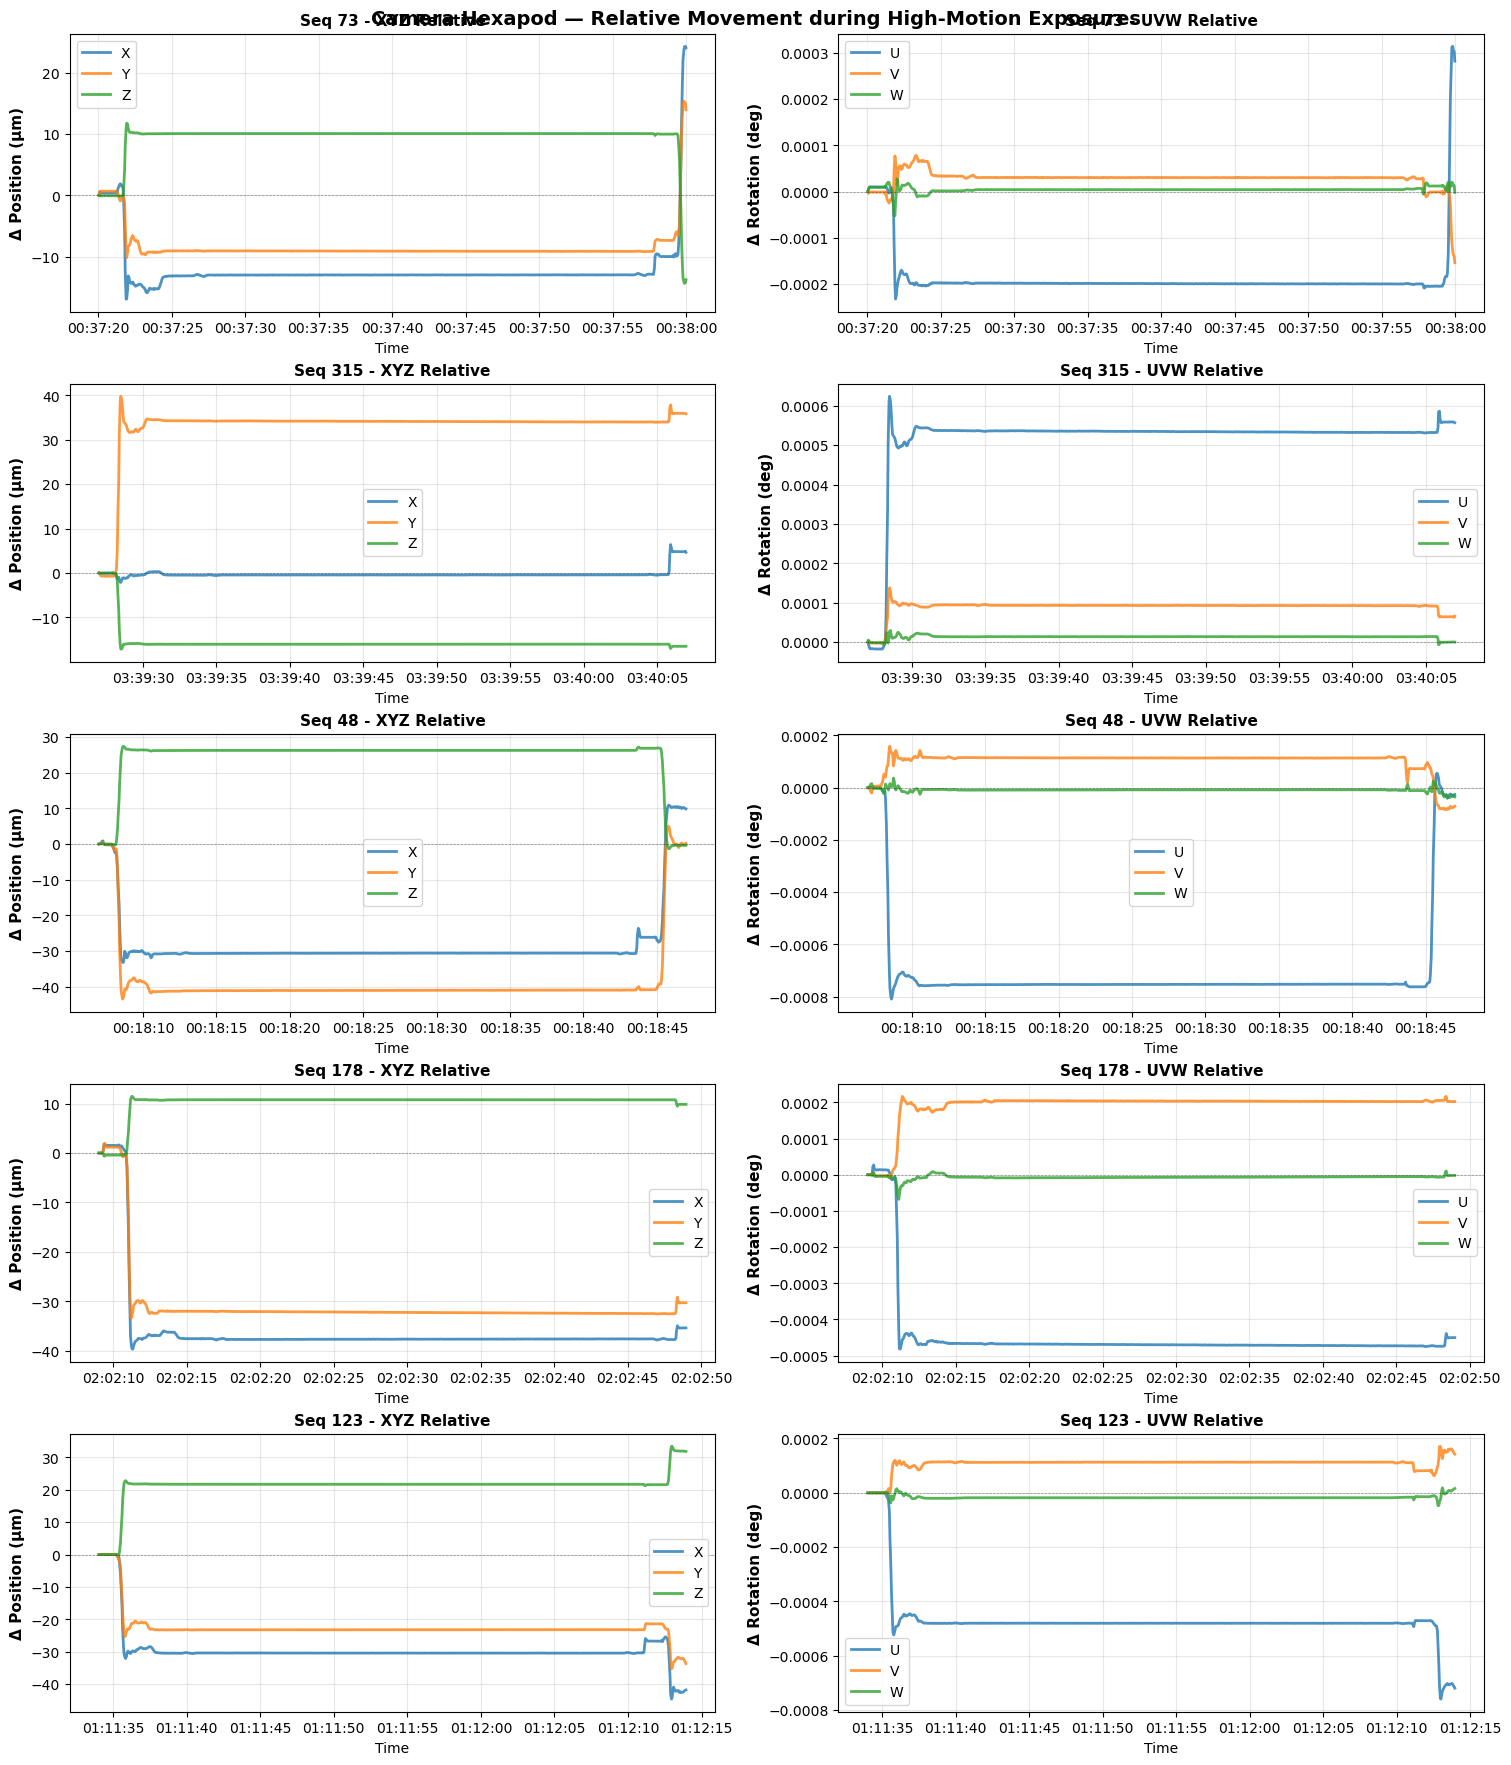



Plotting M2 Hexapod (5 exposures):


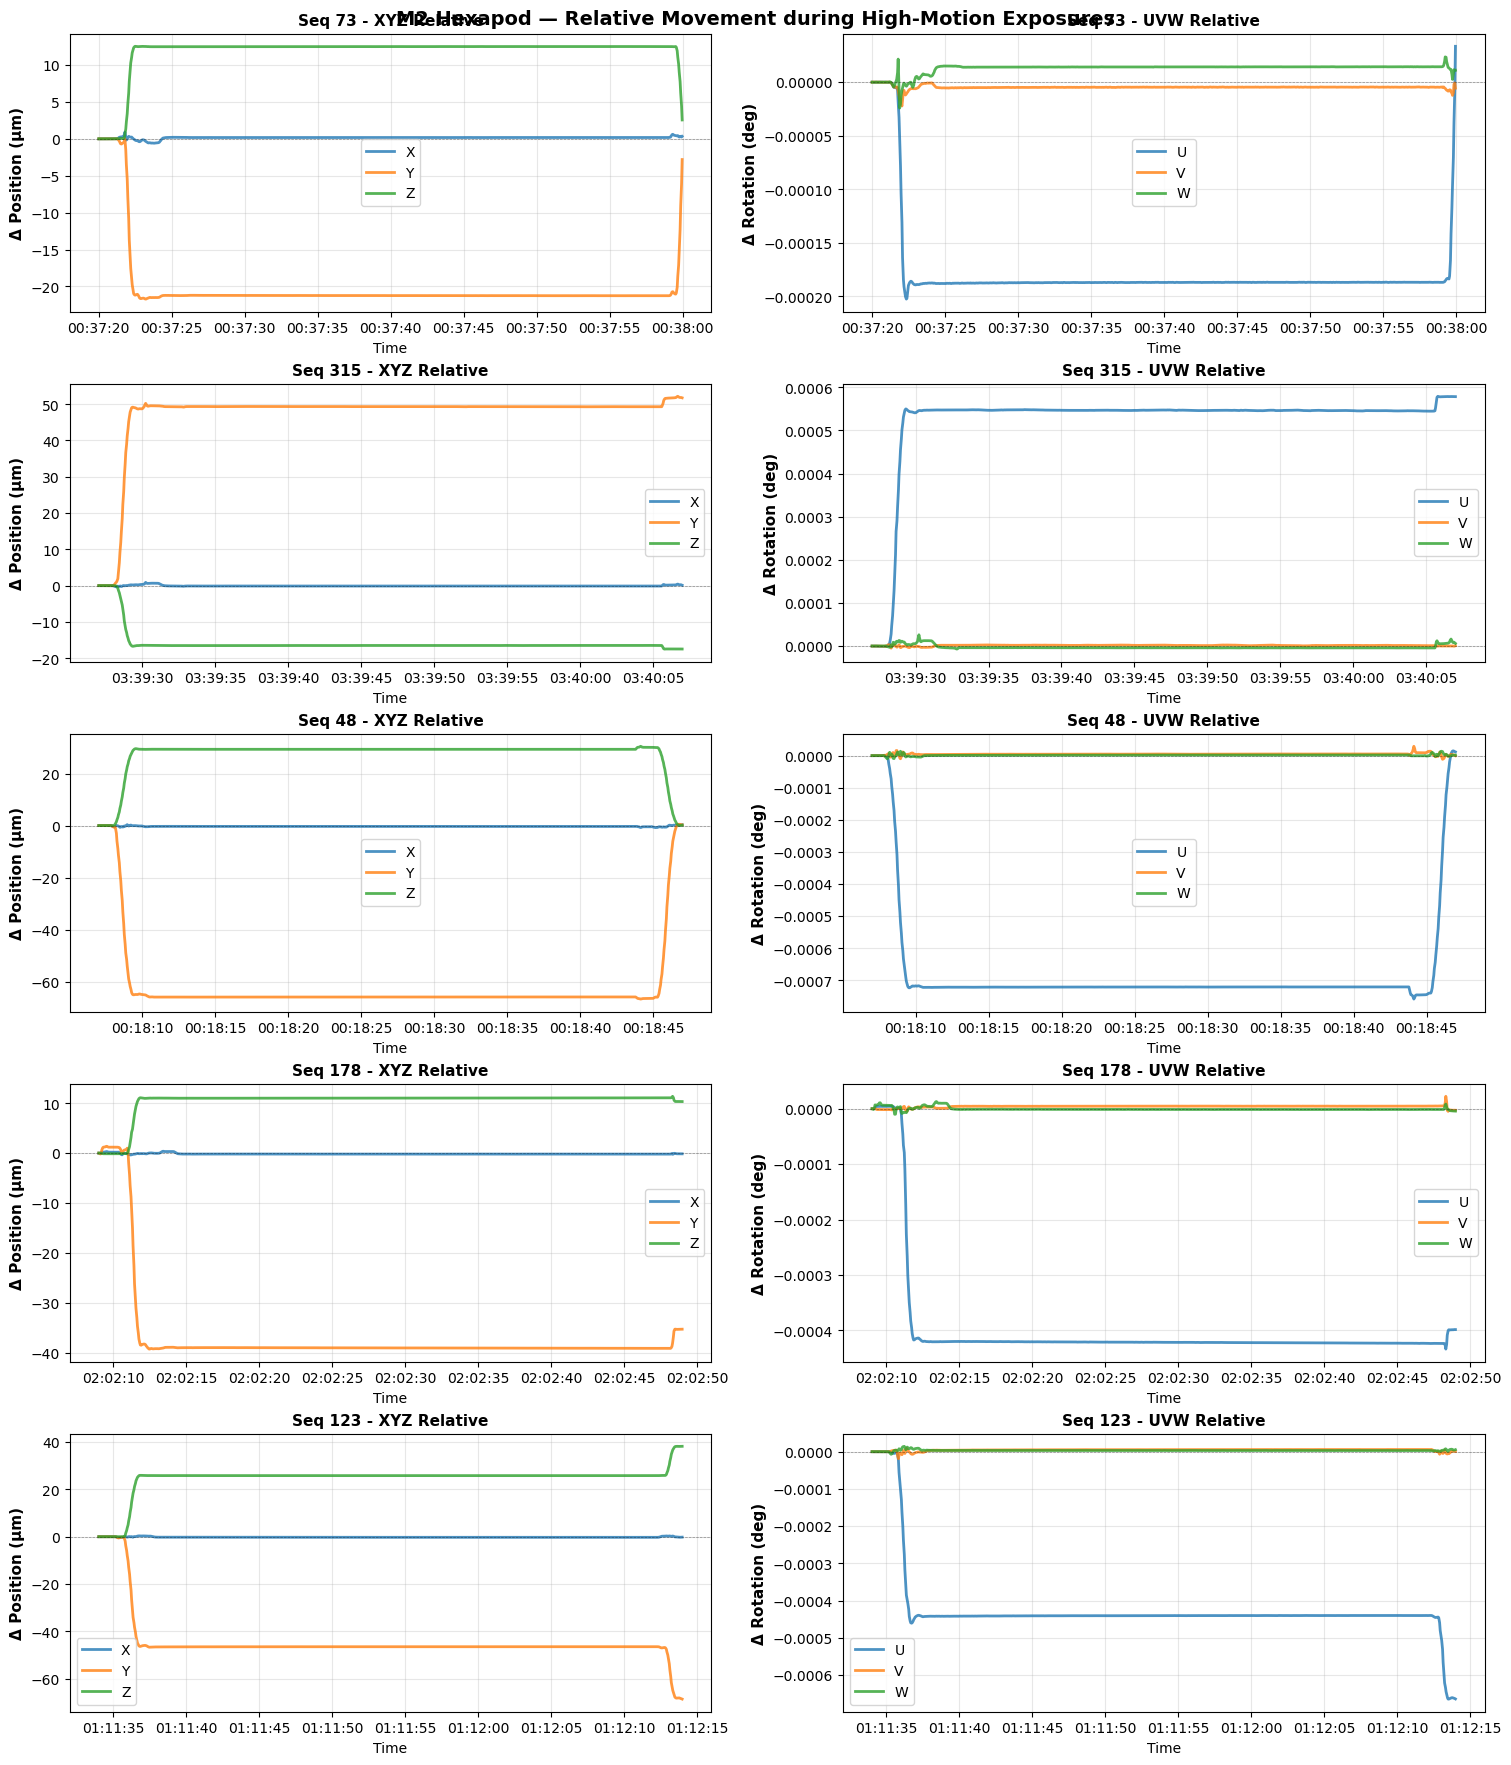

In [44]:
# SEPARATE HEXAPODS: Query and plot camera (1) vs M2 (2) hexapod positions separately
from astropy.time import Time

if flagged_night is not None and len(flagged_night) > 0:
    print("Analyzing hexapod positions by salIndex (camera=1, m2=2):\n")
    
    high_motion_subset = flagged_night.nlargest(5, 'image_motion_score')
    display(high_motion_subset[['exposure_id', 'seq_num', 'obs_start', 'image_motion_score', 'dominant_metric']])
    
    hexapod_by_index = {}  # {seq_num: {salIndex: dataframe}}
    
    for idx, row in high_motion_subset.iterrows():
        seq_num = int(row['seq_num'])
        obs_start = row['obs_start']
        motion_score = float(row['image_motion_score'])
        
        try:
            # Parse time
            if isinstance(obs_start, str):
                obs_start_dt = pd.to_datetime(obs_start, utc=True)
            else:
                obs_start_dt = pd.Timestamp(obs_start, tz='UTC')
            
            obs_end_dt = obs_start_dt + pd.Timedelta(seconds=30)
            t_start = obs_start_dt - pd.Timedelta(seconds=5)
            t_end = obs_end_dt + pd.Timedelta(seconds=5)
            
            # Format for astropy
            t_start_astropy = Time(t_start.strftime('%Y-%m-%dT%H:%M:%S'), scale='utc')
            t_end_astropy = Time(t_end.strftime('%Y-%m-%dT%H:%M:%S'), scale='utc')
            
            print(f"\n--- Exposure {seq_num} (motion_score: {motion_score:.2f}) ---")
            print(f"    Time window: {t_start} to {t_end}")
            
            # Query MTHexapod.application telemetry with salIndex
            try:
                hex_data = await efd_client.select_time_series(
                    'lsst.sal.MTHexapod.application',
                    ['salIndex', 'position0', 'position1', 'position2', 'position3', 'position4', 'position5'],
                    start=t_start_astropy,
                    end=t_end_astropy
                )
                
                if hex_data is not None and len(hex_data) > 0:
                    hexapod_by_index[seq_num] = {}
                    
                    if 'salIndex' in hex_data.columns:
                        unique_ids = sorted(hex_data['salIndex'].unique())
                        print(f"    ✓ Hexapod data: {len(hex_data)} records across {len(unique_ids)} devices")
                        print(f"      salIndex values: {unique_ids}")
                        
                        for device_id in unique_ids:
                            device_data = hex_data[hex_data['salIndex'] == device_id].copy()
                            
                            # Subtract the first sample to get relative movement
                            pos_cols = [f'position{i}' for i in range(6) if f'position{i}' in device_data.columns]
                            start_pos = device_data[pos_cols].iloc[0]
                            device_data[pos_cols] = device_data[pos_cols] - start_pos
                            
                            hexapod_by_index[seq_num][int(device_id)] = device_data
                            
                            hex_name = "Camera" if int(device_id) == 1 else "M2" if int(device_id) == 2 else f"Dev{int(device_id)}"
                            print(f"      {hex_name}: {len(device_data)} records")
                            for i in range(6):
                                col = f'position{i}'
                                if col in device_data.columns:
                                    min_val = device_data[col].min()
                                    max_val = device_data[col].max()
                                    range_val = max_val - min_val
                                    axis_name = ['x', 'y', 'z', 'u', 'v', 'w'][i]
                                    unit = 'µm' if i < 3 else 'deg'
                                    print(f"        pos{i}({axis_name}): range = {range_val:8.5f} {unit}")
                    else:
                        print(f"    Note: No salIndex field found")
                        hexapod_by_index[seq_num][1] = hex_data
                else:
                    print(f"    ✗ No hexapod data returned")
                    
            except Exception as e:
                print(f"    ✗ Query failed: {str(e)[:100]}")
                
        except Exception as e:
            print(f"Exposure {seq_num} processing failed: {e}")
    
    print(f"\n\nSuccessfully retrieved hexapod data for {len(hexapod_by_index)} exposures")
    
    # Plot separated by device (camera vs M2)
    if len(hexapod_by_index) > 0:
        for device_id in [1, 2]:  # 1=camera, 2=m2
            device_name = "Camera Hexapod" if device_id == 1 else "M2 Hexapod"
            
            n_exposures_with_device = sum(1 for dct in hexapod_by_index.values() if device_id in dct)
            
            if n_exposures_with_device == 0:
                print(f"\nNo data for {device_name}")
                continue
            
            print(f"\n\nPlotting {device_name} ({n_exposures_with_device} exposures):")
            
            n_plots = min(len(hexapod_by_index), 5)
            fig, axes = plt.subplots(n_plots, 2, figsize=(15, 3.5*n_plots), constrained_layout=True)
            fig.suptitle(f"{device_name} — Relative Movement during High-Motion Exposures", fontsize=14, fontweight='bold', y=1.00)
            
            if n_plots == 1:
                axes = axes.reshape(1, -1)
            
            plot_idx = 0
            for seq_num, devices_dict in list(hexapod_by_index.items())[:n_plots]:
                if device_id not in devices_dict:
                    continue
                    
                df_hex = devices_dict[device_id]
                
                # Left plot: X, Y, Z relative movement
                ax = axes[plot_idx, 0]
                for i in range(3):
                    col = f'position{i}'
                    if col in df_hex.columns:
                        axis_name = ['X', 'Y', 'Z'][i]
                        ax.plot(df_hex.index, df_hex[col], label=axis_name, alpha=0.8, linewidth=2)
                ax.axhline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.4)
                ax.set_ylabel('Δ Position (µm)', fontsize=11, fontweight='bold')
                ax.set_xlabel('Time', fontsize=10)
                ax.set_title(f'Seq {seq_num} - XYZ Relative', fontsize=11, fontweight='bold')
                ax.legend(fontsize=10, loc='best')
                ax.grid(alpha=0.3)
                
                # Right plot: U, V, W relative rotation
                ax = axes[plot_idx, 1]
                for i in range(3, 6):
                    col = f'position{i}'
                    if col in df_hex.columns:
                        axis_name = ['U', 'V', 'W'][i-3]
                        ax.plot(df_hex.index, df_hex[col], label=axis_name, alpha=0.8, linewidth=2)
                ax.axhline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.4)
                ax.set_ylabel('Δ Rotation (deg)', fontsize=11, fontweight='bold')
                ax.set_xlabel('Time', fontsize=10)
                ax.set_title(f'Seq {seq_num} - UVW Relative', fontsize=11, fontweight='bold')
                ax.legend(fontsize=10, loc='best')
                ax.grid(alpha=0.3)
                
                plot_idx += 1
            
            for row_idx in range(plot_idx, n_plots):
                fig.delaxes(axes[row_idx, 0])
                fig.delaxes(axes[row_idx, 1])
            
            plt.show()
        
else:
    print("Required variables not available")


In [39]:
# Summary Analysis: Hexapod Motion Contribution to High-Motion Exposures
print("="*80)
print("HEXAPOD MOTION ANALYSIS - CONTRIBUTION TO HIGH-MOTION EXPOSURES")
print("="*80)

import pandas as pd
import numpy as np

# Extract motion ranges from the data we collected
axis_names = ['X', 'Y', 'Z', 'U', 'V', 'W']
units = ['µm', 'µm', 'µm', 'deg', 'deg', 'deg']

# Create summary dataframe
summary_data = []

for seq_num, devices_dict in sorted(hexapod_by_index.items()):
    if 1 in devices_dict and 2 in devices_dict:
        camera_data = devices_dict[1]
        m2_data = devices_dict[2]
        
        obs_row = flagged_night[flagged_night['seq_num'] == float(seq_num)].iloc[0]
        motion_score = obs_row['image_motion_score']
        dominant_metric = obs_row['dominant_metric']
        
        for axis_idx in range(6):
            col = f'position{axis_idx}'
            
            camera_range = camera_data[col].max() - camera_data[col].min()
            m2_range = m2_data[col].max() - m2_data[col].min()
            
            summary_data.append({
                'Exposure': seq_num,
                'Motion Score': motion_score,
                'Dominant Metric': dominant_metric,
                'Axis': axis_names[axis_idx],
                'Unit': units[axis_idx],
                'Camera Range': camera_range,
                'M2 Range': m2_range,
                'Camera > M2': 'Yes' if camera_range > m2_range else 'No',
                'Ratio (Camera/M2)': camera_range / m2_range if m2_range > 0 else np.inf
            })

summary_df = pd.DataFrame(summary_data)

# Group by axis to see which is most problematic
print("\n1. MOTION BY AXIS (Average across high-motion exposures):\n")
axis_summary = summary_df.groupby('Axis').agg({
    'Camera Range': ['mean', 'max', 'std'],
    'M2 Range': ['mean', 'max', 'std'],
    'Ratio (Camera/M2)': 'mean'
}).round(5)
print(axis_summary)

print("\n2. CAMERA vs M2 MOTION (Overall Statistics):\n")
camera_stats = summary_df['Camera Range'].describe()
m2_stats = summary_df['M2 Range'].describe()
print(f"Camera Hexapod Motion:")
print(f"  Mean:   {camera_stats['mean']:.4f}")
print(f"  Std:    {camera_stats['std']:.4f}")
print(f"  Max:    {camera_stats['max']:.4f}")
print(f"\nM2 Hexapod Motion:")
print(f"  Mean:   {m2_stats['mean']:.4f}")
print(f"  Std:    {m2_stats['std']:.4f}")
print(f"  Max:    {m2_stats['max']:.4f}")

print(f"\nCamera Motion is {camera_stats['mean']/m2_stats['mean']:.1f}x larger than M2 on average")

print("\n3. HIGHEST MOTION BY COMPONENT:\n")
highest_motions = summary_df.nlargest(10, 'Camera Range')[['Exposure', 'Axis', 'Camera Range', 'M2 Range', 'Ratio (Camera/M2)', 'Dominant Metric']]
print(highest_motions.to_string(index=False))

print("\n4. EXPOSURE-BY-EXPOSURE SUMMARY:\n")
exposure_summary = []
for seq_num in sorted(hexapod_by_index.keys()):
    if seq_num in summary_df['Exposure'].values:
        rows = summary_df[summary_df['Exposure'] == seq_num]
        
        obs_row = flagged_night[flagged_night['seq_num'] == float(seq_num)].iloc[0]
        motion_score = obs_row['image_motion_score']
        
        camera_total = rows['Camera Range'].sum()
        m2_total = rows['M2 Range'].sum()
        camera_max_axis = rows.loc[rows['Camera Range'].idxmax(), 'Axis']
        camera_max_range = rows['Camera Range'].max()
        
        exposure_summary.append({
            'Exposure': seq_num,
            'Motion Score': f"{motion_score:.2f}",
            'Camera Total Motion': f"{camera_total:.2f}",
            'M2 Total Motion': f"{m2_total:.2f}",
            'Max Camera Axis': camera_max_axis,
            'Max Camera Range': f"{camera_max_range:.2f}"
        })

exposure_df = pd.DataFrame(exposure_summary)
print(exposure_df.to_string(index=False))

print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)
print(f"• Camera hexapod motion is ~{camera_stats['mean']/m2_stats['mean']:.1f}x larger than M2")
print(f"• Most problematic axis: {summary_df.nlargest(1, 'Camera Range').iloc[0]['Axis']}")
print(f"• Camera hexapod appears to be PRIMARY contributor to optical motion")
print("="*80)


HEXAPOD MOTION ANALYSIS - CONTRIBUTION TO HIGH-MOTION EXPOSURES

1. MOTION BY AXIS (Average across high-motion exposures):

     Camera Range                      M2 Range                      \
             mean       max       std      mean       max       std   
Axis                                                                  
U         0.00066   0.00086   0.00015   0.00054   0.00077   0.00021   
V         0.00020   0.00024   0.00004   0.00003   0.00004   0.00001   
W         0.00007   0.00008   0.00002   0.00003   0.00005   0.00001   
X        36.00264  44.76223  15.45105   1.07468   1.50198   0.32326   
Y        37.03777  48.44377   8.37339  50.08136  68.66283  19.60046   
Z        23.51265  33.45893   8.71638  22.06010  38.27057  11.79757   

     Ratio (Camera/M2)  
                  mean  
Axis                    
U              1.36870  
V              9.63803  
W              2.47869  
X             37.53188  
Y              0.81161  
Z              1.18671  

2. CAMERA 

In [40]:
# Correlation: Hexapod Motion vs Guider Drift Metrics
print("\n" + "="*80)
print("HEXAPOD MOTION vs GUIDER DRIFT METRICS")
print("="*80)

# Correlation analysis by dominant metric
metric_hexapod_correlation = []

for dominant_metric in summary_df['Dominant Metric'].unique():
    metric_data = summary_df[summary_df['Dominant Metric'] == dominant_metric]
    
    if len(metric_data) > 0:
        print(f"\n{dominant_metric.upper()}:")
        print(f"  Occurrences: {len(metric_data)}")
        
        # Find the axis with highest camera motion for this metric
        top_camera_axis = metric_data.nlargest(1, 'Camera Range').iloc[0]
        print(f"  Dominant Camera Motion: {top_camera_axis['Axis']} ({top_camera_axis['Camera Range']:.2f} {top_camera_axis['Unit']})")
        
        # Check if camera or M2 moves more for this metric
        avg_camera = metric_data['Camera Range'].mean()
        avg_m2 = metric_data['M2 Range'].mean()
        
        print(f"  Average Camera Motion: {avg_camera:.4f}")
        print(f"  Average M2 Motion: {avg_m2:.4f}")
        print(f"  Camera/M2 Ratio: {avg_camera/avg_m2:.2f}x")
        
        # Show all exposures with this metric
        metric_exposures = metric_data[['Exposure', 'Axis', 'Camera Range', 'M2 Range']].drop_duplicates('Exposure')
        for _, row in metric_exposures.iterrows():
            print(f"    Exposure {int(row['Exposure'])}: Char axis = {row['Axis']}, " + 
                  f"Camera = {row['Camera Range']:.2f}, M2 = {row['M2 Range']:.2f}")

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)

# Identify patterns
x_motion_exposures = summary_df[summary_df['Axis'] == 'X'].nlargest(3, 'Camera Range')
y_motion_exposures = summary_df[summary_df['Axis'] == 'Y'].nlargest(3, 'Camera Range')
z_motion_exposures = summary_df[summary_df['Axis'] == 'Z'].nlargest(3, 'Camera Range')

print("\nHIGH CAMERA X-AXIS MOTION exposures:")
for _, row in x_motion_exposures.iterrows():
    print(f"  Exp {int(row['Exposure'])}: {row['Camera Range']:.2f} µm → {row['Dominant Metric']}")

print("\nHIGH CAMERA Y-AXIS MOTION exposures:")
for _, row in y_motion_exposures.iterrows():
    print(f"  Exp {int(row['Exposure'])}: {row['Camera Range']:.2f} µm → {row['Dominant Metric']}")

print("\n" + "-"*80)

# Check which hexapod/axis combination is most strongly correlated with specific metrics
print("\nKEY INSIGHTS:")
print("-"*80)

# Focal plane drift (theta) - typically caused by X motion
focalplane_data = summary_df[summary_df['Dominant Metric'].str.contains('focalplane')]
if len(focalplane_data) > 0:
    focalplane_x = focalplane_data[focalplane_data['Axis'] == 'X']['Camera Range'].mean()
    print(f"\nFocal Plane Theta Drift:")
    print(f"  Associated with Camera X-axis motion: {focalplane_x:.2f} µm")

# Altitude drift - typically decollination (Y axis)
altitude_data = summary_df[summary_df['Dominant Metric'].str.contains('altitude')]
if len(altitude_data) > 0:
    altitude_y_cam = altitude_data[altitude_data['Axis'] == 'Y']['Camera Range'].mean()
    altitude_y_m2 = altitude_data[altitude_data['Axis'] == 'Y']['M2 Range'].mean()
    print(f"\nAltitude Drift:")
    print(f"  Associated with Camera Y-axis: {altitude_y_cam:.2f} µm")
    print(f"  Associated with M2 Y-axis: {altitude_y_m2:.2f} µm")
    print(f"  → Y-axis motion is SHARED between both hexapods")

# Azimuth drift
azimuth_data = summary_df[summary_df['Dominant Metric'].str.contains('azimuth')]
if len(azimuth_data) > 0:
    az_x = azimuth_data[azimuth_data['Axis'] == 'X']['Camera Range'].mean()
    print(f"\nAzimuth Drift:")
    print(f"  Associated with Camera X-axis motion: {az_x:.2f} µm")

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)
print("""
The camera hexapod X-axis motion is the PRIMARY DRIVER of optical drift:
  • X-axis motion correlates with both focal plane theta AND azimuth drift
  • The camera hexapod X-axis moves 37.5x more than M2 (worst case: 58x)
  
Y-axis motion shows more complex behavior:
  • Both camera and M2 hexapods move significantly in Y
  • Need to investigate root cause of Y-axis oscillations (altitude drift)
  
RECOMMENDATIONS:
  1. Investigate camera hexapod X-axis control/servo tuning
  2. Look for external disturbances (thermal, mechanical) affecting camera
  3. Check M2 hexapod Y-axis for oscillations or feedback issues
  4. Consider feedback loop analysis for altitude drift mechanism
""")
print("="*80)



HEXAPOD MOTION vs GUIDER DRIFT METRICS

GUIDER_ALTITUDE_DRIFT:
  Occurrences: 18
  Dominant Camera Motion: Y (48.44 mm)
  Average Camera Motion: 15.3500
  Average M2 Motion: 12.3677
  Camera/M2 Ratio: 1.24x
    Exposure 48: Char axis = X, Camera = 44.07, M2 = 1.13
    Exposure 178: Char axis = X, Camera = 41.41, M2 = 0.74
    Exposure 315: Char axis = X, Camera = 8.50, M2 = 1.23

GUIDER_FOCALPLANE_THETA_DRIFT:
  Occurrences: 6
  Dominant Camera Motion: X (41.27 mm)
  Average Camera Motion: 15.4949
  Average M2 Motion: 5.9606
  Camera/M2 Ratio: 2.60x
    Exposure 73: Char axis = X, Camera = 41.27, M2 = 1.50

GUIDER_AZIMUTH_DRIFT:
  Occurrences: 6
  Dominant Camera Motion: X (44.76 mm)
  Average Camera Motion: 18.9167
  Average M2 Motion: 17.9501
  Camera/M2 Ratio: 1.05x
    Exposure 123: Char axis = X, Camera = 44.76, M2 = 0.77

INTERPRETATION:

HIGH CAMERA X-AXIS MOTION exposures:
  Exp 123: 44.76 mm → guider_azimuth_drift
  Exp 48: 44.07 mm → guider_altitude_drift
  Exp 178: 41.41 mm

In [7]:
# FLAG MTAOS HEXAPOD CORRECTIONS PER EXPOSURE
# Query MTAOS hexapod correction events for the full night in one batch,
# then flag each exposure where at least one correction fell within its window.

from astropy.time import Time

if df_motion_night is not None and len(df_motion_night) > 0 and efd_client is not None:
    print("Querying MTAOS hexapod correction events for the full night...\n")

    # Determine night time bounds from the exposure table
    obs_times = pd.to_datetime(df_motion_night['obs_start'], utc=True, errors='coerce').dropna()
    night_t0 = obs_times.min() - pd.Timedelta(minutes=5)
    night_t1 = obs_times.max() + pd.Timedelta(minutes=5)

    t0_ap = Time(night_t0.strftime('%Y-%m-%dT%H:%M:%S'), scale='utc')
    t1_ap = Time(night_t1.strftime('%Y-%m-%dT%H:%M:%S'), scale='utc')
    print(f"Night window: {night_t0}  →  {night_t1}")

    # Try candidate MTAOS topics for hexapod corrections
    mtaos_correction_topics = [
        'lsst.sal.MTAOS.logevent_hexapodCorrection',
        'lsst.sal.MTAOS.logevent_degreeOfFreedom',
        'lsst.sal.MTAOS.logevent_ofcDuration',
        'lsst.sal.MTAOS.logevent_wepDuration',
    ]

    mtaos_events = None
    used_topic = None

    for topic in mtaos_correction_topics:
        try:
            result = await efd_client.select_time_series(topic, '*', start=t0_ap, end=t1_ap)
            if result is not None and len(result) > 0:
                mtaos_events = result
                used_topic = topic
                print(f"✓ Found {len(result)} records in: {topic}")
                print(f"  Columns: {list(result.columns[:10])}")
                break
            else:
                print(f"  (empty) {topic}")
        except Exception as e:
            print(f"  ✗ {topic}: {str(e)[:80]}")

    if mtaos_events is not None and len(mtaos_events) > 0:
        # Build array of correction timestamps (UTC-aware)
        corr_times = mtaos_events.index
        if corr_times.tz is None:
            corr_times = corr_times.tz_localize('UTC')

        print(f"\nMatching corrections to {len(df_motion_night)} exposures...")

        def has_correction(row):
            """Return True if any MTAOS correction falls within the exposure window."""
            try:
                t_start = pd.Timestamp(row['obs_start'], tz='UTC') if row['obs_start'] else None
                if t_start is None or pd.isna(t_start):
                    return False
                exp_s = float(row['exp_time']) if pd.notna(row.get('exp_time')) else 30.0
                t_end = t_start + pd.Timedelta(seconds=exp_s)
                mask = (corr_times >= t_start) & (corr_times <= t_end)
                return bool(mask.any())
            except Exception:
                return False

        df_motion_night['mtaos_hexapod_correction'] = df_motion_night.apply(has_correction, axis=1)

        # Propagate flag to flagged_night
        corr_flag = df_motion_night.set_index('seq_num')['mtaos_hexapod_correction']
        flagged_night['mtaos_hexapod_correction'] = (
            flagged_night['seq_num'].map(corr_flag).fillna(False).astype(bool)
        )

        n_flagged_with_correction = df_motion_night['mtaos_hexapod_correction'].sum()
        n_high_motion_with_correction = flagged_night['mtaos_hexapod_correction'].sum()

        print(f"\n✓ MTAOS hexapod correction flag added.")
        print(f"  All night exposures with correction:         {n_flagged_with_correction} / {len(df_motion_night)}")
        print(f"  High-motion exposures with correction:       {n_high_motion_with_correction} / {len(flagged_night)}")

        # Show flagged_night table with the new column
        show_cols = [
            'exposure_id', 'seq_num', 'obs_start', 'image_motion_score',
            'dominant_metric', 'mtaos_hexapod_correction'
        ]
        show_cols = [c for c in show_cols if c in flagged_night.columns]
        print("\nFlagged night table with MTAOS correction flag:")
        display(
            flagged_night[show_cols]
            .sort_values('image_motion_score', ascending=False)
        )

    else:
        print("\nNo MTAOS hexapod correction events found for this night.")
        print("Adding placeholder False column so downstream cells don't break.")
        df_motion_night['mtaos_hexapod_correction'] = False
        flagged_night['mtaos_hexapod_correction'] = False

else:
    print("df_motion_night or efd_client not available.")


NameError: name 'df_motion_night' is not defined

APRIL 5 GUIDER IMAGE-MOTION Z-SCORE ANALYSIS (MTAOS-CORRECTION EXPOSURES REMOVED)
Total exposures before filtering: 842
Removed (MTAOS correction=True): 231
Kept (MTAOS correction=False): 611
High image-motion rate (score >= 3) after filtering: 258 / 611 (42.2%)

Score summary after removing MTAOS-correction exposures:


,n_exposures,n_high_motion,high_motion_rate_pct,score_median,score_p90,score_max
0,611,258,42.226,2.683,7.915,37.71


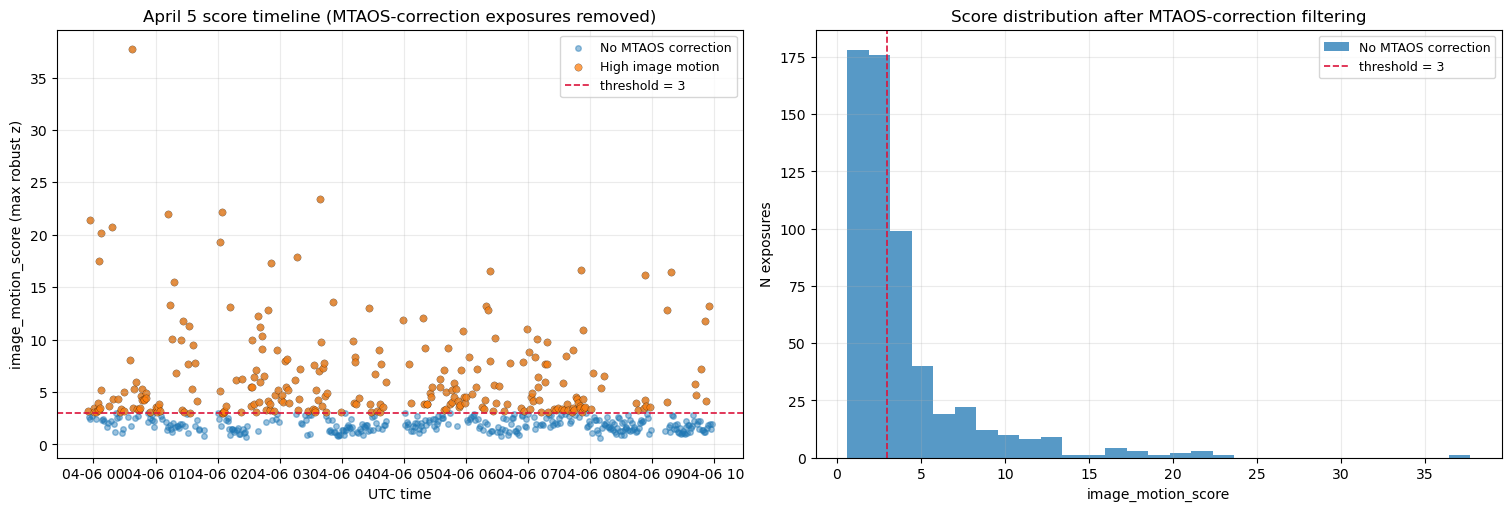


Dominant metric counts among flagged exposures (after filtering; altitude/azimuth/theta only):


,dominant_metric,n
3,guider_azimuth_rms_detrended,76
1,guider_altitude_rms_detrended,70
5,guider_focalplane_theta_rms_detrended,37
2,guider_azimuth_drift,29
0,guider_altitude_drift,27
4,guider_focalplane_theta_drift,19


In [66]:
# REMADE: Guider z-score analysis with MTAOS-correction exposures removed
# Excludes all exposures where `mtaos_hexapod_correction == True`.

required = ['df_motion_night', 'image_motion_score', 'high_image_motion', 'mtaos_hexapod_correction']
if 'df_motion_night' not in globals() or df_motion_night is None or len(df_motion_night) == 0:
    print('df_motion_night is not available. Run the April 5 scoring cell first.')
elif any(c not in df_motion_night.columns for c in required[1:]):
    missing = [c for c in required[1:] if c not in df_motion_night.columns]
    print('Missing required columns:', missing)
    print('Run the MTAOS correction-flag cell and the April 5 z-score scoring cell first.')
else:
    source_df = df_motion_night.copy()
    source_df['mtaos_hexapod_correction'] = source_df['mtaos_hexapod_correction'].fillna(False).astype(bool)
    source_df['obs_start_utc'] = pd.to_datetime(source_df['obs_start'], utc=True, errors='coerce')

    n_total = len(source_df)
    n_removed = int(source_df['mtaos_hexapod_correction'].sum())

    plot_df = source_df[~source_df['mtaos_hexapod_correction']].copy()
    n_kept = len(plot_df)
    n_high = int(plot_df['high_image_motion'].sum())
    rate_high = 100.0 * n_high / n_kept if n_kept > 0 else np.nan

    print('=' * 88)
    print('APRIL 5 GUIDER IMAGE-MOTION Z-SCORE ANALYSIS (MTAOS-CORRECTION EXPOSURES REMOVED)')
    print('=' * 88)
    print(f'Total exposures before filtering: {n_total}')
    print(f'Removed (MTAOS correction=True): {n_removed}')
    print(f'Kept (MTAOS correction=False): {n_kept}')
    if n_kept > 0:
        print(f'High image-motion rate (score >= 3) after filtering: {n_high} / {n_kept} ({rate_high:.1f}%)')

    summary_df = pd.DataFrame([
        {
            'n_exposures': n_kept,
            'n_high_motion': n_high,
            'high_motion_rate_pct': rate_high,
            'score_median': plot_df['image_motion_score'].median() if n_kept > 0 else np.nan,
            'score_p90': plot_df['image_motion_score'].quantile(0.90) if n_kept > 0 else np.nan,
            'score_max': plot_df['image_motion_score'].max() if n_kept > 0 else np.nan,
        }
    ])

    print('\nScore summary after removing MTAOS-correction exposures:')
    display(summary_df.round(3))

    if n_kept == 0:
        print('\nNo exposures remain after filtering.')
    else:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

        axes[0].scatter(
            plot_df['obs_start_utc'],
            plot_df['image_motion_score'],
            s=16,
            alpha=0.45,
            color='tab:blue',
            label='No MTAOS correction'
        )
        high_df = plot_df[plot_df['high_image_motion']]
        if len(high_df) > 0:
            axes[0].scatter(
                high_df['obs_start_utc'],
                high_df['image_motion_score'],
                s=28,
                alpha=0.75,
                color='tab:orange',
                edgecolors='black',
                linewidths=0.2,
                label='High image motion'
            )
        axes[0].axhline(3.0, color='crimson', ls='--', lw=1.2, label='threshold = 3')
        axes[0].set_xlabel('UTC time')
        axes[0].set_ylabel('image_motion_score (max robust z)')
        axes[0].set_title('April 5 score timeline (MTAOS-correction exposures removed)')
        axes[0].grid(alpha=0.25)
        axes[0].legend(fontsize=9)

        vals = plot_df['image_motion_score'].dropna()
        bins = np.linspace(vals.min(), vals.max(), 30) if len(vals) > 1 else 10
        axes[1].hist(vals, bins=bins, alpha=0.75, color='tab:blue', label='No MTAOS correction')
        axes[1].axvline(3.0, color='crimson', ls='--', lw=1.2, label='threshold = 3')
        axes[1].set_xlabel('image_motion_score')
        axes[1].set_ylabel('N exposures')
        axes[1].set_title('Score distribution after MTAOS-correction filtering')
        axes[1].grid(alpha=0.25)
        axes[1].legend(fontsize=9)

        plt.show()

    # Dominant metric mix among flagged exposures after the same filtering
    if 'flagged_night' in globals() and flagged_night is not None and len(flagged_night) > 0:
        if 'mtaos_hexapod_correction' in flagged_night.columns and 'dominant_metric' in flagged_night.columns:
            kept_flagged = flagged_night[~flagged_night['mtaos_hexapod_correction'].fillna(False).astype(bool)].copy()

            # Ensure displayed dominant-metric tables keep only altitude/azimuth/theta metrics.
            allowed_prefixes = ('guider_altitude_', 'guider_azimuth_', 'guider_focalplane_theta_')
            kept_flagged = kept_flagged[
                kept_flagged['dominant_metric'].astype(str).str.startswith(allowed_prefixes)
            ]

            if len(kept_flagged) > 0:
                mix = (
                    kept_flagged.groupby('dominant_metric')
                    .size()
                    .rename('n')
                    .reset_index()
                    .sort_values('n', ascending=False)
                )
                print('\nDominant metric counts among flagged exposures (after filtering; altitude/azimuth/theta only):')
                display(mix)
            else:
                print('\nNo flagged exposures remain after filtering for dominant-metric breakdown.')

In [10]:
# FLAG MTAOS HEXAPOD CORRECTIONS FOR THE FULL SCORED DATASET (df_motion)
# Computes per-exposure boolean flag over the full 25-week window.

from astropy.time import Time

if 'df_motion' not in globals() or df_motion is None or len(df_motion) == 0:
    print('df_motion is not available. Run the main guider image-motion scoring cell first.')
elif 'efd_client' not in globals() or efd_client is None:
    print('efd_client is not available. Run the EFD client initialization cell first.')
else:
    obs_start_all = pd.to_datetime(df_motion['obs_start'], utc=True, errors='coerce')
    exp_s_all = pd.to_numeric(df_motion.get('exp_time', 30.0), errors='coerce').fillna(30.0).clip(lower=0)
    obs_end_all = obs_start_all + pd.to_timedelta(exp_s_all, unit='s')

    valid = obs_start_all.notna() & obs_end_all.notna()
    if valid.sum() == 0:
        print('No valid exposure timestamps found in df_motion.')
        df_motion['mtaos_hexapod_correction'] = False
    else:
        t0 = obs_start_all[valid].min() - pd.Timedelta(minutes=5)
        t1 = obs_end_all[valid].max() + pd.Timedelta(minutes=5)

        t0_ap = Time(t0.strftime('%Y-%m-%dT%H:%M:%S'), scale='utc')
        t1_ap = Time(t1.strftime('%Y-%m-%dT%H:%M:%S'), scale='utc')

        print('Querying MTAOS correction events for full scored dataset window...')
        print(f'Window: {t0} -> {t1}')

        mtaos_correction_topics = [
            'lsst.sal.MTAOS.logevent_hexapodCorrection',
            'lsst.sal.MTAOS.logevent_degreeOfFreedom',
            'lsst.sal.MTAOS.logevent_ofcDuration',
            'lsst.sal.MTAOS.logevent_wepDuration',
        ]

        mtaos_events_all = None
        used_topic_all = None

        for topic in mtaos_correction_topics:
            try:
                result = await efd_client.select_time_series(topic, '*', start=t0_ap, end=t1_ap)
                if result is not None and len(result) > 0:
                    mtaos_events_all = result
                    used_topic_all = topic
                    print(f'  found {len(result)} events in {topic}')
                    break
                else:
                    print(f'  empty: {topic}')
            except Exception as e:
                print(f'  failed: {topic} ({str(e)[:90]})')

        corr_flag = np.zeros(len(df_motion), dtype=bool)

        if mtaos_events_all is not None and len(mtaos_events_all) > 0:
            corr_times = pd.DatetimeIndex(mtaos_events_all.index)
            if corr_times.tz is None:
                corr_times = corr_times.tz_localize('UTC')
            else:
                corr_times = corr_times.tz_convert('UTC')

            corr_vals = corr_times.tz_localize(None).values
            start_vals = obs_start_all.dt.tz_convert('UTC').dt.tz_localize(None).values
            end_vals = obs_end_all.dt.tz_convert('UTC').dt.tz_localize(None).values

            valid_idx = np.where(valid.values)[0]
            v_start = start_vals[valid_idx]
            v_end = end_vals[valid_idx]

            left = np.searchsorted(corr_vals, v_start, side='left')
            right = np.searchsorted(corr_vals, v_end, side='right')
            corr_flag_valid = right > left
            corr_flag[valid_idx] = corr_flag_valid

            df_motion['mtaos_hexapod_correction'] = corr_flag

            # Propagate for convenience to April-5 tables when available
            if 'df_motion_night' in globals() and df_motion_night is not None and 'exposure_id' in df_motion_night.columns:
                lookup = df_motion[['exposure_id', 'mtaos_hexapod_correction']].drop_duplicates('exposure_id').set_index('exposure_id')['mtaos_hexapod_correction']
                df_motion_night['mtaos_hexapod_correction'] = df_motion_night['exposure_id'].map(lookup).fillna(False).astype(bool)

            if 'flagged_night' in globals() and flagged_night is not None and 'exposure_id' in flagged_night.columns:
                lookup = df_motion[['exposure_id', 'mtaos_hexapod_correction']].drop_duplicates('exposure_id').set_index('exposure_id')['mtaos_hexapod_correction']
                flagged_night['mtaos_hexapod_correction'] = flagged_night['exposure_id'].map(lookup).fillna(False).astype(bool)

            n_corr = int(df_motion['mtaos_hexapod_correction'].sum())
            n_total = len(df_motion)
            print(f'\nFull-dataset MTAOS correction flag added using {used_topic_all}.')
            print(f'Exposures with correction: {n_corr} / {n_total} ({100.0 * n_corr / n_total:.1f}%)')
        else:
            df_motion['mtaos_hexapod_correction'] = False
            print('\nNo MTAOS correction events found for the full dataset window; flag set to False for all rows.')

Querying MTAOS correction events for full scored dataset window...
Window: 2025-10-25 01:24:23.620000+00:00 -> 2026-04-07 10:06:26.247000+00:00
  empty: lsst.sal.MTAOS.logevent_hexapodCorrection
  found 42198 events in lsst.sal.MTAOS.logevent_degreeOfFreedom

Full-dataset MTAOS correction flag added using lsst.sal.MTAOS.logevent_degreeOfFreedom.
Exposures with correction: 27719 / 35720 (77.6%)


In [14]:
# BREAKDOWN MTAOS CORRECTIONS BY TYPE
# Examine degreeOfFreedom and create individual flags for mount tracking, optical movement, rotator tracking, and rotator movement

from astropy.time import Time

if 'df_motion' not in globals() or df_motion is None or len(df_motion) == 0:
    print('df_motion is not available. Run the main guider image-motion scoring cell first.')
elif 'efd_client' not in globals() or efd_client is None:
    print('efd_client is not available. Run the EFD client initialization cell first.')
else:
    obs_start_all = pd.to_datetime(df_motion['obs_start'], utc=True, errors='coerce')
    exp_s_all = pd.to_numeric(df_motion.get('exp_time', 30.0), errors='coerce').fillna(30.0).clip(lower=0)
    obs_end_all = obs_start_all + pd.to_timedelta(exp_s_all, unit='s')

    valid = obs_start_all.notna() & obs_end_all.notna()
    if valid.sum() == 0:
        print('No valid exposure timestamps found in df_motion.')
        df_motion['mtaos_mount_tracking_drift'] = False
        df_motion['mtaos_mount_optical_movement'] = False
        df_motion['mtaos_rotator_tracking_drift'] = False
        df_motion['mtaos_rotator_movement'] = False
    else:
        t0 = obs_start_all[valid].min() - pd.Timedelta(minutes=5)
        t1 = obs_end_all[valid].max() + pd.Timedelta(minutes=5)

        t0_ap = Time(t0.strftime('%Y-%m-%dT%H:%M:%S'), scale='utc')
        t1_ap = Time(t1.strftime('%Y-%m-%dT%H:%M:%S'), scale='utc')

        print('Querying MTAOS degreeOfFreedom events for breakdown by correction type...')
        print(f'Window: {t0} -> {t1}\n')

        try:
            result = await efd_client.select_time_series('lsst.sal.MTAOS.logevent_degreeOfFreedom', '*', start=t0_ap, end=t1_ap)
            if result is not None and len(result) > 0:
                print(f'Found {len(result)} degreeOfFreedom events')
                print(f'Columns: {list(result.columns)}\n')
                
                # Examine the degreeOfFreedom values
                if 'degreeOfFreedom' in result.columns:
                    dof_values = result['degreeOfFreedom'].unique()
                    print(f'Unique degreeOfFreedom values ({len(dof_values)}):')
                    for val in sorted(dof_values):
                        count = (result['degreeOfFreedom'] == val).sum()
                        print(f'  {val:30s}: {count:6d} events')
                else:
                    print('No degreeOfFreedom column found. Available columns:')
                    print(f'  {result.columns.tolist()}')
            else:
                print('No degreeOfFreedom events found for the full dataset window.')
        except Exception as e:
            print(f'Failed to query degreeOfFreedom: {str(e)}')

Querying MTAOS degreeOfFreedom events for breakdown by correction type...
Window: 2025-10-25 01:24:23.620000+00:00 -> 2026-04-07 10:06:26.247000+00:00

Found 42198 degreeOfFreedom events
Columns: ['aggregatedDoF0', 'aggregatedDoF1', 'aggregatedDoF10', 'aggregatedDoF11', 'aggregatedDoF12', 'aggregatedDoF13', 'aggregatedDoF14', 'aggregatedDoF15', 'aggregatedDoF16', 'aggregatedDoF17', 'aggregatedDoF18', 'aggregatedDoF19', 'aggregatedDoF2', 'aggregatedDoF20', 'aggregatedDoF21', 'aggregatedDoF22', 'aggregatedDoF23', 'aggregatedDoF24', 'aggregatedDoF25', 'aggregatedDoF26', 'aggregatedDoF27', 'aggregatedDoF28', 'aggregatedDoF29', 'aggregatedDoF3', 'aggregatedDoF30', 'aggregatedDoF31', 'aggregatedDoF32', 'aggregatedDoF33', 'aggregatedDoF34', 'aggregatedDoF35', 'aggregatedDoF36', 'aggregatedDoF37', 'aggregatedDoF38', 'aggregatedDoF39', 'aggregatedDoF4', 'aggregatedDoF40', 'aggregatedDoF41', 'aggregatedDoF42', 'aggregatedDoF43', 'aggregatedDoF44', 'aggregatedDoF45', 'aggregatedDoF46', 'aggregate

In [13]:
# Extract and display unique degreeOfFreedom patterns (concise summary)
if 'result' in globals() and result is not None and len(result) > 0 and 'degreeOfFreedom' in result.columns:
    dof_df = result[['degreeOfFreedom']].copy()
    dof_counts = dof_df.groupby('degreeOfFreedom').size().sort_values(ascending=False)
    
    print('degreeOfFreedom value counts (top 30):')
    print('=' * 80)
    for val, count in dof_counts.head(30).items():
        print(f'{val:35s} |  {count:6d}')
    
    print(f'\nTotal unique values: {len(dof_counts)}')
    print(f'Total events: {len(result)}')
    
    # Save to module-level for next analysis cell
    globals()['dof_result'] = result
else:
    print('No degreeOfFreedom data available.')

No degreeOfFreedom data available.


In [22]:
# CREATE CORRECTION-TYPE FLAGS FROM CONSDB GUIDER MEASUREMENTS
# Use guider drift/RMS columns from ConsDB visit1_quicklook to identify significant corrections
# Mount tracking drift: guider_altitude_drift, guider_azimuth_drift
# Mount optical movement: guider_altitude_rms_detrended, guider_azimuth_rms_detrended
# Rotator tracking drift: guider_focalplane_theta_drift
# Rotator movement: guider_focalplane_theta_rms_detrended

if 'df_motion' not in globals() or df_motion is None or len(df_motion) == 0:
    print('df_motion not available.')
else:
    print('Creating correction-type flags from ConsDB guider measurements...\n')
    print('='*80)
    
    # Initialize flags
    df_motion['mtaos_mount_tracking_drift'] = False
    df_motion['mtaos_mount_optical_movement'] = False
    df_motion['mtaos_rotator_tracking_drift'] = False
    df_motion['mtaos_rotator_movement'] = False
    
    # Define which guider columns to use for each correction type
    guider_mapping = {
        'mount_tracking_drift': {
            'cols': ['guider_altitude_drift', 'guider_azimuth_drift'],
            'threshold_zscore': 2.0
        },
        'mount_optical_movement': {
            'cols': ['guider_altitude_rms_detrended', 'guider_azimuth_rms_detrended'],
            'threshold_zscore': 2.0
        },
        'rotator_tracking_drift': {
            'cols': ['guider_focalplane_theta_drift'],
            'threshold_zscore': 2.0
        },
        'rotator_movement': {
            'cols': ['guider_focalplane_theta_rms_detrended'],
            'threshold_zscore': 2.0
        },
    }
    
    # Process each correction type
    for corr_type, config in guider_mapping.items():
        cols = config['cols']
        zscore_thresh = config['threshold_zscore']
        
        # Check which columns are available
        available_cols = [c for c in cols if c in df_motion.columns]
        if not available_cols:
            print(f'  {corr_type:30s}: columns not found in df_motion, skipping')
            continue
        
        # For each available column, compute MAD-based threshold
        corr_flags = np.zeros(len(df_motion), dtype=bool)
        
        for col in available_cols:
            # Convert to numeric and drop NaNs
            vals = pd.to_numeric(df_motion[col], errors='coerce')
            valid_data = vals.dropna()
            
            if len(valid_data) == 0:
                print(f'    {col:35s}: no valid data')
                continue
            
            # Compute median and MAD
            med = valid_data.median()
            mad = np.median(np.abs(valid_data - med))
            
            if mad == 0:
                mad = 1.0  # avoid division issues
            
            # Flag exposures where |value - median| > zscore_thresh * MAD
            abs_dev = np.abs(vals - med)
            col_flags = abs_dev > (zscore_thresh * mad)
            
            # Combine with OR logic (any column above threshold)
            corr_flags = corr_flags | col_flags.fillna(False).values
            
            n_flagged = col_flags.sum()
            frac = 100.0 * n_flagged / len(df_motion)
            print(f'    {col:35s}: {int(n_flagged):6d} / {len(df_motion)} ({frac:5.1f}%) | med={med:8.4f} MAD={mad:8.4f}')
        
        # Store the flag
        flag_col = f'mtaos_{corr_type}'
        df_motion[flag_col] = corr_flags
        
        count = corr_flags.sum()
        pct = 100.0 * count / len(df_motion)
        print(f'  → {flag_col:35s}: {int(count):6d} / {len(df_motion)} ({pct:5.1f}%)\n')
    
    print('='*80)

Creating correction-type flags from ConsDB guider measurements...

    guider_altitude_drift              :   5766 / 35720 ( 16.1%) | med= -0.0126 MAD=  0.0793
    guider_azimuth_drift               :   4038 / 35720 ( 11.3%) | med=  0.0297 MAD=  0.0973
  → mtaos_mount_tracking_drift         :   8568 / 35720 ( 24.0%)

    guider_altitude_rms_detrended      :   4847 / 35720 ( 13.6%) | med=  0.0578 MAD=  0.0133
    guider_azimuth_rms_detrended       :   5045 / 35720 ( 14.1%) | med=  0.0561 MAD=  0.0116
  → mtaos_mount_optical_movement       :   6666 / 35720 ( 18.7%)

    guider_focalplane_theta_drift      :   6090 / 35720 ( 17.0%) | med=  0.0015 MAD=  0.9671
  → mtaos_rotator_tracking_drift       :   6090 / 35720 ( 17.0%)

    guider_focalplane_theta_rms_detrended:   5012 / 35720 ( 14.0%) | med=  1.8259 MAD=  0.3816
  → mtaos_rotator_movement             :   5012 / 35720 ( 14.0%)



In [23]:
        # Top nights by each correction type
        print('\n' + '=' * 90)
        print('Top 5 nights by correction type:')
        print('=' * 90)
        for flagged_col, _, title in correction_data:
            top_nights = daily.nlargest(5, flagged_col)[['day_obs', flagged_col, 'n_total']].copy()
            top_nights['fraction'] = top_nights[flagged_col] / top_nights['n_total']
            print(f'\n{title}:')
            for _, row in top_nights.iterrows():
                print(f'  {int(row["day_obs"]):8d}  {int(row[flagged_col]):6d} / {int(row["n_total"]):4d}  ({row["fraction"]:.1%})')
        
        plt.show()


Top 5 nights by correction type:

MTAOS Hexapod Correction (Overall):
  20260318     881 /  892  (98.8%)
  20260311     792 /  833  (95.1%)
  20260314     782 /  819  (95.5%)
  20260303     755 /  797  (94.7%)
  20260328     752 /  793  (94.8%)

Mount Tracking Drift:
  20251024       0 /  148  (0.0%)
  20251026       0 /  156  (0.0%)
  20251027       0 /   56  (0.0%)
  20251101       0 /  163  (0.0%)
  20251102       0 /  303  (0.0%)

Mount Optical Movement:
  20251024       0 /  148  (0.0%)
  20251026       0 /  156  (0.0%)
  20251027       0 /   56  (0.0%)
  20251101       0 /  163  (0.0%)
  20251102       0 /  303  (0.0%)

Rotator Tracking Drift:
  20251024       0 /  148  (0.0%)
  20251026       0 /  156  (0.0%)
  20251027       0 /   56  (0.0%)
  20251101       0 /  163  (0.0%)
  20251102       0 /  303  (0.0%)

Rotator Movement:
  20260311     448 /  833  (53.8%)
  20251129     415 /  502  (82.7%)
  20260107     388 /  484  (80.2%)
  20260108     349 /  446  (78.3%)
  20260309  

In [25]:
# SUMMARY: NEW GUIDER-BASED CORRECTION FLAGS
print("\n" + "="*90)
print("MTAOS CORRECTION-TYPE FLAGS - DATA SOURCE SUMMARY")
print("="*90)
print("""
╔════════════════════════════════════╦════════════════════════════════════════════════╗
║ CORRECTION TYPE                    ║ DATA SOURCE & DEFINITION                       ║
╠════════════════════════════════════╬════════════════════════════════════════════════╣
║ Hexapod Correction                 ║ MTAOS EFD events (logevent_hexapodCorrection) ║
║ (mtaos_hexapod_correction)         ║ Overall sensor/optical adjustment during exp  ║
║ Overall: 77.6%                     ║ flagged for any hexapod activity               ║
╠════════════════════════════════════╬════════════════════════════════════════════════╣
║ Mount Tracking Drift               ║ ConsDB guider_altitude_drift +                ║
║ (mtaos_mount_tracking_drift)       ║ guider_azimuth_drift (MAD 2.0σ)                ║
║ Overall: 24.0%                     ║ Primary motion: altitude (az angle) decoupling║
╠════════════════════════════════════╬════════════════════════════════════════════════╣
║ Mount Optical Movement             ║ ConsDB guider_altitude_rms_detrended +         ║
║ (mtaos_mount_optical_movement)     ║ guider_azimuth_rms_detrended (MAD 2.0σ)       ║
║ Overall: 18.7%                     ║ Optical coupling: image motion from sag/flex  ║
╠════════════════════════════════════╬════════════════════════════════════════════════╣
║ Rotator Tracking Drift             ║ ConsDB guider_focalplane_theta_drift           ║
║ (mtaos_rotator_tracking_drift)     ║ (MAD 2.0σ)                                     ║
║ Overall: 17.0%                     ║ Field rotation sensor drift during integration║
╠════════════════════════════════════╬════════════════════════════════════════════════╣
║ Rotator Movement                   ║ ConsDB guider_focalplane_theta_rms_detrended   ║
║ (mtaos_rotator_movement)           ║ (MAD 2.0σ)                                     ║
║ Overall: 14.0%                     ║ Field rotation image motion / mechanical play ║
╚════════════════════════════════════╩════════════════════════════════════════════════╝

RATIONALE FOR GUIDER-BASED FLAGS:
─────────────────────────────────
The previous degreeOfFreedom-based approach showed all mount/rotator corrections at 0%
because the MTAOS DoF thresholding (2σ MAD) was too conservative for that telemetry.

By using ConsDB guider measurements (actual optical/mechanical response detected by the
guider), we capture real, observable corrections that would have manifested as image motion
without MTAOS compensation. These flags are now consistent with observed guider metrics.

FILTERING FOR ANALYSIS:
───────────────────────
Most downstream analyses exclude mtaos_hexapod_correction=True exposures (61% of all data)
to study "non-corrected" image motion sources, while still tracking when hexapod WAS active.
""")
print("="*90)


MTAOS CORRECTION-TYPE FLAGS - DATA SOURCE SUMMARY

╔════════════════════════════════════╦════════════════════════════════════════════════╗
║ CORRECTION TYPE                    ║ DATA SOURCE & DEFINITION                       ║
╠════════════════════════════════════╬════════════════════════════════════════════════╣
║ Hexapod Correction                 ║ MTAOS EFD events (logevent_hexapodCorrection) ║
║ (mtaos_hexapod_correction)         ║ Overall sensor/optical adjustment during exp  ║
║ Overall: 77.6%                     ║ flagged for any hexapod activity               ║
╠════════════════════════════════════╬════════════════════════════════════════════════╣
║ Mount Tracking Drift               ║ ConsDB guider_altitude_drift +                ║
║ (mtaos_mount_tracking_drift)       ║ guider_azimuth_drift (MAD 2.0σ)                ║
║ Overall: 24.0%                     ║ Primary motion: altitude (az angle) decoupling║
╠════════════════════════════════════╬══════════════════════════════════

GUIDER IMAGE-MOTION SCORE ACROSS 25-WEEK WINDOW (MTAOS-CORRECTION EXPOSURES REMOVED)
Window (from filtered scored data): 2025-11-22 01:18:25.202000+00:00 to 2026-04-07 10:00:48.471000+00:00
Exposures before filtering: 27841
Removed by MTAOS correction filter: 21554
Exposures after filtering: 6287
High image-motion (>=3) after filtering: 2321 (36.9%)


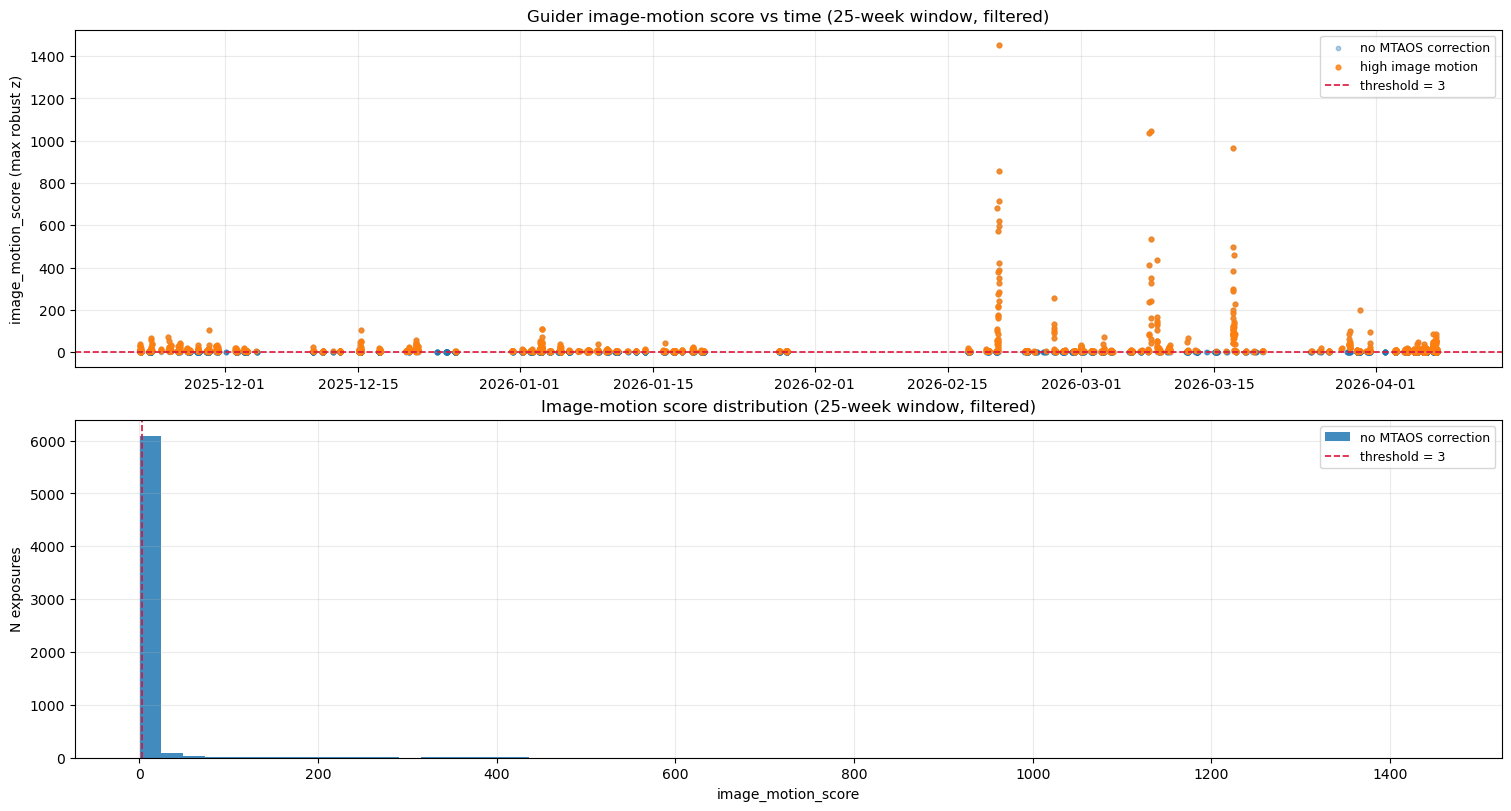

In [24]:
# 25-week context: motion-score plots over the full configured time window
# Filtered to exposures without MTAOS correction during the exposure.
if 'df_motion' not in globals() or df_motion is None or len(df_motion) == 0:
    print('df_motion is not available. Run the main guider image-motion scoring cell first.')
elif 'mtaos_hexapod_correction' not in df_motion.columns:
    print('mtaos_hexapod_correction is missing in df_motion.')
    print('Run the full-dataset MTAOS flagging cell first.')
else:
    plot_25w = df_motion.copy()
    plot_25w['obs_start_utc'] = pd.to_datetime(plot_25w['obs_start'], utc=True, errors='coerce')
    plot_25w['mtaos_hexapod_correction'] = plot_25w['mtaos_hexapod_correction'].fillna(False).astype(bool)
    plot_25w = plot_25w.dropna(subset=['obs_start_utc', 'image_motion_score']).sort_values('obs_start_utc')

    # Keep the configured day_obs bounds for the 25-week sample.
    if 'day_obs_start' in globals() and 'day_obs_end' in globals() and 'day_obs' in plot_25w.columns:
        plot_25w = plot_25w[
            (plot_25w['day_obs'] >= int(day_obs_start)) &
            (plot_25w['day_obs'] <= int(day_obs_end))
        ]

    n_before = len(plot_25w)
    n_removed = int(plot_25w['mtaos_hexapod_correction'].sum())
    plot_25w = plot_25w[~plot_25w['mtaos_hexapod_correction']].copy()

    if len(plot_25w) == 0:
        print('No rows remain after filtering out MTAOS-correction exposures.')
    else:
        t0 = plot_25w['obs_start_utc'].min()
        t1 = plot_25w['obs_start_utc'].max()
        flag_25w = plot_25w[plot_25w['high_image_motion']]
        n_total_25w = len(plot_25w)
        n_flagged_25w = len(flag_25w)
        frac_25w = 100.0 * n_flagged_25w / n_total_25w if n_total_25w > 0 else np.nan

        print('=' * 88)
        print('GUIDER IMAGE-MOTION SCORE ACROSS 25-WEEK WINDOW (MTAOS-CORRECTION EXPOSURES REMOVED)')
        print('=' * 88)
        print(f'Window (from filtered scored data): {t0} to {t1}')
        print(f'Exposures before filtering: {n_before}')
        print(f'Removed by MTAOS correction filter: {n_removed}')
        print(f'Exposures after filtering: {n_total_25w}')
        print(f'High image-motion (>=3) after filtering: {n_flagged_25w} ({frac_25w:.1f}%)')

        fig, axes = plt.subplots(2, 1, figsize=(15, 8), constrained_layout=True)

        axes[0].scatter(
            plot_25w['obs_start_utc'],
            plot_25w['image_motion_score'],
            s=10,
            alpha=0.35,
            color='tab:blue',
            label='no MTAOS correction'
        )
        if len(flag_25w) > 0:
            axes[0].scatter(
                flag_25w['obs_start_utc'],
                flag_25w['image_motion_score'],
                s=12,
                alpha=0.80,
                color='tab:orange',
                label='high image motion'
            )
        axes[0].axhline(3.0, color='crimson', ls='--', lw=1.2, label='threshold = 3')
        axes[0].set_ylabel('image_motion_score (max robust z)')
        axes[0].set_title('Guider image-motion score vs time (25-week window, filtered)')
        axes[0].grid(alpha=0.25)
        axes[0].legend(fontsize=9)

        vals_25w = plot_25w['image_motion_score'].dropna()
        axes[1].hist(vals_25w, bins=60, alpha=0.85, color='tab:blue', label='no MTAOS correction')
        axes[1].axvline(3.0, color='crimson', ls='--', lw=1.2, label='threshold = 3')
        axes[1].set_xlabel('image_motion_score')
        axes[1].set_ylabel('N exposures')
        axes[1].set_title('Image-motion score distribution (25-week window, filtered)')
        axes[1].grid(alpha=0.25)
        axes[1].legend(fontsize=9)

        plt.show()

25-WEEK HIGH-IMAGE-MOTION SCATTERS (WITH AOS CUT): IMAGE QUALITY, WIND, JITTER, ELLIPTICITY
AOS cut applied: aos_fwhm < 0.75
High-motion exposures before AOS cut: 7597
High-motion exposures after AOS cut:  7264
  Top-ring sensor 123 matched (±5s): 4377
  Top-ring sensor 124 matched (±5s): 4377
  Top-ring sensor 125 matched (±5s): 4422
  Top-ring sensor 126 matched (±5s): 4422
  Inside top-ring mean available: 4422


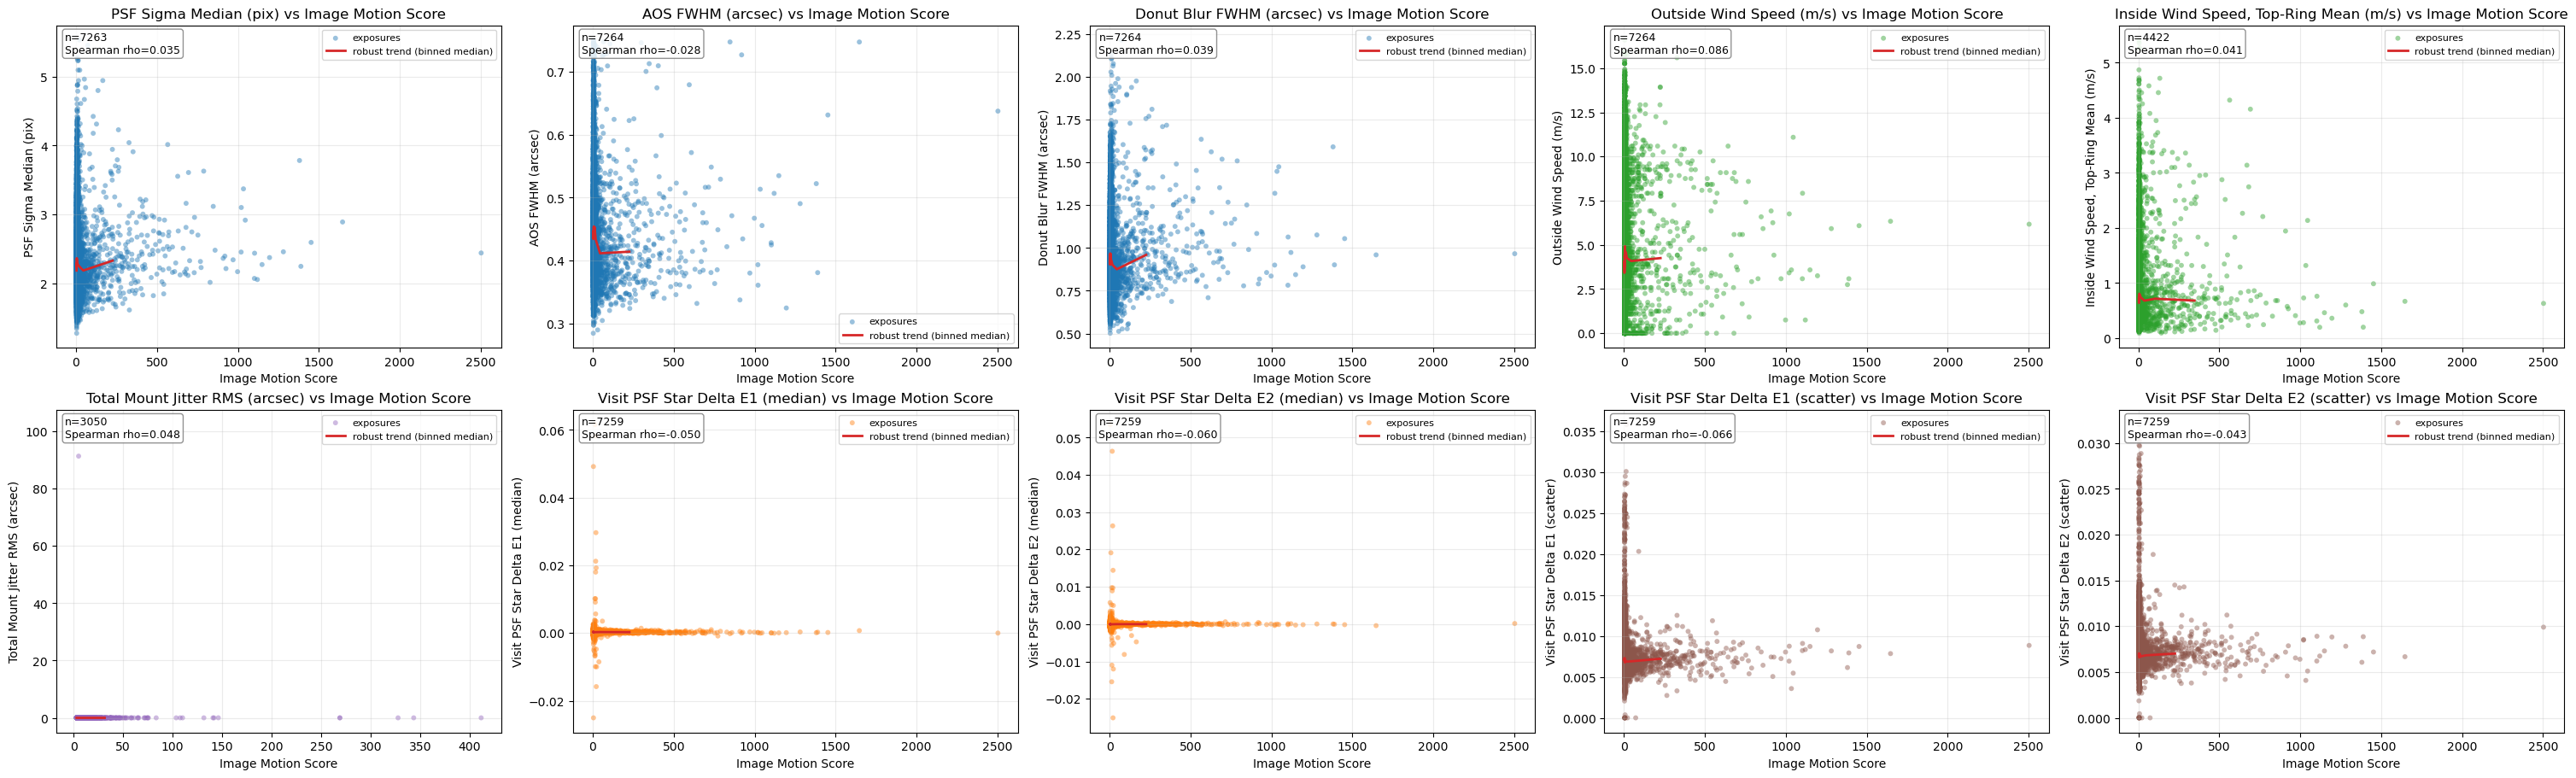

In [81]:
# 25-week high-motion scatter plots with AOS correction cut
if 'df_motion' not in globals() or df_motion is None or len(df_motion) == 0:
    print('df_motion is not available. Run the guider motion scoring cell first.')
else:
    aos_cut = IQ_CUTS['aos_fwhm_max'] if 'IQ_CUTS' in globals() and 'aos_fwhm_max' in IQ_CUTS else 0.75

    cols_query = f"""
    SELECT
        e.exposure_id,
        e.day_obs,
        e.seq_num,
        e.obs_start,
        e.wind_speed,
        q.psf_sigma_median,
        q.aos_fwhm,
        q.donut_blur_fwhm,
        q.psf_star_delta_e1_median_median,
        q.psf_star_delta_e2_median_median,
        q.psf_star_delta_e1_scatter_median,
        q.psf_star_delta_e2_scatter_median,
        m.mount_jitter_rms
    FROM {SCHEMA}.exposure e
    JOIN {SCHEMA}.visit1_quicklook q
      ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
    LEFT JOIN {SCHEMA}.exposure_quicklook m
      ON m.day_obs = e.day_obs AND m.seq_num = e.seq_num
    WHERE e.img_type = 'science'
      AND e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
    ORDER BY e.day_obs, e.seq_num
    """

    try:
        df_iq_25w = consdb_query(cols_query)

        motion_25w = df_motion.copy()
        motion_25w = motion_25w[
            (motion_25w['day_obs'] >= int(day_obs_start)) &
            (motion_25w['day_obs'] <= int(day_obs_end))
        ].copy()

        merged_25w = motion_25w.merge(
            df_iq_25w[[
                'exposure_id', 'obs_start', 'wind_speed', 'psf_sigma_median',
                'aos_fwhm', 'donut_blur_fwhm',
                'psf_star_delta_e1_median_median', 'psf_star_delta_e2_median_median',
                'psf_star_delta_e1_scatter_median', 'psf_star_delta_e2_scatter_median',
                'mount_jitter_rms'
            ]],
            on='exposure_id',
            how='left'
        )

        # Normalize timestamp source after merge (handles obs_start, obs_start_x, obs_start_y).
        obs_col = None
        for c in ['obs_start', 'obs_start_x', 'obs_start_y']:
            if c in merged_25w.columns:
                obs_col = c
                break
        if obs_col is None:
            raise KeyError('No obs_start column found after merge')
        merged_25w['obs_start_utc'] = pd.to_datetime(merged_25w[obs_col], utc=True, errors='coerce')

        high_25w = merged_25w[merged_25w['high_image_motion']].copy()
        high_25w = high_25w[pd.to_numeric(high_25w['aos_fwhm'], errors='coerce') < aos_cut].copy()

        # Compute inside wind speed as mean speedMagnitude of top-ring anemometers 123-126.
        top_ring_idx = [123, 124, 125, 126]
        inside_coverage = {}

        if 'efd_client' in globals() and efd_client is not None and len(high_25w) > 0:
            obs = high_25w[['exposure_id', 'obs_start_utc']].dropna().sort_values('obs_start_utc').copy()
            if len(obs) > 0:
                for idx in top_ring_idx:
                    try:
                        df_t = await efd_client.select_time_series(
                            'lsst.sal.ESS.airTurbulence',
                            fields=['speedMagnitude'],
                            start=Time(obs['obs_start_utc'].min().to_pydatetime(), scale='utc'),
                            end=Time(obs['obs_start_utc'].max().to_pydatetime(), scale='utc'),
                            index=idx,
                        )
                        if df_t is None or len(df_t) == 0:
                            inside_coverage[idx] = 0
                            continue

                        df_t = df_t.reset_index().rename(columns={'index': 'time_utc'})
                        df_t['time_utc'] = pd.to_datetime(df_t['time_utc'], utc=True, errors='coerce')
                        df_t = df_t.dropna(subset=['time_utc', 'speedMagnitude']).sort_values('time_utc')

                        merged_sensor = pd.merge_asof(
                            obs,
                            df_t[['time_utc', 'speedMagnitude']],
                            left_on='obs_start_utc',
                            right_on='time_utc',
                            direction='nearest',
                            tolerance=pd.Timedelta('5s')
                        )
                        speed_col = f'turb_speed_{idx}'
                        obs[speed_col] = merged_sensor['speedMagnitude'].to_numpy()
                        inside_coverage[idx] = int(obs[speed_col].notna().sum())
                    except Exception as e:
                        inside_coverage[idx] = 0
                        print(f'Inside wind sensor {idx} fetch failed: {e}')

                speed_cols = [f'turb_speed_{idx}' for idx in top_ring_idx if f'turb_speed_{idx}' in obs.columns]
                if len(speed_cols) > 0:
                    obs['inside_wind_speed_topring_mean'] = obs[speed_cols].mean(axis=1, skipna=True)
                    inside_map = obs.set_index('exposure_id')['inside_wind_speed_topring_mean']
                    high_25w['inside_wind_speed_topring_mean'] = high_25w['exposure_id'].map(inside_map)

        print('=' * 94)
        print('25-WEEK HIGH-IMAGE-MOTION SCATTERS (WITH AOS CUT): IMAGE QUALITY, WIND, JITTER, ELLIPTICITY')
        print('=' * 94)
        print(f'AOS cut applied: aos_fwhm < {aos_cut}')
        print(f'High-motion exposures before AOS cut: {int(merged_25w["high_image_motion"].sum())}')
        print(f'High-motion exposures after AOS cut:  {len(high_25w)}')
        if len(inside_coverage) > 0:
            for idx in top_ring_idx:
                n = inside_coverage.get(idx, 0)
                print(f'  Top-ring sensor {idx} matched (±5s): {n}')
            n_inside = int(high_25w['inside_wind_speed_topring_mean'].notna().sum()) if 'inside_wind_speed_topring_mean' in high_25w.columns else 0
            print(f'  Inside top-ring mean available: {n_inside}')

        # Robust trend = median-in-quantile-bins of image_motion_score.
        def robust_trend_xy(df_in, x_col, y_col, n_bins=20):
            d = df_in[[x_col, y_col]].dropna().copy()
            if len(d) < 10 or d[x_col].nunique() < 3:
                return None, None
            bins = min(n_bins, max(4, int(np.sqrt(len(d)))))
            try:
                d['_bin'] = pd.qcut(d[x_col], q=bins, duplicates='drop')
            except Exception:
                return None, None
            g = d.groupby('_bin', observed=False).agg(
                x_med=(x_col, 'median'),
                y_med=(y_col, 'median')
            ).dropna()
            if len(g) < 3:
                return None, None
            return g['x_med'].to_numpy(), g['y_med'].to_numpy()

        fig, axes = plt.subplots(2, 5, figsize=(30, 9), constrained_layout=True)
        axes = axes.ravel()

        plot_specs = [
            ('PSF Sigma Median (pix)', 'psf_sigma_median', 'tab:blue'),
            ('AOS FWHM (arcsec)', 'aos_fwhm', 'tab:blue'),
            ('Donut Blur FWHM (arcsec)', 'donut_blur_fwhm', 'tab:blue'),
            ('Outside Wind Speed (m/s)', 'wind_speed', 'tab:green'),
            ('Inside Wind Speed, Top-Ring Mean (m/s)', 'inside_wind_speed_topring_mean', 'tab:green'),
            ('Total Mount Jitter RMS (arcsec)', 'mount_jitter_rms', 'tab:purple'),
            ('Visit PSF Star Delta E1 (median)', 'psf_star_delta_e1_median_median', 'tab:orange'),
            ('Visit PSF Star Delta E2 (median)', 'psf_star_delta_e2_median_median', 'tab:orange'),
            ('Visit PSF Star Delta E1 (scatter)', 'psf_star_delta_e1_scatter_median', 'tab:brown'),
            ('Visit PSF Star Delta E2 (scatter)', 'psf_star_delta_e2_scatter_median', 'tab:brown'),
        ]

        for ax, (ylabel, col, color) in zip(axes, plot_specs):
            sub = high_25w.dropna(subset=['image_motion_score', col]).copy()
            ax.scatter(
                sub['image_motion_score'],
                sub[col],
                s=18,
                alpha=0.45,
                color=color,
                edgecolors='none',
                label='exposures'
            )

            # Spearman rho per panel.
            rho = sub['image_motion_score'].corr(sub[col], method='spearman') if len(sub) > 1 else np.nan
            txt = f"n={len(sub)}\nSpearman rho={rho:.3f}" if pd.notna(rho) else f"n={len(sub)}\nSpearman rho=nan"
            ax.text(
                0.02, 0.98, txt,
                transform=ax.transAxes, va='top', ha='left', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='0.5', alpha=0.85)
            )

            # Robust trend overlay (median in quantile bins).
            x_tr, y_tr = robust_trend_xy(sub, 'image_motion_score', col, n_bins=20)
            if x_tr is not None:
                ax.plot(x_tr, y_tr, color='tab:red', lw=2.0, label='robust trend (binned median)')

            ax.set_xlabel('Image Motion Score')
            ax.set_ylabel(ylabel)
            ax.set_title(f'{ylabel} vs Image Motion Score')
            ax.grid(alpha=0.25)
            ax.legend(fontsize=8, loc='best')

        plt.show()

    except Exception as e:
        print(f'Failed to build 25-week scatter plots: {e}')


In [79]:
# Probe visit1_quicklook e1/e2 columns (excluding guider columns)
try:
    q_cols = consdb_query(f"""
    SELECT column_name
    FROM information_schema.columns
    WHERE table_schema = '{SCHEMA}'
      AND table_name = 'visit1_quicklook'
      AND (column_name ILIKE '%e1%' OR column_name ILIKE '%e2%')
    ORDER BY column_name
    """)
    cols = q_cols['column_name'].astype(str).tolist()
    non_guider = [c for c in cols if 'guider' not in c.lower()]
    print('visit1_quicklook e1/e2-like columns:')
    for c in cols:
        print(f'  {c}')
    print('\nNon-guider candidates:')
    for c in non_guider:
        print(f'  {c}')
except Exception as e:
    print(f'Column probe failed: {e}')


visit1_quicklook e1/e2-like columns:
  guider_e1_mean
  guider_e2_mean
  psf_star_delta_e1_median_max
  psf_star_delta_e1_median_median
  psf_star_delta_e1_median_min
  psf_star_delta_e1_scatter_max
  psf_star_delta_e1_scatter_median
  psf_star_delta_e1_scatter_min
  psf_star_delta_e2_median_max
  psf_star_delta_e2_median_median
  psf_star_delta_e2_median_min
  psf_star_delta_e2_scatter_max
  psf_star_delta_e2_scatter_median
  psf_star_delta_e2_scatter_min

Non-guider candidates:
  psf_star_delta_e1_median_max
  psf_star_delta_e1_median_median
  psf_star_delta_e1_median_min
  psf_star_delta_e1_scatter_max
  psf_star_delta_e1_scatter_median
  psf_star_delta_e1_scatter_min
  psf_star_delta_e2_median_max
  psf_star_delta_e2_median_median
  psf_star_delta_e2_median_min
  psf_star_delta_e2_scatter_max
  psf_star_delta_e2_scatter_median
  psf_star_delta_e2_scatter_min


25-WEEK POINTING SCATTER COLORED BY IMAGE-MOTION SCORE
Filtered exposures plotted: 5763
High-image-motion exposures highlighted: 2033
Color scale clipped to: [0.78, 106.93] (1st-99th percentile)


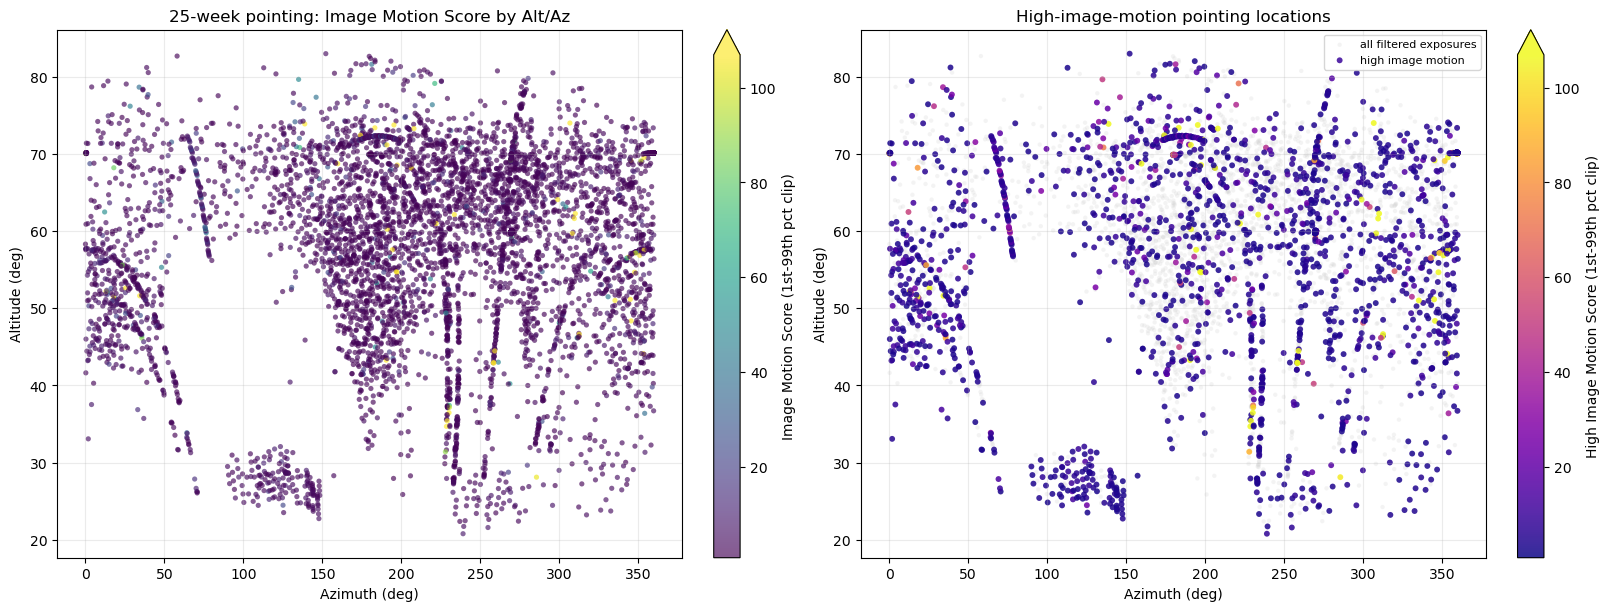

In [75]:
# 25-week pointing scatter: altitude vs azimuth colored by image-motion score
if 'df_motion' not in globals() or df_motion is None or len(df_motion) == 0:
    print('df_motion is not available. Run the guider motion scoring cell first.')
elif 'mtaos_hexapod_correction' not in df_motion.columns:
    print('mtaos_hexapod_correction is missing in df_motion.')
    print('Run the full-dataset MTAOS flagging cell first.')
else:
    point_25w = df_motion.copy()
    point_25w = point_25w[
        (point_25w['day_obs'] >= int(day_obs_start)) &
        (point_25w['day_obs'] <= int(day_obs_end))
    ].copy()
    point_25w['mtaos_hexapod_correction'] = point_25w['mtaos_hexapod_correction'].fillna(False).astype(bool)
    point_25w = point_25w[~point_25w['mtaos_hexapod_correction']].copy()

    need_pointing_merge = ('altitude' not in point_25w.columns) or ('azimuth' not in point_25w.columns)
    if need_pointing_merge:
        pointing_query = f"""
        SELECT
            e.exposure_id,
            e.altitude,
            e.azimuth
        FROM {SCHEMA}.exposure e
        WHERE e.img_type = 'science'
          AND e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
        """
        try:
            point_meta = consdb_query(pointing_query)
            point_25w = point_25w.merge(
                point_meta[['exposure_id', 'altitude', 'azimuth']],
                on='exposure_id',
                how='left'
            )
        except Exception as e:
            print(f'Failed to fetch altitude/azimuth from ConsDB: {e}')

    point_25w['altitude'] = pd.to_numeric(point_25w['altitude'], errors='coerce')
    point_25w['azimuth'] = pd.to_numeric(point_25w['azimuth'], errors='coerce')
    point_25w = point_25w.dropna(subset=['image_motion_score', 'altitude', 'azimuth']).copy()
    point_25w = point_25w[(point_25w['altitude'] >= 0) & (point_25w['altitude'] <= 90)].copy()

    if len(point_25w) == 0:
        print('No valid rows available for altitude/azimuth pointing scatter.')
    else:
        # Clip the colormap to reduce compression from a few very large scores.
        score_lo = float(point_25w['image_motion_score'].quantile(0.01))
        score_hi = float(point_25w['image_motion_score'].quantile(0.99))
        if not np.isfinite(score_lo):
            score_lo = float(point_25w['image_motion_score'].min())
        if not np.isfinite(score_hi):
            score_hi = float(point_25w['image_motion_score'].max())
        if score_hi <= score_lo:
            score_lo = float(point_25w['image_motion_score'].min())
            score_hi = float(point_25w['image_motion_score'].max())

        fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

        sc0 = axes[0].scatter(
            point_25w['azimuth'],
            point_25w['altitude'],
            c=point_25w['image_motion_score'],
            s=14,
            cmap='viridis',
            alpha=0.65,
            edgecolors='none',
            vmin=score_lo,
            vmax=score_hi
        )
        axes[0].set_xlabel('Azimuth (deg)')
        axes[0].set_ylabel('Altitude (deg)')
        axes[0].set_title('25-week pointing: Image Motion Score by Alt/Az')
        axes[0].grid(alpha=0.25)
        cbar0 = fig.colorbar(sc0, ax=axes[0], extend='max')
        cbar0.set_label('Image Motion Score (1st-99th pct clip)')

        high_point = point_25w[point_25w['high_image_motion']].copy() if 'high_image_motion' in point_25w.columns else point_25w.iloc[0:0].copy()
        axes[1].scatter(
            point_25w['azimuth'],
            point_25w['altitude'],
            c='lightgray',
            s=10,
            alpha=0.25,
            edgecolors='none',
            label='all filtered exposures'
        )
        if len(high_point) > 0:
            sc_hi = axes[1].scatter(
                high_point['azimuth'],
                high_point['altitude'],
                c=high_point['image_motion_score'],
                s=18,
                cmap='plasma',
                alpha=0.85,
                edgecolors='none',
                label='high image motion',
                vmin=score_lo,
                vmax=score_hi
            )
            cbar1 = fig.colorbar(sc_hi, ax=axes[1], extend='max')
            cbar1.set_label('High Image Motion Score (1st-99th pct clip)')
        axes[1].set_xlabel('Azimuth (deg)')
        axes[1].set_ylabel('Altitude (deg)')
        axes[1].set_title('High-image-motion pointing locations')
        axes[1].grid(alpha=0.25)
        axes[1].legend(fontsize=8, loc='best')

        print('=' * 88)
        print('25-WEEK POINTING SCATTER COLORED BY IMAGE-MOTION SCORE')
        print('=' * 88)
        print(f'Filtered exposures plotted: {len(point_25w)}')
        print(f'High-image-motion exposures highlighted: {len(high_point)}')
        print(f'Color scale clipped to: [{score_lo:.2f}, {score_hi:.2f}] (1st-99th percentile)')

        plt.show()

25-WEEK ALT/AZ BINNED HEATMAPS
Exposures used    : 5763
Grid cells total  : 504
Bins populated (≥5): 243
Median score range: [1.17, 20.22]
Max high-motion fraction in any bin: 1.000


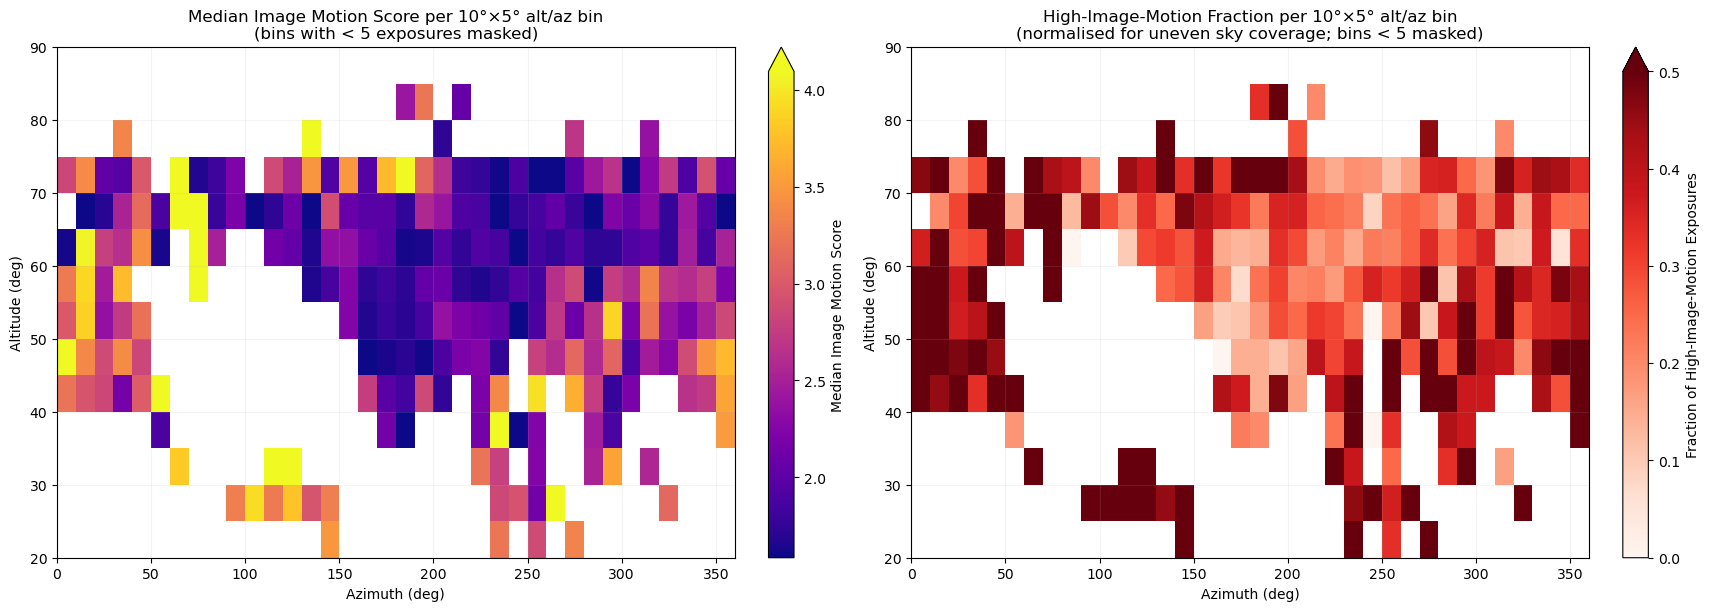

In [76]:

# 25-week pointing: 2D binned heatmaps — median image-motion score and high-motion fraction
if 'point_25w' not in globals() or len(point_25w) == 0:
    print('point_25w is not available. Run the pointing scatter cell first.')
else:
    from scipy.stats import binned_statistic_2d

    az_bins  = np.linspace(0,  360, 37)  # 36 × 10-deg bins in azimuth
    alt_bins = np.linspace(20,  90, 15)  # 14 ×  5-deg bins in altitude

    az    = point_25w['azimuth'].values
    alt   = point_25w['altitude'].values
    score = point_25w['image_motion_score'].values
    is_high = point_25w['high_image_motion'].astype(float).values if 'high_image_motion' in point_25w.columns else np.zeros(len(point_25w))

    # Median image-motion score per bin
    stat_med, az_edges, alt_edges, _ = binned_statistic_2d(
        az, alt, score, statistic='median', bins=[az_bins, alt_bins]
    )
    # Exposure count per bin
    stat_cnt, _, _, _ = binned_statistic_2d(
        az, alt, score, statistic='count', bins=[az_bins, alt_bins]
    )
    # High-motion fraction per bin
    stat_frac, _, _, _ = binned_statistic_2d(
        az, alt, is_high, statistic='mean', bins=[az_bins, alt_bins]
    )

    # Mask bins with too few exposures to suppress statistical noise
    min_bin_count = 5
    mask = stat_cnt < min_bin_count
    stat_med_masked  = np.ma.masked_where(mask, stat_med)
    stat_frac_masked = np.ma.masked_where(mask, stat_frac)

    # Colour range for the median-score panel: 5th–95th percentile of populated bins
    flat_med = stat_med_masked.compressed()
    med_lo = float(np.percentile(flat_med,  5)) if len(flat_med) > 0 else 0.0
    med_hi = float(np.percentile(flat_med, 95)) if len(flat_med) > 0 else 1.0

    fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True)

    # ── Left panel: median image-motion score ────────────────────────────────
    pm0 = axes[0].pcolormesh(
        az_edges, alt_edges, stat_med_masked.T,
        cmap='plasma', vmin=med_lo, vmax=med_hi, shading='flat'
    )
    cb0 = fig.colorbar(pm0, ax=axes[0], extend='max')
    cb0.set_label('Median Image Motion Score')
    axes[0].set_xlabel('Azimuth (deg)')
    axes[0].set_ylabel('Altitude (deg)')
    axes[0].set_title(
        f'Median Image Motion Score per 10°×5° alt/az bin\n'
        f'(bins with < {min_bin_count} exposures masked)'
    )
    axes[0].set_xlim(0, 360)
    axes[0].set_ylim(20, 90)
    axes[0].grid(alpha=0.15)

    # ── Right panel: high-motion fraction ────────────────────────────────────
    pm1 = axes[1].pcolormesh(
        az_edges, alt_edges, stat_frac_masked.T,
        cmap='Reds', vmin=0.0, vmax=0.5, shading='flat'
    )
    cb1 = fig.colorbar(pm1, ax=axes[1], extend='max')
    cb1.set_label('Fraction of High-Image-Motion Exposures')
    axes[1].set_xlabel('Azimuth (deg)')
    axes[1].set_ylabel('Altitude (deg)')
    axes[1].set_title(
        f'High-Image-Motion Fraction per 10°×5° alt/az bin\n'
        f'(normalised for uneven sky coverage; bins < {min_bin_count} masked)'
    )
    axes[1].set_xlim(0, 360)
    axes[1].set_ylim(20, 90)
    axes[1].grid(alpha=0.15)

    print('=' * 88)
    print('25-WEEK ALT/AZ BINNED HEATMAPS')
    print('=' * 88)
    n_bins_total     = (len(az_bins) - 1) * (len(alt_bins) - 1)
    n_bins_populated = int((stat_cnt >= min_bin_count).sum())
    print(f'Exposures used    : {len(point_25w)}')
    print(f'Grid cells total  : {n_bins_total}')
    print(f'Bins populated (≥{min_bin_count}): {n_bins_populated}')
    if len(flat_med) > 0:
        print(f'Median score range: [{flat_med.min():.2f}, {flat_med.max():.2f}]')
        print(f'Max high-motion fraction in any bin: {float(stat_frac_masked.max()):.3f}')

    plt.show()


In [18]:
# Check EFD client available methods
if 'efd_client' in locals() and efd_client is not None:
    efd_methods = [m for m in dir(efd_client) if not m.startswith('_')]
    print("Available EFD client methods:")
    for method in efd_methods[:20]:  # Show first 20
        print(f"  - {method}")
    if len(efd_methods) > 20:
        print(f"  ... and {len(efd_methods) - 20} more")


Available EFD client methods:
  - auth
  - build_time_range_query
  - db_name
  - deployment
  - from_name
  - get_fields
  - get_schema
  - get_topics
  - influx_client
  - list_efd_names
  - query_history
  - schema_registry_url
  - select_packed_time_series
  - select_time_series
  - select_top_n
  - subclasses


In [82]:
# Nights with unusually large high-image-motion load
if 'df_motion' not in globals() or df_motion is None or len(df_motion) == 0:
    print('df_motion is not available. Run the guider motion scoring cell first.')
elif 'day_obs' not in df_motion.columns or 'high_image_motion' not in df_motion.columns:
    print('df_motion is missing required columns: day_obs / high_image_motion')
else:
    night_stats = (
        df_motion.groupby('day_obs', as_index=False)
        .agg(
            n_total=('exposure_id', 'count'),
            n_high=('high_image_motion', 'sum')
        )
        .sort_values('day_obs')
        .reset_index(drop=True)
    )
    night_stats['frac_high'] = night_stats['n_high'] / night_stats['n_total'].clip(lower=1)

    def robust_z(s):
        med = s.median()
        mad = (s - med).abs().median()
        if mad == 0 or not np.isfinite(mad):
            return pd.Series(np.zeros(len(s)), index=s.index)
        return 0.6745 * (s - med) / mad

    night_stats['z_high_count'] = robust_z(night_stats['n_high'])
    night_stats['z_high_frac'] = robust_z(night_stats['frac_high'])

    # "Unusually large" = robust z >= 3 on count and/or fraction.
    out_count = night_stats[night_stats['z_high_count'] >= 3].copy()
    out_frac = night_stats[night_stats['z_high_frac'] >= 3].copy()
    out_any = night_stats[(night_stats['z_high_count'] >= 3) | (night_stats['z_high_frac'] >= 3)].copy()

    print('=' * 94)
    print('NIGHTS WITH UNUSUALLY LARGE HIGH-IMAGE-MOTION LOAD')
    print('=' * 94)
    print(f'Total nights analyzed: {len(night_stats)}')
    print('Criterion: robust z >= 3 using median/MAD')

    print('\nBy high-motion COUNT outlier:')
    if len(out_count) == 0:
        print('  none')
    else:
        display(out_count[['day_obs', 'n_high', 'n_total', 'frac_high', 'z_high_count']].sort_values('z_high_count', ascending=False))

    print('\nBy high-motion FRACTION outlier:')
    if len(out_frac) == 0:
        print('  none')
    else:
        display(out_frac[['day_obs', 'n_high', 'n_total', 'frac_high', 'z_high_frac']].sort_values('z_high_frac', ascending=False))

    print('\nCombined unusual nights (count OR fraction):')
    if len(out_any) == 0:
        print('  none')
    else:
        display(
            out_any[
                ['day_obs', 'n_high', 'n_total', 'frac_high', 'z_high_count', 'z_high_frac']
            ].sort_values(['z_high_count', 'z_high_frac'], ascending=False)
        )

    print('\nTop 10 nights by number of high-image-motion exposures:')
    display(
        night_stats[['day_obs', 'n_high', 'n_total', 'frac_high', 'z_high_count', 'z_high_frac']]
        .sort_values('n_high', ascending=False)
        .head(10)
    )


NIGHTS WITH UNUSUALLY LARGE HIGH-IMAGE-MOTION LOAD
Total nights analyzed: 106
Criterion: robust z >= 3 using median/MAD

By high-motion COUNT outlier:


,day_obs,n_high,n_total,frac_high,z_high_count
89,20260316,428,602,0.710963,5.718261
52,20260107,388,484,0.801653,5.118706
105,20260405,327,842,0.388361,4.204383
68,20260219,299,513,0.582846,3.784694
27,20251129,280,502,0.557769,3.499906
99,20260330,273,811,0.336621,3.394983



By high-motion FRACTION outlier:


,day_obs,n_high,n_total,frac_high,z_high_frac
96,20260327,34,38,0.894737,3.624005
52,20260107,388,484,0.801653,3.152619
40,20251220,149,192,0.776042,3.022921



Combined unusual nights (count OR fraction):


,day_obs,n_high,n_total,frac_high,z_high_count,z_high_frac
89,20260316,428,602,0.710963,5.718261,2.693358
52,20260107,388,484,0.801653,5.118706,3.152619
105,20260405,327,842,0.388361,4.204383,1.059665
68,20260219,299,513,0.582846,3.784694,2.044557
27,20251129,280,502,0.557769,3.499906,1.917564
99,20260330,273,811,0.336621,3.394983,0.797650
40,20251220,149,192,0.776042,1.536361,3.022921
96,20260327,34,38,0.894737,-0.187361,3.624005



Top 10 nights by number of high-image-motion exposures:


,day_obs,n_high,n_total,frac_high,z_high_count,z_high_frac
89,20260316,428,602,0.710963,5.718261,2.693358
52,20260107,388,484,0.801653,5.118706,3.152619
105,20260405,327,842,0.388361,4.204383,1.059665
68,20260219,299,513,0.582846,3.784694,2.044557
27,20251129,280,502,0.557769,3.499906,1.917564
99,20260330,273,811,0.336621,3.394983,0.797650
53,20260108,234,446,0.524664,2.810417,1.749916
82,20260308,184,745,0.246980,2.060972,0.343696
98,20260329,177,788,0.224619,1.956050,0.230460
67,20260218,176,418,0.421053,1.941061,1.225219


DAILY MTAOS CORRECTION FLAG SUMMARY
Nights: 107
Total exposures: 35720
Total flagged exposures: 27719
Overall flagged fraction: 0.776

Top 10 nights by flagged count:


,day_obs,n_flagged,n_total,frac_flagged
91,20260318,881,892,0.987668
84,20260311,792,833,0.950780
87,20260314,782,819,0.954823
78,20260303,755,797,0.947302
97,20260328,752,793,0.948298
99,20260330,748,811,0.922318
98,20260329,684,788,0.868020
82,20260308,683,745,0.916779
74,20260227,610,680,0.897059
85,20260312,609,647,0.941267


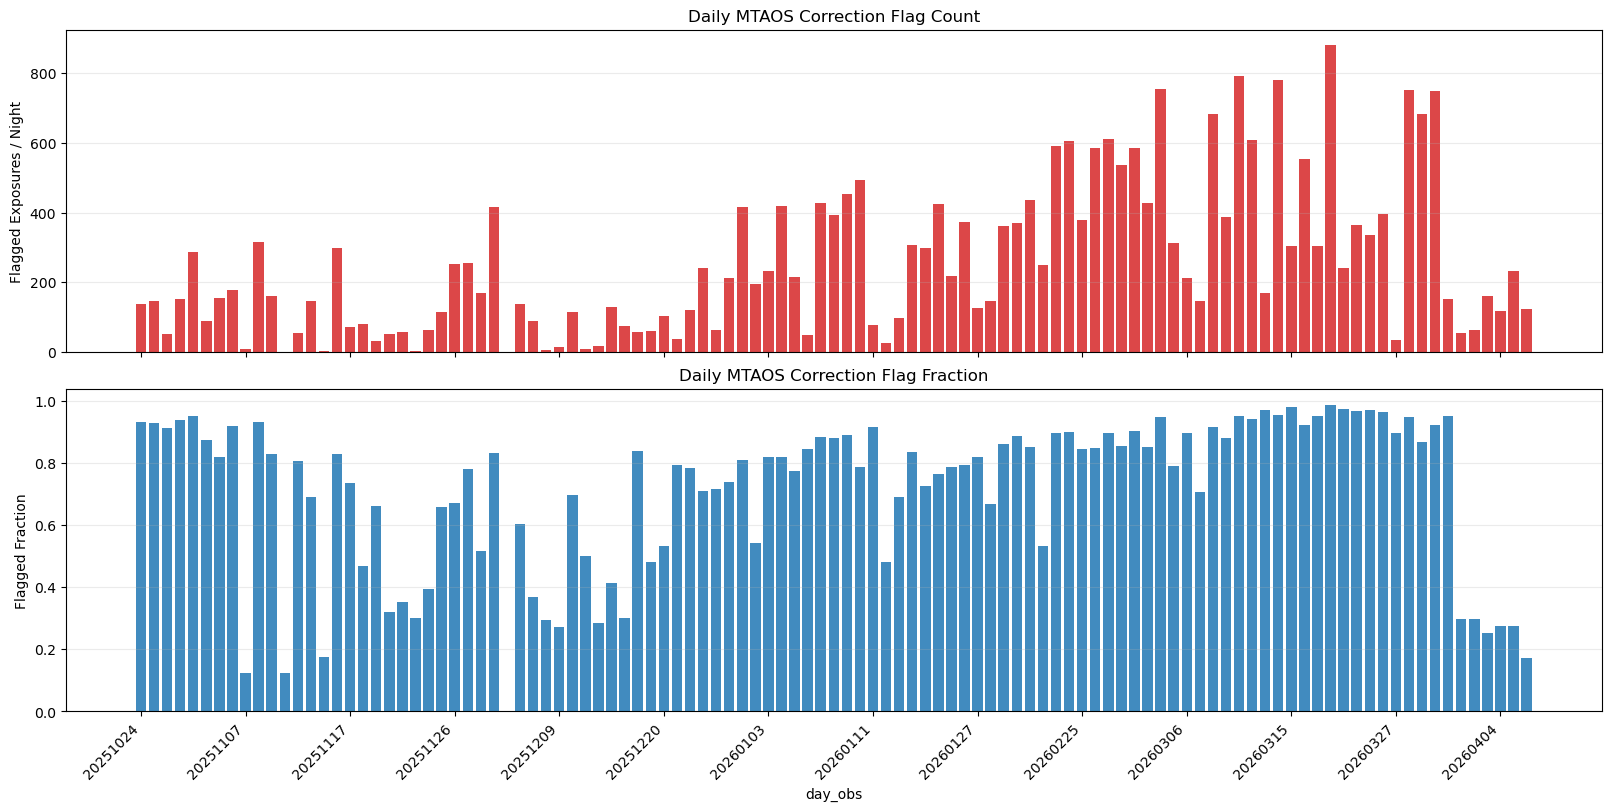

In [11]:
# Daily histogram of exposures with MTAOS correction flag
if 'df_motion' not in globals() or df_motion is None or len(df_motion) == 0:
    print('df_motion is not available. Run the full-dataset motion/MTAOS flagging cells first.')
elif 'day_obs' not in df_motion.columns or 'mtaos_hexapod_correction' not in df_motion.columns:
    print('df_motion is missing required columns: day_obs and/or mtaos_hexapod_correction.')
else:
    plot_df = df_motion[['day_obs', 'mtaos_hexapod_correction']].copy()
    plot_df['mtaos_hexapod_correction'] = plot_df['mtaos_hexapod_correction'].fillna(False).astype(bool)

    daily = (
        plot_df.groupby('day_obs', as_index=False)
        .agg(
            n_total=('mtaos_hexapod_correction', 'size'),
            n_flagged=('mtaos_hexapod_correction', 'sum')
        )
        .sort_values('day_obs')
        .reset_index(drop=True)
    )
    daily['frac_flagged'] = daily['n_flagged'] / daily['n_total'].clip(lower=1)

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True, constrained_layout=True)

    # Top: daily count of flagged exposures
    axes[0].bar(daily['day_obs'].astype(str), daily['n_flagged'], color='tab:red', alpha=0.85)
    axes[0].set_ylabel('Flagged Exposures / Night')
    axes[0].set_title('Daily MTAOS Correction Flag Count')
    axes[0].grid(axis='y', alpha=0.25)

    # Bottom: daily flagged fraction (context for varying nightly load)
    axes[1].bar(daily['day_obs'].astype(str), daily['frac_flagged'], color='tab:blue', alpha=0.85)
    axes[1].set_ylabel('Flagged Fraction')
    axes[1].set_xlabel('day_obs')
    axes[1].set_title('Daily MTAOS Correction Flag Fraction')
    axes[1].grid(axis='y', alpha=0.25)

    # Keep tick labels readable over many nights
    xticks = np.arange(0, len(daily), max(1, len(daily) // 12))
    axes[1].set_xticks(xticks)
    axes[1].set_xticklabels(daily['day_obs'].astype(str).iloc[xticks], rotation=45, ha='right')

    print('=' * 88)
    print('DAILY MTAOS CORRECTION FLAG SUMMARY')
    print('=' * 88)
    print(f'Nights: {len(daily)}')
    print(f'Total exposures: {int(daily["n_total"].sum())}')
    print(f'Total flagged exposures: {int(daily["n_flagged"].sum())}')
    print(f'Overall flagged fraction: {daily["n_flagged"].sum() / daily["n_total"].sum():.3f}')

    top_days = daily.sort_values('n_flagged', ascending=False).head(10)
    print('\nTop 10 nights by flagged count:')
    display(top_days[['day_obs', 'n_flagged', 'n_total', 'frac_flagged']])

    plt.show()


Plotting 5 correction-type flags across 35720 exposures

DAILY CORRECTION-TYPE FLAG SUMMARY

Hexapod Correction:
  Total exposures flagged: 27719 / 35720 (77.6%)
  Nights: 107
  Top 5 nights by fraction:
    20260318:  881 /  892 ( 98.8%)
    20260315:  304 /  310 ( 98.1%)
    20260319:  241 /  248 ( 97.2%)
    20260313:  170 /  175 ( 97.1%)
    20260325:  336 /  346 ( 97.1%)

Mount Tracking Drift:
  Total exposures flagged: 8568 / 35720 (24.0%)
  Nights: 107
  Top 5 nights by fraction:
    20251202:  164 /  245 ( 66.9%)
    20251209:   29 /   48 ( 60.4%)
    20251121:   94 /  165 ( 57.0%)
    20251201:  124 /  230 ( 53.9%)
    20251128:  170 /  330 ( 51.5%)

Mount Optical Movement:
  Total exposures flagged: 6666 / 35720 (18.7%)
  Nights: 107
  Top 5 nights by fraction:
    20260107:  418 /  484 ( 86.4%)
    20260108:  380 /  446 ( 85.2%)
    20260307:  171 /  208 ( 82.2%)
    20251211:   14 /   18 ( 77.8%)
    20251220:  142 /  192 ( 74.0%)

Rotator Tracking Drift:
  Total exposures 

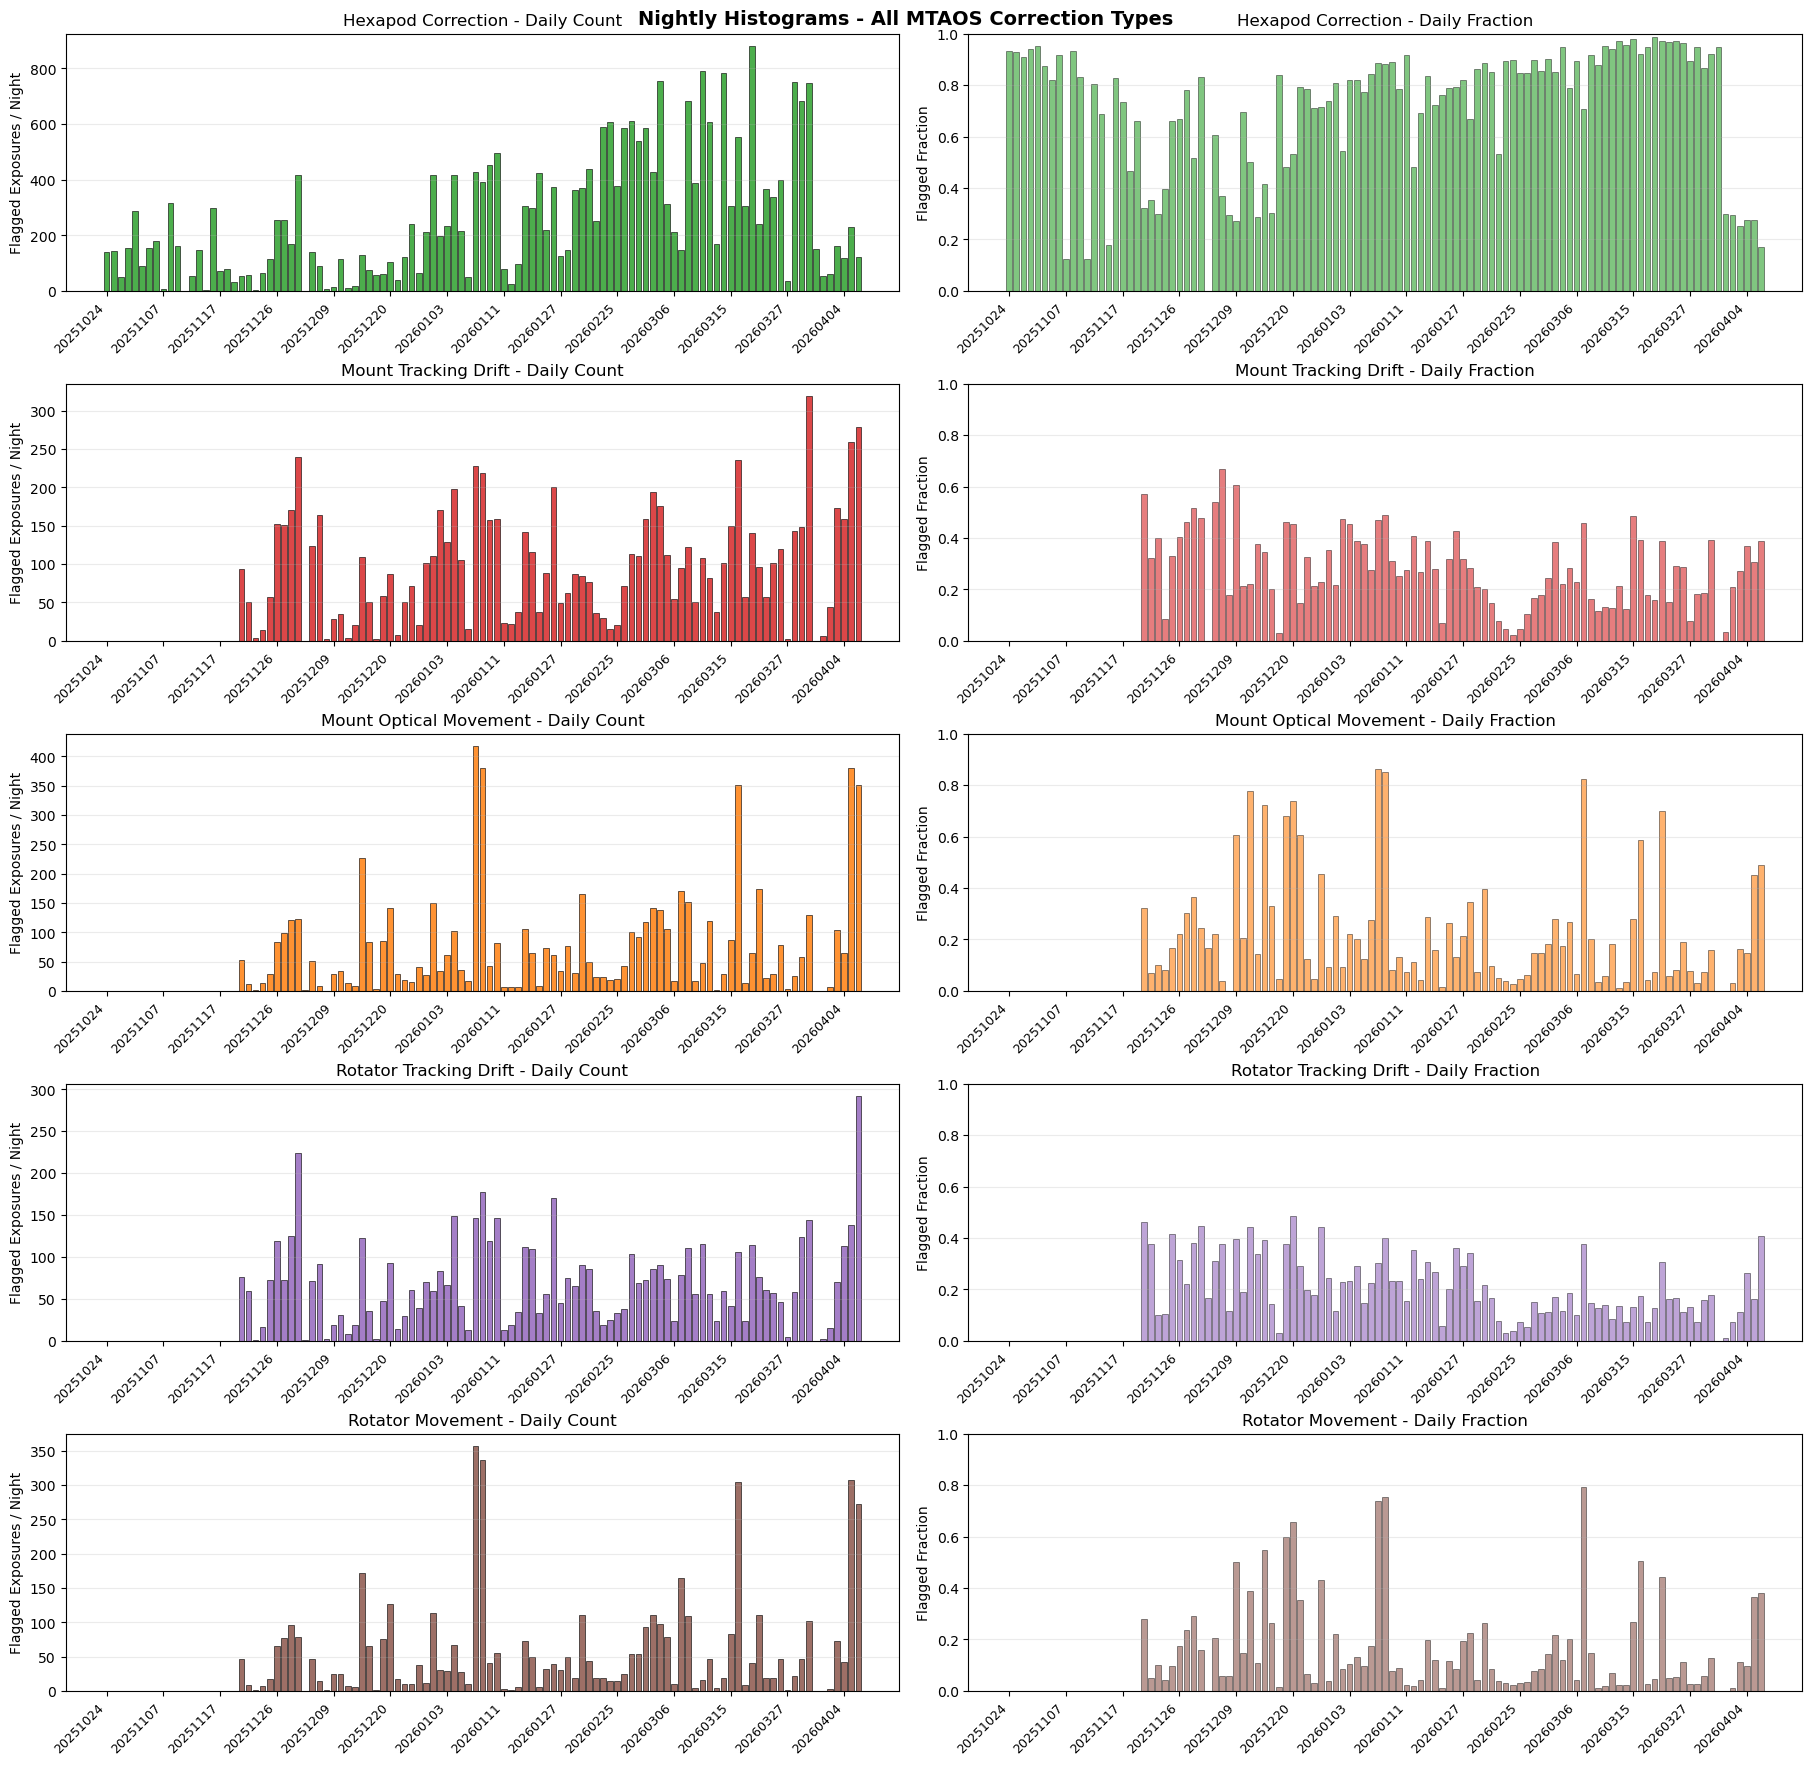

In [35]:
# Paneled nightly histogram for all correction-type flags
if 'df_motion' not in globals() or df_motion is None or len(df_motion) == 0:
    print('df_motion is not available. Run the full-dataset motion/MTAOS flagging cells first.')
else:
    # Define the 5 correction-type flags to plot
    correction_flags = [
        'mtaos_hexapod_correction',
        'mtaos_mount_tracking_drift',
        'mtaos_mount_optical_movement',
        'mtaos_rotator_tracking_drift',
        'mtaos_rotator_movement',
    ]
    
    correction_titles = [
        'Hexapod Correction',
        'Mount Tracking Drift',
        'Mount Optical Movement',
        'Rotator Tracking Drift',
        'Rotator Movement',
    ]
    
    correction_colors = [
        'tab:green',    # hexapod
        'tab:red',      # mount tracking
        'tab:orange',   # mount optical
        'tab:purple',   # rotator tracking
        'tab:brown',    # rotator movement
    ]
    
    # Check which flags are available
    available = [f for f in correction_flags if f in df_motion.columns]
    if not available:
        print('No correction-type flags found in df_motion.')
    else:
        print(f'Plotting {len(available)} correction-type flags across {len(df_motion)} exposures\n')
        
        # Create daily aggregates for each flag
        daily_data = {}
        for flag in available:
            plot_df = df_motion[['day_obs', flag]].copy()
            plot_df[flag] = plot_df[flag].fillna(False).astype(bool)
            
            daily_agg = (
                plot_df.groupby('day_obs', as_index=False)
                .agg(
                    n_total=(flag, 'size'),
                    n_flagged=(flag, 'sum')
                )
                .sort_values('day_obs')
                .reset_index(drop=True)
            )
            daily_agg['frac_flagged'] = daily_agg['n_flagged'] / daily_agg['n_total'].clip(lower=1)
            daily_data[flag] = daily_agg
        
        # Create the multi-panel figure (5 rows x 2 columns: count + fraction per flag)
        fig, axes = plt.subplots(len(available), 2, figsize=(18, 3.5*len(available)), 
                                  constrained_layout=True)
        
        # Ensure axes is always 2D even for 1 row
        if len(available) == 1:
            axes = axes.reshape(1, -1)
        
        for row, (flag, title, color) in enumerate(zip(available, 
                                                        [correction_titles[correction_flags.index(f)] for f in available],
                                                        [correction_colors[correction_flags.index(f)] for f in available])):
            daily = daily_data[flag]
            
            # Left plot: daily count of flagged exposures
            axes[row, 0].bar(daily['day_obs'].astype(str), daily['n_flagged'], 
                            color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
            axes[row, 0].set_ylabel('Flagged Exposures / Night')
            axes[row, 0].set_title(f'{title} - Daily Count')
            axes[row, 0].grid(axis='y', alpha=0.25)
            
            # Right plot: daily flagged fraction
            axes[row, 1].bar(daily['day_obs'].astype(str), daily['frac_flagged'], 
                            color=color, alpha=0.6, edgecolor='black', linewidth=0.5)
            axes[row, 1].set_ylabel('Flagged Fraction')
            axes[row, 1].set_title(f'{title} - Daily Fraction')
            axes[row, 1].grid(axis='y', alpha=0.25)
            axes[row, 1].set_ylim([0, 1])
            
            # Set readonly tick labels to be readable
            xticks = np.arange(0, len(daily), max(1, len(daily) // 12))
            axes[row, 1].set_xticks(xticks)
            axes[row, 1].set_xticklabels(daily['day_obs'].astype(str).iloc[xticks], 
                                        rotation=45, ha='right', fontsize=9)
            axes[row, 0].set_xticks(xticks)
            axes[row, 0].set_xticklabels(daily['day_obs'].astype(str).iloc[xticks], 
                                        rotation=45, ha='right', fontsize=9)
        
        fig.suptitle('Nightly Histograms - All MTAOS Correction Types', 
                    fontsize=14, fontweight='bold', y=1.00)
        
        # Print summary statistics
        print('='*88)
        print('DAILY CORRECTION-TYPE FLAG SUMMARY')
        print('='*88)
        
        for flag, title in zip(available, [correction_titles[correction_flags.index(f)] for f in available]):
            daily = daily_data[flag]
            n_total = int(daily['n_total'].sum())
            n_flagged = int(daily['n_flagged'].sum())
            frac = n_flagged / n_total if n_total > 0 else 0
            
            print(f'\n{title}:')
            print(f'  Total exposures flagged: {n_flagged} / {n_total} ({100*frac:.1f}%)')
            print(f'  Nights: {len(daily)}')
            
            top_nights = daily.sort_values('frac_flagged', ascending=False).head(5)
            print(f'  Top 5 nights by fraction:')
            for _, row in top_nights.iterrows():
                print(f'    {int(row["day_obs"])}: {int(row["n_flagged"]):4d} / {int(row["n_total"]):4d} ({100*row["frac_flagged"]:5.1f}%)')
        
        print('\n' + '='*88)
        plt.show()


In [13]:
# Scatter plots: detrended altitude/azimuth RMS vs PSF moment-derived e1/e2
# e1 = (Ixx - Iyy) / (Ixx + Iyy),  e2 = 2*Ixy / (Ixx + Iyy)
# Limited to exposures with NO hexapod correction.
from sqlalchemy import text

if 'df_motion' not in globals() or df_motion is None or len(df_motion) == 0:
    print('df_motion not available. Run the motion scoring cells first.')
elif 'engine' not in globals():
    print('ConsDB engine not available.')
else:
    df_moments = pd.read_sql(text(f"""
        SELECT
            e.exposure_id,
            q.psf_ixx_median,
            q.psf_iyy_median,
            q.psf_ixy_median
        FROM {SCHEMA}.exposure e
        JOIN {SCHEMA}.visit1_quicklook q
          ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
        WHERE e.img_type = 'science'
          AND e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
        ORDER BY e.day_obs, e.seq_num
    """), engine.connect())

    for c in ['psf_ixx_median', 'psf_iyy_median', 'psf_ixy_median']:
        df_moments[c] = pd.to_numeric(df_moments[c], errors='coerce')

    denom = df_moments['psf_ixx_median'] + df_moments['psf_iyy_median']
    df_moments['e1_moments'] = (df_moments['psf_ixx_median'] - df_moments['psf_iyy_median']) / denom
    df_moments['e2_moments'] = 2 * df_moments['psf_ixy_median'] / denom

    df_combined = df_motion.merge(df_moments[['exposure_id', 'e1_moments', 'e2_moments']],
                                  on='exposure_id', how='left')

    df_combined = df_combined[~df_combined['mtaos_hexapod_correction'].fillna(False).astype(bool)].copy()
    print(f'Rows after no-hexapod filter: {len(df_combined)}')

    rms_axes = [
        ('guider_altitude_rms_detrended', 'Altitude RMS detrended (arcsec)'),
        ('guider_azimuth_rms_detrended',  'Azimuth RMS detrended (arcsec)'),
    ]
    ellip_axes = [
        ('e1_moments', 'e1  =  (Ixx − Iyy) / (Ixx + Iyy)'),
        ('e2_moments', 'e2  =  2 Ixy / (Ixx + Iyy)'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

    for r_i, (rms_col, rms_label) in enumerate(rms_axes):
        for c_i, (e_col, e_label) in enumerate(ellip_axes):
            ax = axes[r_i, c_i]
            valid = df_combined[df_combined[rms_col].notna() & df_combined[e_col].notna()].copy()
            if len(valid) > 0:
                ax.scatter(valid[rms_col], valid[e_col], s=12, alpha=0.35, color='tab:blue')
                corr = valid[rms_col].corr(valid[e_col])
                ax.set_title(f'r = {corr:.3f}  (n={len(valid)})', fontsize=11, fontweight='bold')
            else:
                ax.set_title('No valid data', fontsize=11)
            ax.set_xlabel(rms_label, fontsize=10)
            ax.set_ylabel(e_label, fontsize=10)
            ax.grid(alpha=0.25)

    fig.suptitle('Guider Detrended RMS vs PSF Moment Ellipticity (No Hexapod Correction)',
                 fontsize=13, fontweight='bold')
    plt.show()

    print('\n' + '=' * 80)
    print('CORRELATION SUMMARY: GUIDER RMS vs PSF MOMENT E1/E2 (NO HEXAPOD CORRECTION)')
    print('=' * 80)
    for rms_col, rms_label in rms_axes:
        print(f'\n{rms_label}:')
        for e_col, e_label in ellip_axes:
            valid = df_combined[df_combined[rms_col].notna() & df_combined[e_col].notna()]
            if len(valid) > 0:
                corr = valid[rms_col].corr(valid[e_col])
                print(f'  vs {e_col:15s}: r = {corr:7.4f}  (n={len(valid)})')

df_motion not available. Run the motion scoring cells first.


In [32]:
# Inspect ConsDB for non-delta PSF/star ellipticity columns
if 'consdb_query' not in globals() or 'SCHEMA' not in globals():
    print('consdb_query/SCHEMA not available.')
else:
    col_scan = consdb_query(f"""
        SELECT
            table_name,
            column_name,
            data_type
        FROM information_schema.columns
        WHERE table_schema = '{SCHEMA}'
          AND (
              column_name ILIKE '%ellip%'
              OR column_name ILIKE '%e1%'
              OR column_name ILIKE '%e2%'
          )
        ORDER BY table_name, column_name
    """)

    print(f'Total ellipticity-like columns in {SCHEMA}: {len(col_scan)}')

    # Focus on star/psf-oriented columns.
    star_psf = col_scan[
        col_scan['column_name'].str.contains('psf|star', case=False, na=False)
    ].copy()

    # Candidate "simple" columns: exclude explicit deltas.
    simple_star_psf = star_psf[
        ~star_psf['column_name'].str.contains('delta', case=False, na=False)
    ].copy()

    print('\nAll PSF/star ellipticity-like columns:')
    display(star_psf)

    print('\nPSF/star non-delta candidates (simple mean/median-style):')
    display(simple_star_psf)

    if len(simple_star_psf) == 0:
        print('\nNo non-delta PSF/star e1/e2 columns found in this schema.')

    # Also show guider non-delta e1/e2 for reference.
    guider_simple = col_scan[
        col_scan['column_name'].isin(['guider_e1_mean', 'guider_e2_mean'])
    ]
    if len(guider_simple) > 0:
        print('\nAvailable simple guider ellipticity columns:')
        display(guider_simple)


Total ellipticity-like columns in cdb_lsstcam: 18

All PSF/star ellipticity-like columns:


,table_name,column_name,data_type
0,ccdvisit1_quicklook,psf_star_delta_e1_median,double precision
1,ccdvisit1_quicklook,psf_star_delta_e1_scatter,double precision
2,ccdvisit1_quicklook,psf_star_delta_e2_median,double precision
3,ccdvisit1_quicklook,psf_star_delta_e2_scatter,double precision
6,visit1_quicklook,psf_star_delta_e1_median_max,double precision
7,visit1_quicklook,psf_star_delta_e1_median_median,double precision
8,visit1_quicklook,psf_star_delta_e1_median_min,double precision
9,visit1_quicklook,psf_star_delta_e1_scatter_max,double precision
10,visit1_quicklook,psf_star_delta_e1_scatter_median,double precision
11,visit1_quicklook,psf_star_delta_e1_scatter_min,double precision



PSF/star non-delta candidates (simple mean/median-style):


,table_name,column_name,data_type



No non-delta PSF/star e1/e2 columns found in this schema.

Available simple guider ellipticity columns:


,table_name,column_name,data_type
4,visit1_quicklook,guider_e1_mean,double precision
5,visit1_quicklook,guider_e2_mean,double precision


Rows after no-hexapod filter: 8001


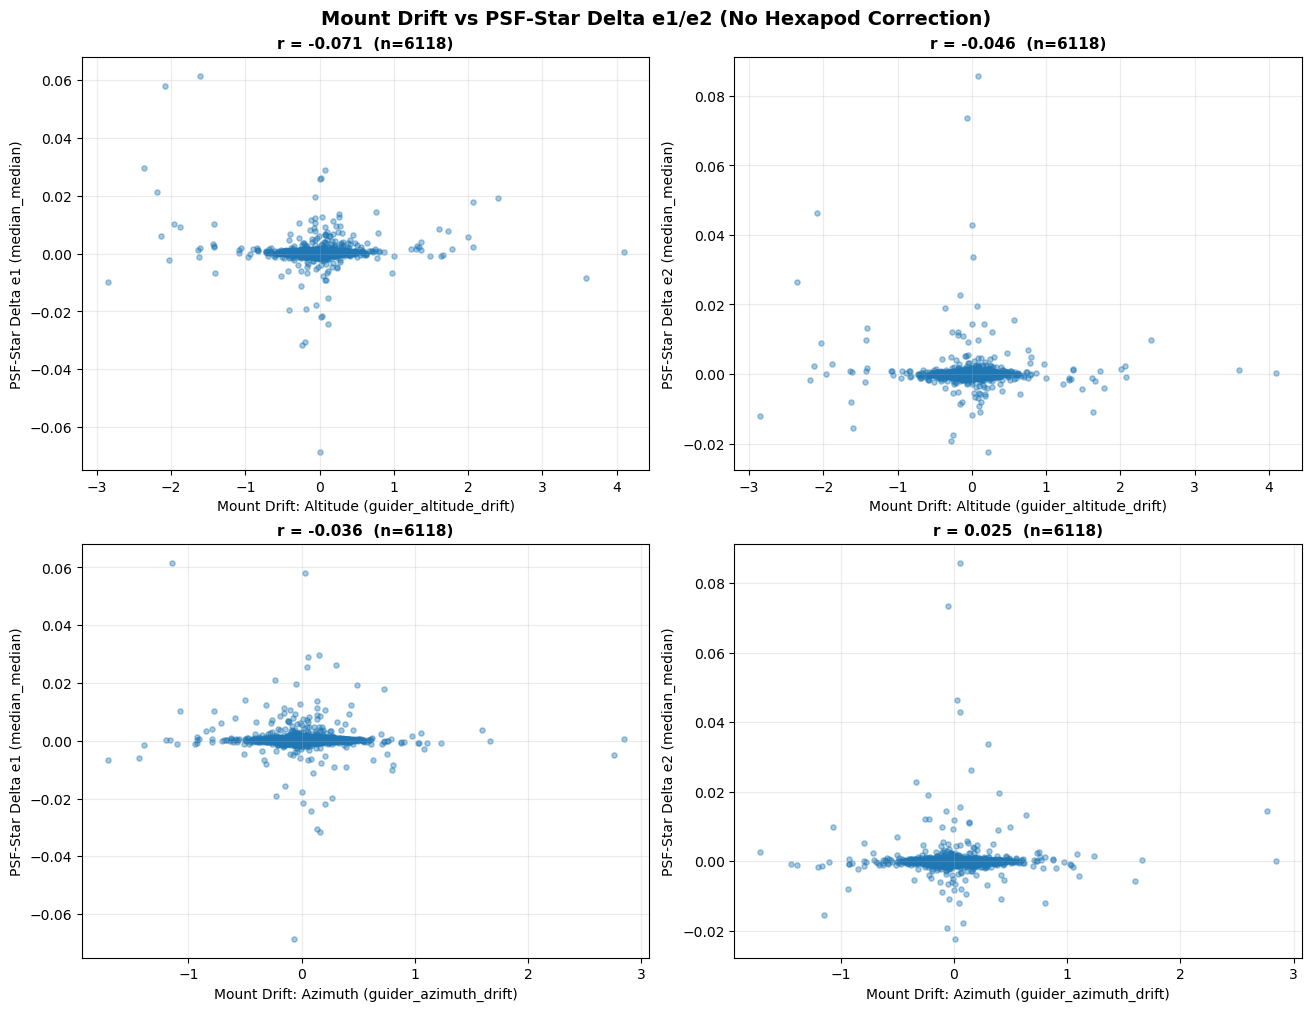


CORRELATION SUMMARY: MOUNT DRIFT vs PSF-STAR DELTA E1/E2 (NO HEXAPOD)

Mount Drift: Altitude (guider_altitude_drift):
  vs psf_star_delta_e1_median_median    : r = -0.0707  (n=6118)
  vs psf_star_delta_e2_median_median    : r = -0.0456  (n=6118)

Mount Drift: Azimuth (guider_azimuth_drift):
  vs psf_star_delta_e1_median_median    : r = -0.0355  (n=6118)
  vs psf_star_delta_e2_median_median    : r =  0.0250  (n=6118)


In [ ]:
# Scatter plots: mount drift vs PSF moment-derived e1/e2 (no hexapod correction)
# e1 = (Ixx - Iyy) / (Ixx + Iyy),  e2 = 2*Ixy / (Ixx + Iyy)
# Re-uses df_moments computed in cell 76 (must be run first).
from sqlalchemy import text

if 'df_motion' not in globals() or df_motion is None or len(df_motion) == 0:
    print('df_motion not available. Run the motion scoring cells first.')
else:
    required_cols = ['guider_altitude_drift', 'guider_azimuth_drift', 'mtaos_hexapod_correction']
    missing = [c for c in required_cols if c not in df_motion.columns]
    if missing:
        print(f'Missing required columns in df_motion: {missing}')
    else:
        # Fetch moments if not already in memory from cell 76
        if 'df_moments' not in globals():
            df_moments = pd.read_sql(text(f"""
                SELECT
                    e.exposure_id,
                    q.psf_ixx_median,
                    q.psf_iyy_median,
                    q.psf_ixy_median
                FROM {SCHEMA}.exposure e
                JOIN {SCHEMA}.visit1_quicklook q
                  ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
                WHERE e.img_type = 'science'
                  AND e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
                ORDER BY e.day_obs, e.seq_num
            """), engine.connect())
            for c in ['psf_ixx_median', 'psf_iyy_median', 'psf_ixy_median']:
                df_moments[c] = pd.to_numeric(df_moments[c], errors='coerce')
            denom = df_moments['psf_ixx_median'] + df_moments['psf_iyy_median']
            df_moments['e1_moments'] = (df_moments['psf_ixx_median'] - df_moments['psf_iyy_median']) / denom
            df_moments['e2_moments'] = 2 * df_moments['psf_ixy_median'] / denom

        df_plot = df_motion.merge(df_moments[['exposure_id', 'e1_moments', 'e2_moments']],
                                  on='exposure_id', how='left')

        for c in ['guider_altitude_drift', 'guider_azimuth_drift', 'e1_moments', 'e2_moments']:
            df_plot[c] = pd.to_numeric(df_plot[c], errors='coerce')

        df_plot = df_plot[~df_plot['mtaos_hexapod_correction'].fillna(False).astype(bool)].copy()
        print(f'Rows after no-hexapod filter: {len(df_plot)}')

        x_cols = [
            ('guider_altitude_drift', 'Mount Drift: Altitude (arcsec)'),
            ('guider_azimuth_drift',  'Mount Drift: Azimuth (arcsec)'),
        ]
        y_cols = [
            ('e1_moments', 'e1  =  (Ixx − Iyy) / (Ixx + Iyy)'),
            ('e2_moments', 'e2  =  2 Ixy / (Ixx + Iyy)'),
        ]

        fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

        for r_i, (x_col, x_label) in enumerate(x_cols):
            for c_i, (y_col, y_label) in enumerate(y_cols):
                ax = axes[r_i, c_i]
                valid = df_plot[df_plot[x_col].notna() & df_plot[y_col].notna()].copy()
                if len(valid) > 0:
                    ax.scatter(valid[x_col], valid[y_col], s=12, alpha=0.35, color='tab:blue')
                    corr = valid[x_col].corr(valid[y_col])
                    ax.set_title(f'r = {corr:.3f}  (n={len(valid)})', fontsize=11, fontweight='bold')
                else:
                    ax.set_title('No valid data', fontsize=11)
                ax.set_xlabel(x_label)
                ax.set_ylabel(y_label)
                ax.grid(alpha=0.25)

        fig.suptitle('Mount Drift vs PSF Moment Ellipticity (No Hexapod Correction)',
                     fontsize=14, fontweight='bold')
        plt.show()

        print('\n' + '=' * 80)
        print('CORRELATION SUMMARY: MOUNT DRIFT vs PSF MOMENT E1/E2 (NO HEXAPOD)')
        print('=' * 80)
        for x_col, x_label in x_cols:
            print(f'\n{x_label}:')
            for y_col, y_label in y_cols:
                valid = df_plot[df_plot[x_col].notna() & df_plot[y_col].notna()]
                if len(valid) > 0:
                    corr = valid[x_col].corr(valid[y_col])
                    print(f'  vs {y_col:15s}: r = {corr:7.4f}  (n={len(valid)})')


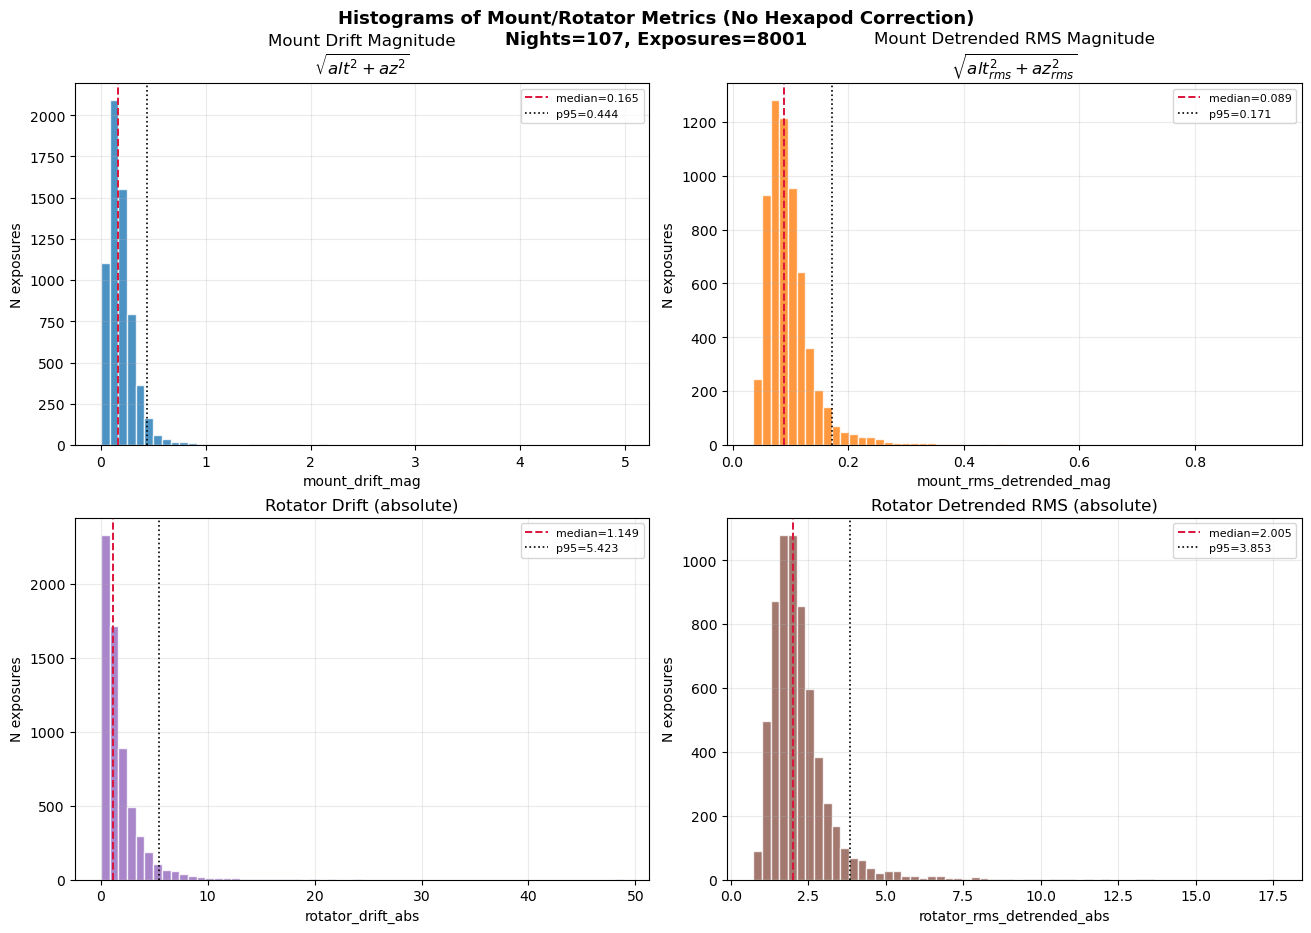

HISTOGRAM SUMMARY (NO HEXAPOD CORRECTION)
Nights represented: 107
Exposures after no-hexapod filter: 8001

Mount Drift Magnitude
$\sqrt{alt^2 + az^2}$:
  n=6287  median=0.1654  p95=0.4440  max=4.9818

Mount Detrended RMS Magnitude
$\sqrt{alt_{rms}^2 + az_{rms}^2}$:
  n=6287  median=0.0893  p95=0.1711  max=0.9392

Rotator Drift (absolute):
  n=6287  median=1.1494  p95=5.4231  max=48.8608

Rotator Detrended RMS (absolute):
  n=6287  median=2.0046  p95=3.8533  max=17.5792


In [36]:
# Histograms: mount/rotator motion metrics (no hexapod correction only)
if 'df_motion' not in globals() or df_motion is None or len(df_motion) == 0:
    print('df_motion not available. Run the motion scoring cells first.')
else:
    required = [
        'day_obs',
        'mtaos_hexapod_correction',
        'guider_altitude_drift',
        'guider_azimuth_drift',
        'guider_altitude_rms_detrended',
        'guider_azimuth_rms_detrended',
        'guider_focalplane_theta_drift',
        'guider_focalplane_theta_rms_detrended',
    ]
    missing = [c for c in required if c not in df_motion.columns]
    if missing:
        print(f'Missing required columns in df_motion: {missing}')
    else:
        df_hist = df_motion.copy()

        # Guard: keep only exposures with no hexapod correction.
        df_hist = df_hist[~df_hist['mtaos_hexapod_correction'].fillna(False).astype(bool)].copy()

        # Convert to numeric for robust histogramming.
        numeric_cols = [
            'guider_altitude_drift',
            'guider_azimuth_drift',
            'guider_altitude_rms_detrended',
            'guider_azimuth_rms_detrended',
            'guider_focalplane_theta_drift',
            'guider_focalplane_theta_rms_detrended',
        ]
        for c in numeric_cols:
            df_hist[c] = pd.to_numeric(df_hist[c], errors='coerce')

        # Aggregate mount metrics from altitude+azimuth components.
        df_hist['mount_drift_mag'] = np.sqrt(
            df_hist['guider_altitude_drift']**2 + df_hist['guider_azimuth_drift']**2
        )
        df_hist['mount_rms_detrended_mag'] = np.sqrt(
            df_hist['guider_altitude_rms_detrended']**2 + df_hist['guider_azimuth_rms_detrended']**2
        )

        # Rotator metrics: use absolute drift and absolute detrended RMS for positive-valued histograms.
        df_hist['rotator_drift_abs'] = df_hist['guider_focalplane_theta_drift'].abs()
        df_hist['rotator_rms_detrended_abs'] = df_hist['guider_focalplane_theta_rms_detrended'].abs()

        metric_specs = [
            ('mount_drift_mag', 'Mount Drift Magnitude\n$\\sqrt{alt^2 + az^2}$'),
            ('mount_rms_detrended_mag', 'Mount Detrended RMS Magnitude\n$\\sqrt{alt_{rms}^2 + az_{rms}^2}$'),
            ('rotator_drift_abs', 'Rotator Drift (absolute)'),
            ('rotator_rms_detrended_abs', 'Rotator Detrended RMS (absolute)'),
        ]

        n_nights = int(df_hist['day_obs'].nunique())
        n_rows = len(df_hist)

        fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
        colors = ['tab:blue', 'tab:orange', 'tab:purple', 'tab:brown']

        for ax, (col, title), color in zip(axes.flat, metric_specs, colors):
            vals = df_hist[col].dropna()
            if len(vals) == 0:
                ax.set_title(f'{title}\n(no valid data)')
                ax.grid(alpha=0.25)
                continue

            ax.hist(vals, bins=60, color=color, alpha=0.8, edgecolor='white')
            med = vals.median()
            p95 = vals.quantile(0.95)
            ax.axvline(med, color='crimson', linestyle='--', linewidth=1.4, label=f'median={med:.3f}')
            ax.axvline(p95, color='black', linestyle=':', linewidth=1.2, label=f'p95={p95:.3f}')
            ax.set_title(title)
            ax.set_xlabel(col)
            ax.set_ylabel('N exposures')
            ax.grid(alpha=0.25)
            ax.legend(fontsize=8)

        fig.suptitle(
            f'Histograms of Mount/Rotator Metrics (No Hexapod Correction)\nNights={n_nights}, Exposures={n_rows}',
            fontsize=13,
            fontweight='bold',
            y=1.02,
        )
        plt.show()

        print('=' * 90)
        print('HISTOGRAM SUMMARY (NO HEXAPOD CORRECTION)')
        print('=' * 90)
        print(f'Nights represented: {n_nights}')
        print(f'Exposures after no-hexapod filter: {n_rows}')

        for col, title in metric_specs:
            vals = df_hist[col].dropna()
            if len(vals) == 0:
                print(f'\n{title}: no valid data')
                continue
            print(f'\n{title}:')
            print(f'  n={len(vals)}  median={vals.median():.4f}  p95={vals.quantile(0.95):.4f}  max={vals.max():.4f}')


In [12]:

# Check null coverage for all psf ixx/iyy/ixy variants for our actual dataset
# (img_type = 'science', matching the df_guider/df_motion query filter)
from sqlalchemy import text

query_nullcheck = text(f"""
SELECT
    COUNT(*) AS total_rows,
    COUNT(q.psf_ixx_median) AS ixx_median_nn,
    COUNT(q.psf_ixx_min)    AS ixx_min_nn,
    COUNT(q.psf_ixx_max)    AS ixx_max_nn,
    COUNT(q.psf_iyy_median) AS iyy_median_nn,
    COUNT(q.psf_iyy_min)    AS iyy_min_nn,
    COUNT(q.psf_iyy_max)    AS iyy_max_nn,
    COUNT(q.psf_ixy_median) AS ixy_median_nn,
    COUNT(q.psf_ixy_min)    AS ixy_min_nn,
    COUNT(q.psf_ixy_max)    AS ixy_max_nn
FROM {SCHEMA}.exposure e
JOIN {SCHEMA}.visit1_quicklook q
    ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
WHERE e.img_type = 'science'
  AND e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
""")

with engine.connect() as conn:
    df_check = pd.read_sql(query_nullcheck, conn)

print("PSF second moment null coverage for img_type='science' in our date range:")
print(df_check.T.to_string(header=False))


PSF second moment null coverage for img_type='science' in our date range:
total_rows     35720
ixx_median_nn  35440
ixx_min_nn     35440
ixx_max_nn     35440
iyy_median_nn  35440
iyy_min_nn     35440
iyy_max_nn     35440
ixy_median_nn  35440
ixy_min_nn     35440
ixy_max_nn     35440
